##  <span style="color: #A7001E; font-weight: bold;">Part 1: Business Understanding</span>

**Customer churn, or customer attrition**, refers to the phenomenon where customers discontinue
using a company's products or services over time.

**The causes of customer churn in telecommunications are varied :**


- pricing
-Dissatisfaction with service quality
-Poor Customer Experience
-Better Competitor Offerings


**The primary stakeholders for this project include:**
*  Marketing Manager
*  General Management
*   Product Manager







**A deeper understanding of churn can help stakeholders in several ways:**

Identifies and addresses features that fall short of
customer expectations.

Ensures proactive measures are taken to prevent dissatisfaction from spreading to other customers.



**BO1**: Estimate customers likely to churn.

**DSO 1:** Customer churn prediction in the telecom sector using machine learning techniques.

**BO2:**Enhance customer retention through the integration of machine learning insights.

**DSO2:** Implementing Machine Learning Techniques for Customer Retention and Churn Prediction in Telecommunications

**BO3:**Provide clear insights into churn predictions by detailing the factors influencing customer decisions.

**DSO3:** Explaining Customer Churn Prediction in Telecom Industry Using Tabular Machine Learning Models

**Part 2 : Data Understanding**

## <span style="color:green;">  Dataset Overview: </span>
- **Name:** Telco-Customer-Churn Dataset (IBM Watson, 2015)
- **Source:** Kaggle
- **Total Records:** 3333 customers
- **Features:**
  - 🔢 Numerical Columns: 16
  - 🔡 Categorical Columns: 4
  
  # 📖 Detailed Explanation of Each Column

| <span style="color:green;"> **Column Name** </span>         | <span style="color:green;"> **Description** </span>                                                                                  |
|----------------------------|---------------------------------------------------------------------------------------------------|
| **State**                 | The U.S. state where the customer resides.                                                       |
| **Account length**        | The number of days or months the customer has been using the company's services.                 |
| **Area code**             | The telephone area code of the customer.                                                        |
| **International plan**    | Indicates if the customer is subscribed to an international calling plan.                        |
| **Voice mail plan**       | Shows whether the customer has subscribed to a voicemail service.                                |
| **Number vmail messages** | Total number of voicemail messages a customer has received.                                      |
| **Total day minutes**     | Total minutes the customer spent on calls during the day.                                        |
| **Total day calls**       | Total number of calls made during the day.                                                       |
| **Total day charge**      | Total cost for calls made during the day, typically based on minutes.                            |
| **Total eve minutes**     | Total minutes spent on calls during the evening.                                                |
| **Total eve calls**       | Total number of calls made during the evening.                                                  |
| **Total eve charge**      | Total charges for evening calls.                                                                |
| **Total night minutes**   | Total minutes spent on calls at night.                                                          |
| **Total night calls**     | Total number of calls made at night.                                                            |
| **Total night charge**    | Charges for calls made at night.                                                                |
| **Total intl minutes**    | Total minutes spent on international calls.                                                     |
| **Total intl calls**      | Number of international calls made by the customer.                                             |
| **Total intl charge**     | Total charges incurred for international calls.                                                 |
| **Customer service calls**| Number of calls made to customer service.                                                       |
| **Churn**                 | A binary value indicating whether the customer has left the service (churned).                  |


---


## <span style="color:green;"> Target Variable: 🎯 </span>
### "Churn": Binary classification of customer churn
- **"T" (True) - Churning Customers:**
  - Count: 483 customers
  - Percentage: 14.49%
- **"F" (False) - Non-Churning Customers:**
  - Count: 2850 customers
  - Percentage: 85.51%

## <span style="color:green;"> Data Quality: ⚠️ </span>
- **Missing Values:**
  - 0 missing entries

## <span style="color:green;">Purpose: 🌟</span>
- Predict customer churn to help improve retention strategies.
- Apply feature selection techniques to identify effective predictors.
- Use machine learning for behavior analysis and targeted strategies.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\21624\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
df = pd.read_csv('churn-bigml-20.csv')
df1 = pd.read_csv('churn-bigml-80.csv')

In [3]:
df_combined = pd.concat([df, df1], ignore_index=True)

In [4]:
print(df_combined.head())

  State  Account length  Area code International plan Voice mail plan  \
0    LA             117        408                 No              No   
1    IN              65        415                 No              No   
2    NY             161        415                 No              No   
3    SC             111        415                 No              No   
4    HI              49        510                 No              No   

   Number vmail messages  Total day minutes  Total day calls  \
0                      0              184.5               97   
1                      0              129.1              137   
2                      0              332.9               67   
3                      0              110.4              103   
4                      0              119.3              117   

   Total day charge  Total eve minutes  Total eve calls  Total eve charge  \
0             31.37              351.6               80             29.89   
1             21.95   

In [5]:
df_combined [:5]
df_combined.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,LA,117,408,No,No,0,184.5,97,31.37,351.6,80,29.89,215.8,90,9.71,8.7,4,2.35,1,False
1,IN,65,415,No,No,0,129.1,137,21.95,228.5,83,19.42,208.8,111,9.40,12.7,6,3.43,4,True
2,NY,161,415,No,No,0,332.9,67,56.59,317.8,97,27.01,160.6,128,7.23,5.4,9,1.46,4,True
3,SC,111,415,No,No,0,110.4,103,18.77,137.3,102,11.67,189.6,105,8.53,7.7,6,2.08,2,False
4,HI,49,510,No,No,0,119.3,117,20.28,215.1,109,18.28,178.7,90,8.04,11.1,1,3.00,1,False


In [6]:
df_combined.sample(10)

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
1768,TX,98,408,No,Yes,19,110.5,87,18.79,227.8,97,19.36,243.6,84,10.96,11.0,4,2.97,1,False
1530,SD,148,408,No,No,0,185.2,87,31.48,170.4,96,14.48,165.1,104,7.43,9.5,13,2.57,1,False
2302,NH,90,408,No,No,0,140.2,97,23.83,213.9,102,18.18,120.0,126,5.40,7.1,2,1.92,1,False
3196,SC,41,510,No,No,0,207.2,138,35.22,214.1,83,18.20,193.0,105,8.69,11.9,4,3.21,1,False
956,ME,31,415,No,No,0,166.1,105,28.24,79.3,93,6.74,213.7,98,9.62,12.7,2,3.43,1,False
3049,CT,160,415,No,No,0,234.9,136,39.93,270.8,134,23.02,219.3,101,9.87,13.9,2,3.75,1,True
357,HI,104,408,No,No,0,170.6,97,29.00,162.1,111,13.78,210.7,131,9.48,6.1,1,1.65,1,False
2358,CA,138,510,Yes,No,0,196.2,129,33.35,176.5,86,15.00,232.4,108,10.46,15.2,1,4.10,0,True
249,IN,108,415,No,No,0,199.3,104,33.88,224.2,92,19.06,140.1,57,6.30,15.2,2,4.10,0,False
223,NY,44,510,No,No,0,143.2,77,24.34,169.8,114,14.43,215.8,77,9.71,7.6,4,2.05,1,False


In [7]:
df_combined.shape

(3333, 20)

In [8]:
df_combined.columns

Index(['State', 'Account length', 'Area code', 'International plan',
       'Voice mail plan', 'Number vmail messages', 'Total day minutes',
       'Total day calls', 'Total day charge', 'Total eve minutes',
       'Total eve calls', 'Total eve charge', 'Total night minutes',
       'Total night calls', 'Total night charge', 'Total intl minutes',
       'Total intl calls', 'Total intl charge', 'Customer service calls',
       'Churn'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 667 entries, 0 to 666
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   667 non-null    object 
 1   Account length          667 non-null    int64  
 2   Area code               667 non-null    int64  
 3   International plan      667 non-null    object 
 4   Voice mail plan         667 non-null    object 
 5   Number vmail messages   667 non-null    int64  
 6   Total day minutes       667 non-null    float64
 7   Total day calls         667 non-null    int64  
 8   Total day charge        667 non-null    float64
 9   Total eve minutes       667 non-null    float64
 10  Total eve calls         667 non-null    int64  
 11  Total eve charge        667 non-null    float64
 12  Total night minutes     667 non-null    float64
 13  Total night calls       667 non-null    int64  
 14  Total night charge      667 non-null    fl

In [10]:
df_combined.dtypes

State                      object
Account length              int64
Area code                   int64
International plan         object
Voice mail plan            object
Number vmail messages       int64
Total day minutes         float64
Total day calls             int64
Total day charge          float64
Total eve minutes         float64
Total eve calls             int64
Total eve charge          float64
Total night minutes       float64
Total night calls           int64
Total night charge        float64
Total intl minutes        float64
Total intl calls            int64
Total intl charge         float64
Customer service calls      int64
Churn                        bool
dtype: object

In [11]:
df_combined.describe()

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,101.064806,437.182418,8.099010,179.775098,100.435644,30.562307,200.980348,100.114311,17.083540,200.872037,100.107711,9.039325,10.237294,4.479448,2.764581,1.562856
std,39.822106,42.371290,13.688365,54.467389,20.069084,9.259435,50.713844,19.922625,4.310668,50.573847,19.568609,2.275873,2.791840,2.461214,0.753773,1.315491
min,1.000000,408.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.200000,33.000000,1.040000,0.000000,0.000000,0.000000,0.000000
25%,74.000000,408.000000,0.000000,143.700000,87.000000,24.430000,166.600000,87.000000,14.160000,167.000000,87.000000,7.520000,8.500000,3.000000,2.300000,1.000000
50%,101.000000,415.000000,0.000000,179.400000,101.000000,30.500000,201.400000,100.000000,17.120000,201.200000,100.000000,9.050000,10.300000,4.000000,2.780000,1.000000
75%,127.000000,510.000000,20.000000,216.400000,114.000000,36.790000,235.300000,114.000000,20.000000,235.300000,113.000000,10.590000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,51.000000,350.800000,165.000000,59.640000,363.700000,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000


In [12]:
missing_values = df_combined.isnull().sum()
print(missing_values)

State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64


In [13]:
nan_counts = df_combined.isna().sum()
threshold = 1000
# Get columns with NaN counts above the threshold
columns_with_nan = nan_counts[nan_counts > threshold]
print(columns_with_nan)

Series([], dtype: int64)


In [14]:
duplicates = df_combined.duplicated()

# Display duplicate rows
duplicate_rows = df_combined[duplicates]

print("\nDuplicate Rows:")
print(duplicate_rows)

# Count the number of duplicate rows
num_duplicates = duplicates.sum()
print(f"\nNumber of Duplicate Rows: {num_duplicates}")

#===> the result there is no duplicated rowsss


Duplicate Rows:
Empty DataFrame
Columns: [State, Account length, Area code, International plan, Voice mail plan, Number vmail messages, Total day minutes, Total day calls, Total day charge, Total eve minutes, Total eve calls, Total eve charge, Total night minutes, Total night calls, Total night charge, Total intl minutes, Total intl calls, Total intl charge, Customer service calls, Churn]
Index: []

Number of Duplicate Rows: 0


In [15]:
df_combined.isnull().sum()

State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64

In [16]:
df_combined['State'].unique()       # Exemple pour la colonne "State"


array(['LA', 'IN', 'NY', 'SC', 'HI', 'AK', 'MI', 'ID', 'VA', 'WI', 'MN',
       'VT', 'MT', 'MA', 'KY', 'CO', 'AZ', 'CA', 'WA', 'NE', 'OH', 'MO',
       'AL', 'NH', 'NM', 'OR', 'TX', 'MS', 'WY', 'FL', 'KS', 'NC', 'SD',
       'OK', 'CT', 'RI', 'DE', 'UT', 'NV', 'DC', 'ME', 'IL', 'NJ', 'MD',
       'WV', 'PA', 'ND', 'AR', 'TN', 'IA', 'GA'], dtype=object)

In [17]:
df_combined['Churn'].value_counts() # Exemple pour voir la distribution de la cible "Churn"

Churn
False    2850
True      483
Name: count, dtype: int64

In [18]:
df_combined.select_dtypes(include='object').columns

Index(['State', 'International plan', 'Voice mail plan'], dtype='object')

In [19]:
df_combined.describe(include=['object'])

,State,International plan,Voice mail plan
count,3333,3333,3333
unique,51,2,2
top,WV,No,No
freq,106,3010,2411


count : Nombre d'éléments non nuls dans chaque colonne.

State : 3333 valeurs non nulles (aucune donnée manquante).
International plan : 3333 valeurs non nulles.
Voice mail plan : 3333 valeurs non nulles.
unique : Le nombre de valeurs uniques dans chaque colonne.

State : 51 valeurs uniques, ce qui signifie qu'il y a 51 états différents (par exemple, chaque état américain ou une autre division géographique).
International plan : 2 valeurs uniques (Yes et No).
Voice mail plan : 2 valeurs uniques (Yes et No).
top : La valeur la plus fréquente (modale) dans chaque colonne.

State : La valeur la plus fréquente est WV (West Virginia).
International plan : La valeur la plus fréquente est No, ce qui signifie que la plupart des clients n'ont pas de plan international.
Voice mail plan : La valeur la plus fréquente est également No, indiquant que la majorité des clients n'ont pas de plan de messagerie vocale.
freq : La fréquence de la valeur la plus fréquente (le nombre de fois qu'elle apparaît).

State : WV apparaît 106 fois.
International plan : No apparaît 3010 fois.
Voice mail plan : No apparaît 2411 fois.

In [20]:
df_combined['International plan'].value_counts()  # Nombre de clients avec et sans plan international


International plan
No     3010
Yes     323
Name: count, dtype: int64

In [21]:
df_combined.select_dtypes(include=['float64', 'int64']).corr()


,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
Account length,1.000000,-0.012463,-0.004628,0.006216,0.038470,0.006214,-0.006757,0.019260,-0.006745,-0.008955,-0.013176,-0.008960,0.009514,0.020661,0.009546,-0.003796
Area code,-0.012463,1.000000,-0.001994,-0.008264,-0.009646,-0.008264,0.003580,-0.011886,0.003607,-0.005825,0.016522,-0.005845,-0.018288,-0.024179,-0.018395,0.027572
Number vmail messages,-0.004628,-0.001994,1.000000,0.000778,-0.009548,0.000776,0.017562,-0.005864,0.017578,0.007681,0.007123,0.007663,0.002856,0.013957,0.002884,-0.013263
Total day minutes,0.006216,-0.008264,0.000778,1.000000,0.006750,1.000000,0.007043,0.015769,0.007029,0.004323,0.022972,0.004300,-0.010155,0.008033,-0.010092,-0.013423
Total day calls,0.038470,-0.009646,-0.009548,0.006750,1.000000,0.006753,-0.021451,0.006462,-0.021449,0.022938,-0.019557,0.022927,0.021565,0.004574,0.021666,-0.018942
Total day charge,0.006214,-0.008264,0.000776,1.000000,0.006753,1.000000,0.007050,0.015769,0.007036,0.004324,0.022972,0.004301,-0.010157,0.008032,-0.010094,-0.013427
Total eve minutes,-0.006757,0.003580,0.017562,0.007043,-0.021451,0.007050,1.000000,-0.011430,1.000000,-0.012584,0.007586,-0.012593,-0.011035,0.002541,-0.011067,-0.012985
Total eve calls,0.019260,-0.011886,-0.005864,0.015769,0.006462,0.015769,-0.011430,1.000000,-0.011423,-0.002093,0.007710,-0.002056,0.008703,0.017434,0.008674,0.002423
Total eve charge,-0.006745,0.003607,0.017578,0.007029,-0.021449,0.007036,1.000000,-0.011423,1.000000,-0.012592,0.007596,-0.012601,-0.011043,0.002541,-0.011074,-0.012987
Total night minutes,-0.008955,-0.005825,0.007681,0.004323,0.022938,0.004324,-0.012584,-0.002093,-0.012592,1.000000,0.011204,0.999999,-0.015207,-0.012353,-0.015180,-0.009288


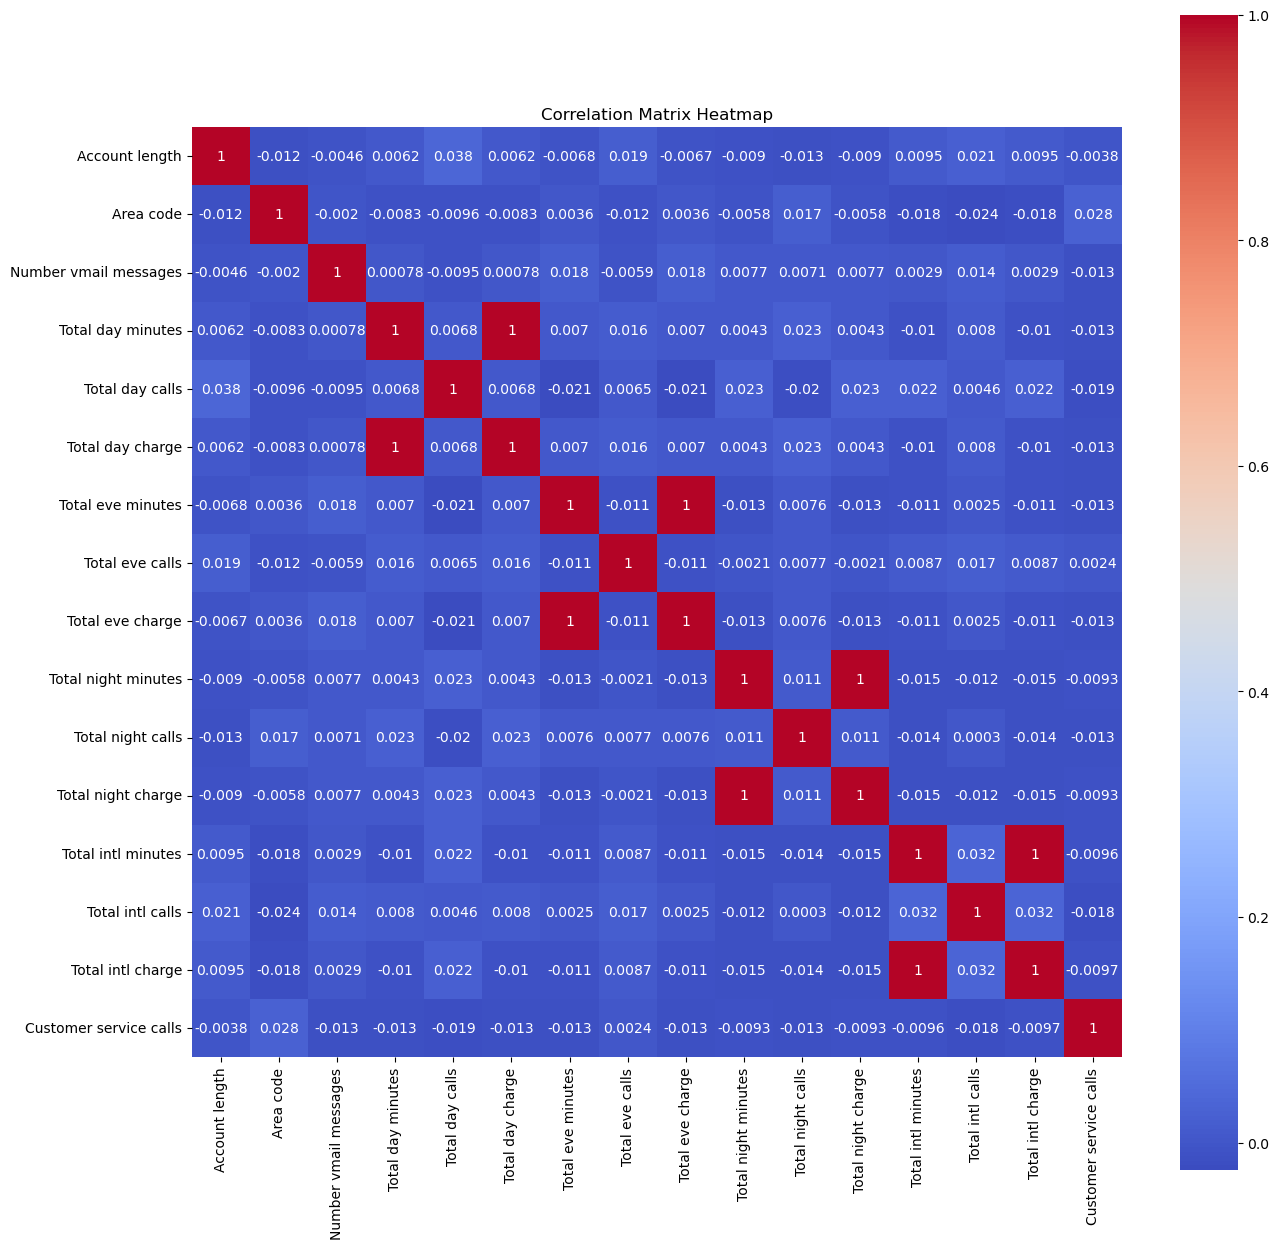

In [22]:
numeric_df = df_combined.select_dtypes(include=['float64', 'int64'])

# Calculer la matrice de corrélation
corr_matrix = numeric_df.corr()

# Tracer la heatmap de la matrice de corrélation
plt.figure(figsize=(15,15)) #(width,height)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', square=True)
plt.title('Correlation Matrix Heatmap')
plt.show()

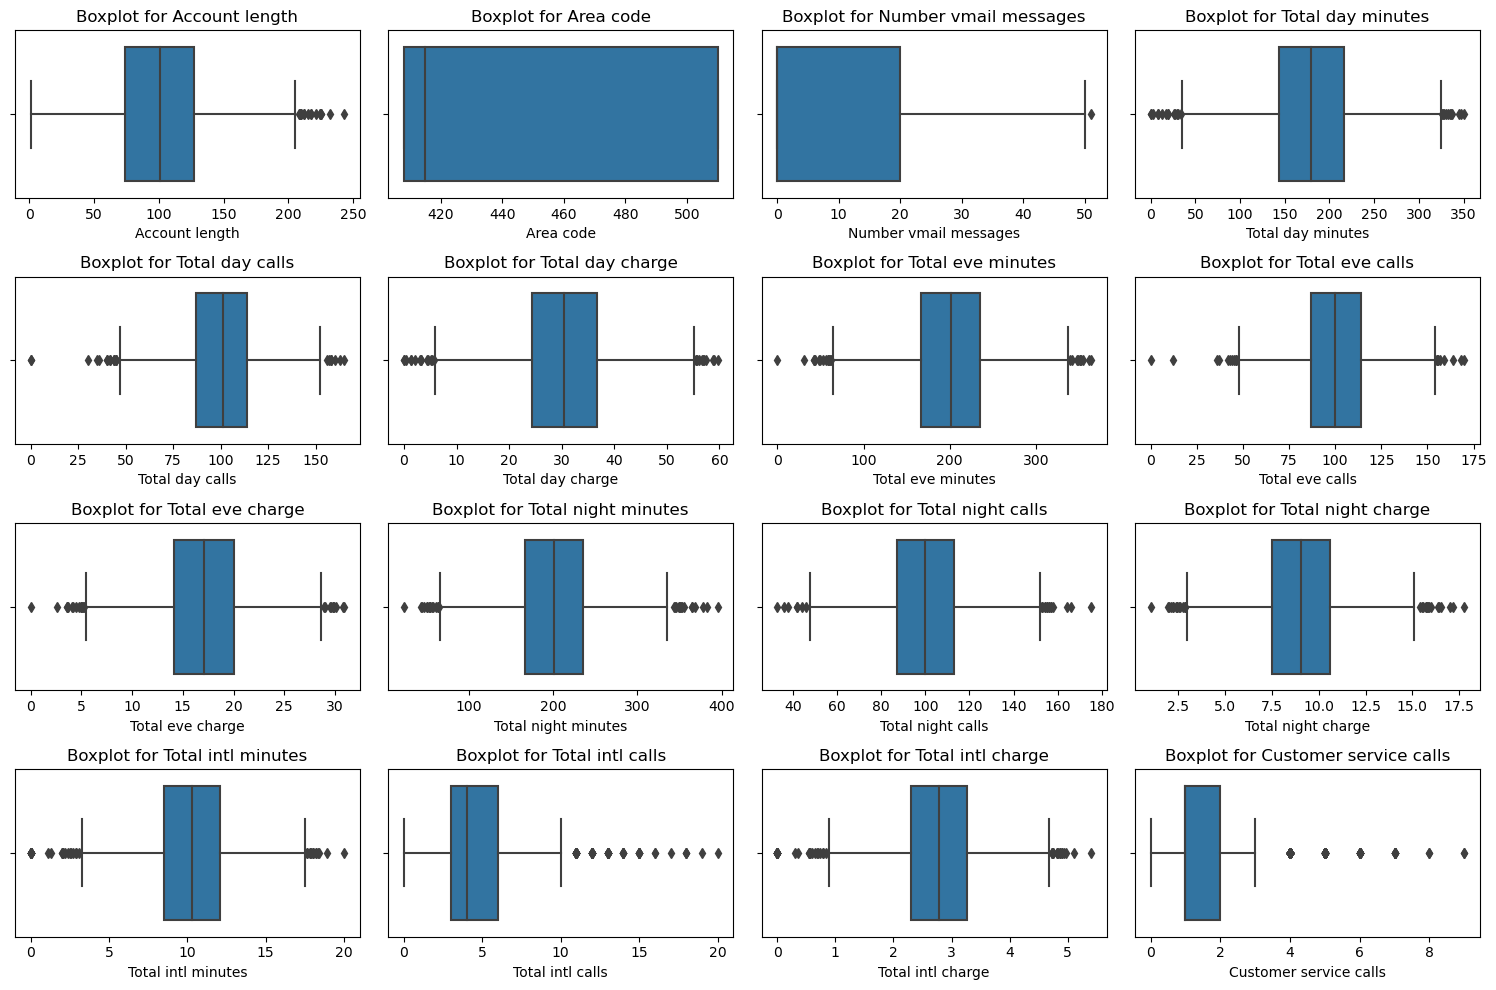

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sélectionner uniquement les variables numériques
numeric_df = df_combined.select_dtypes(include=['float64', 'int64'])

# Créer un boxplot pour chaque variable numérique
plt.figure(figsize=(15,10))
for i, column in enumerate(numeric_df.columns, 1):
    plt.subplot(4, 4, i)  # Organiser les boxplots en une grille (ici 4x4)
    sns.boxplot(x=numeric_df[column])
    plt.title(f'Boxplot for {column}')
plt.tight_layout()
plt.show()


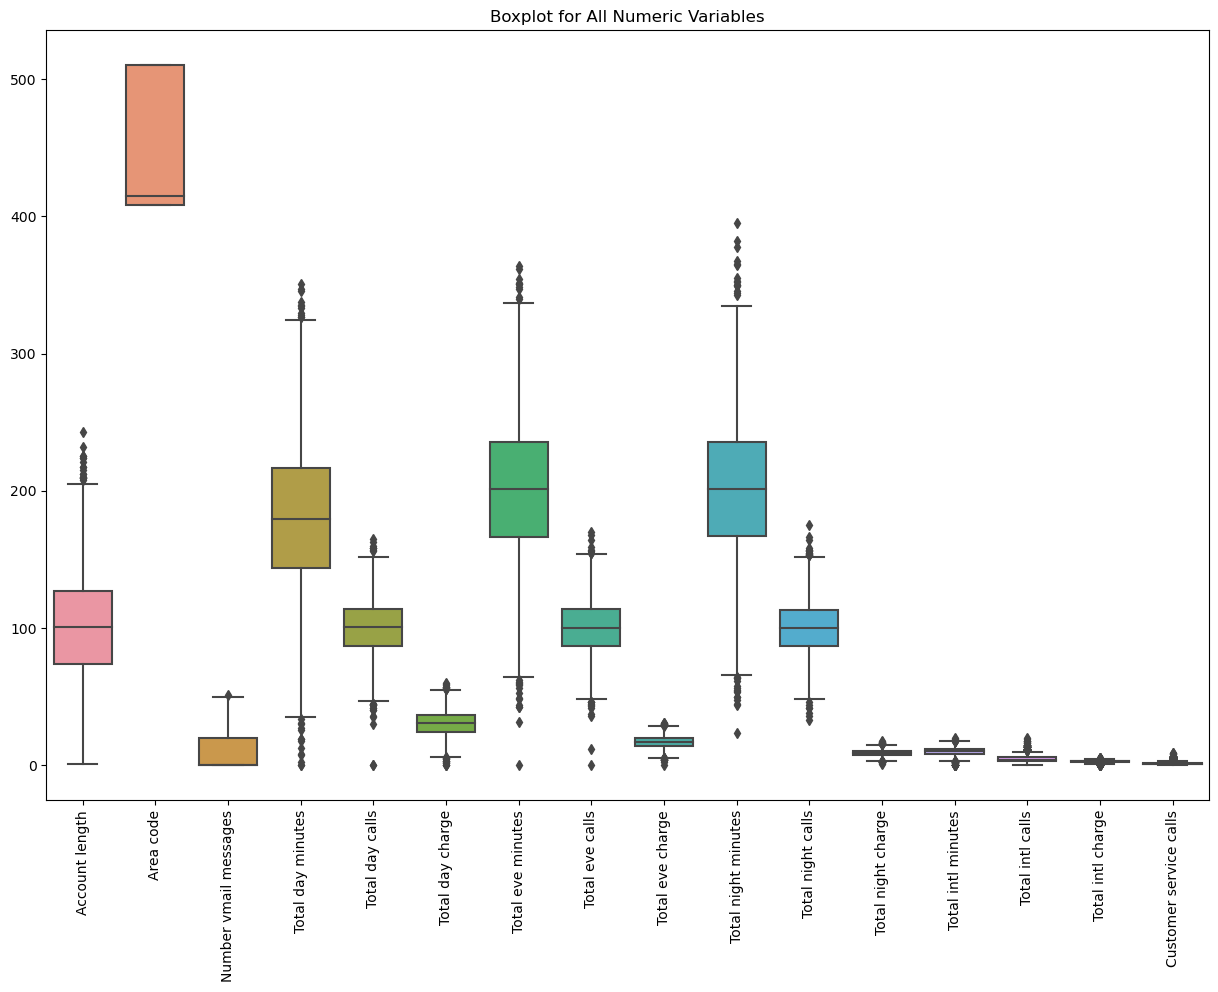

In [55]:
def count_outliers(df):
    total_outliers = 0
    for column in df.select_dtypes(include=['number']):  # seulement les colonnes numériques
        Q1 = df[column].quantile(0.25)  # Premier quartile
        Q3 = df[column].quantile(0.75)  # Troisième quartile
        IQR = Q3 - Q1  # Écart interquartile
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Comptage des outliers
        outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
        total_outliers += outliers.shape[0]
    return total_outliers

# Afficher le nombre total d'outliers
total_outliers = count_outliers(df_combined)
print(f"Nombre total d'outliers: {total_outliers}")

Nombre total d'outliers: 682


In [26]:
# Fonction pour calculer le nombre d'outliers par colonne
def count_outliers_by_column(df):
    outlier_counts = {}
    for column in df.select_dtypes(include=['number']):  # Appliquer uniquement aux colonnes numériques
        Q1 = df[column].quantile(0.25)  # Premier quartile
        Q3 = df[column].quantile(0.75)  # Troisième quartile
        IQR = Q3 - Q1  # Écart interquartile
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Filtrer les outliers
        outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
        outlier_counts[column] = outliers.shape[0]
    return outlier_counts

# Obtenir et afficher le nombre d'outliers par colonne
outliers_per_column = count_outliers_by_column(df_combined)
for column, count in outliers_per_column.items():
    print(f"Nombre d'outliers dans '{column}': {count}")

Nombre d'outliers dans 'Account length': 18
Nombre d'outliers dans 'Area code': 0
Nombre d'outliers dans 'Number vmail messages': 1
Nombre d'outliers dans 'Total day minutes': 25
Nombre d'outliers dans 'Total day calls': 23
Nombre d'outliers dans 'Total day charge': 25
Nombre d'outliers dans 'Total eve minutes': 24
Nombre d'outliers dans 'Total eve calls': 20
Nombre d'outliers dans 'Total eve charge': 24
Nombre d'outliers dans 'Total night minutes': 30
Nombre d'outliers dans 'Total night calls': 22
Nombre d'outliers dans 'Total night charge': 30
Nombre d'outliers dans 'Total intl minutes': 46
Nombre d'outliers dans 'Total intl calls': 78
Nombre d'outliers dans 'Total intl charge': 49
Nombre d'outliers dans 'Customer service calls': 267


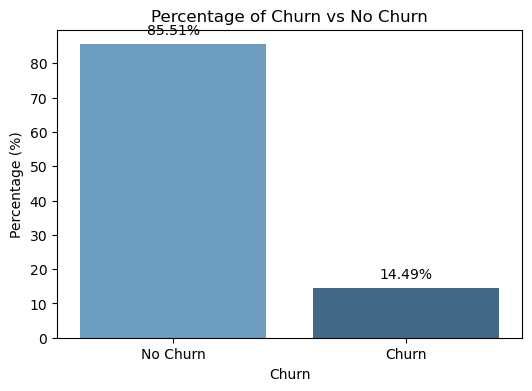

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compter le nombre de valeurs pour chaque catégorie (True/False) de la colonne 'Churn'
churn_counts = df_combined['Churn'].value_counts()

# Calculer les pourcentages
churn_percentage = churn_counts / churn_counts.sum() * 100

# Créer un graphique à barres pour visualiser les pourcentages
plt.figure(figsize=(6, 4))
sns.barplot(x=churn_percentage.index, y=churn_percentage.values, palette='Blues_d')

# Ajouter des labels et un titre
plt.title('Percentage of Churn vs No Churn')
plt.xlabel('Churn')
plt.ylabel('Percentage (%)')
plt.xticks([0, 1], ['No Churn', 'Churn'])  # Renommer les catégories 0 et 1

# Afficher les pourcentages sur les barres
for i, value in enumerate(churn_percentage.values):
    plt.text(i, value + 2, f'{value:.2f}%', ha='center', va='bottom')

plt.show()


C:\Users\21624\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


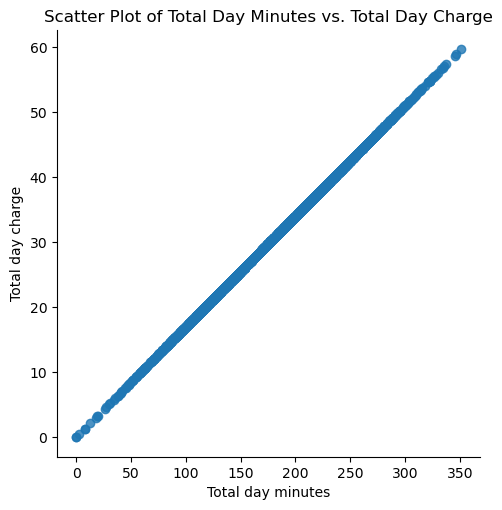

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# Créer un graphique de dispersion pour visualiser la relation entre deux variables numériques
sns.lmplot(data=df_combined, x='Total day minutes', y='Total day charge', fit_reg=False)

# Ajouter un titre
plt.title('Scatter Plot of Total Day Minutes vs. Total Day Charge')
plt.show()

C:\Users\21624\AppData\Local\Temp\ipykernel_22872\1647191846.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Tot = sns.kdeplot(df_combined['Total day charge'][df_combined['Churn'] == False],
C:\Users\21624\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\21624\AppData\Local\Temp\ipykernel_22872\1647191846.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Tot = sns.kdeplot(df_combined['Total day charge'][df_combined['Churn'] == True],
C:\Users\21624\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated an

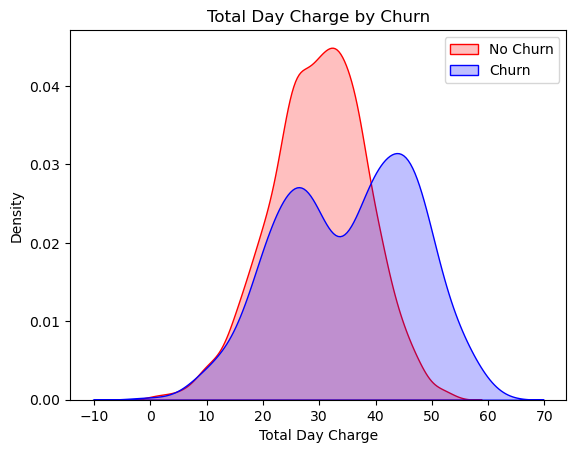

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# Créer les courbes de densité pour la variable 'Total day charge' en fonction de 'Churn'
Tot = sns.kdeplot(df_combined['Total day charge'][df_combined['Churn'] == False],
                  color="Red", shade=True)
Tot = sns.kdeplot(df_combined['Total day charge'][df_combined['Churn'] == True],
                  ax=Tot, color="Blue", shade=True)

# Ajouter la légende, les labels et le titre
Tot.legend(["No Churn", "Churn"], loc='upper right')
Tot.set_ylabel('Density')
Tot.set_xlabel('Total Day Charge')
Tot.set_title('Total Day Charge by Churn')

# Afficher le graphique
plt.show()

Index(['State', 'Account length', 'Area code', 'International plan',
       'Voice mail plan', 'Number vmail messages', 'Total day minutes',
       'Total day calls', 'Total day charge', 'Total eve minutes',
       'Total eve calls', 'Total eve charge', 'Total night minutes',
       'Total night calls', 'Total night charge', 'Total intl minutes',
       'Total intl calls', 'Total intl charge', 'Customer service calls',
       'Churn'],
      dtype='object')


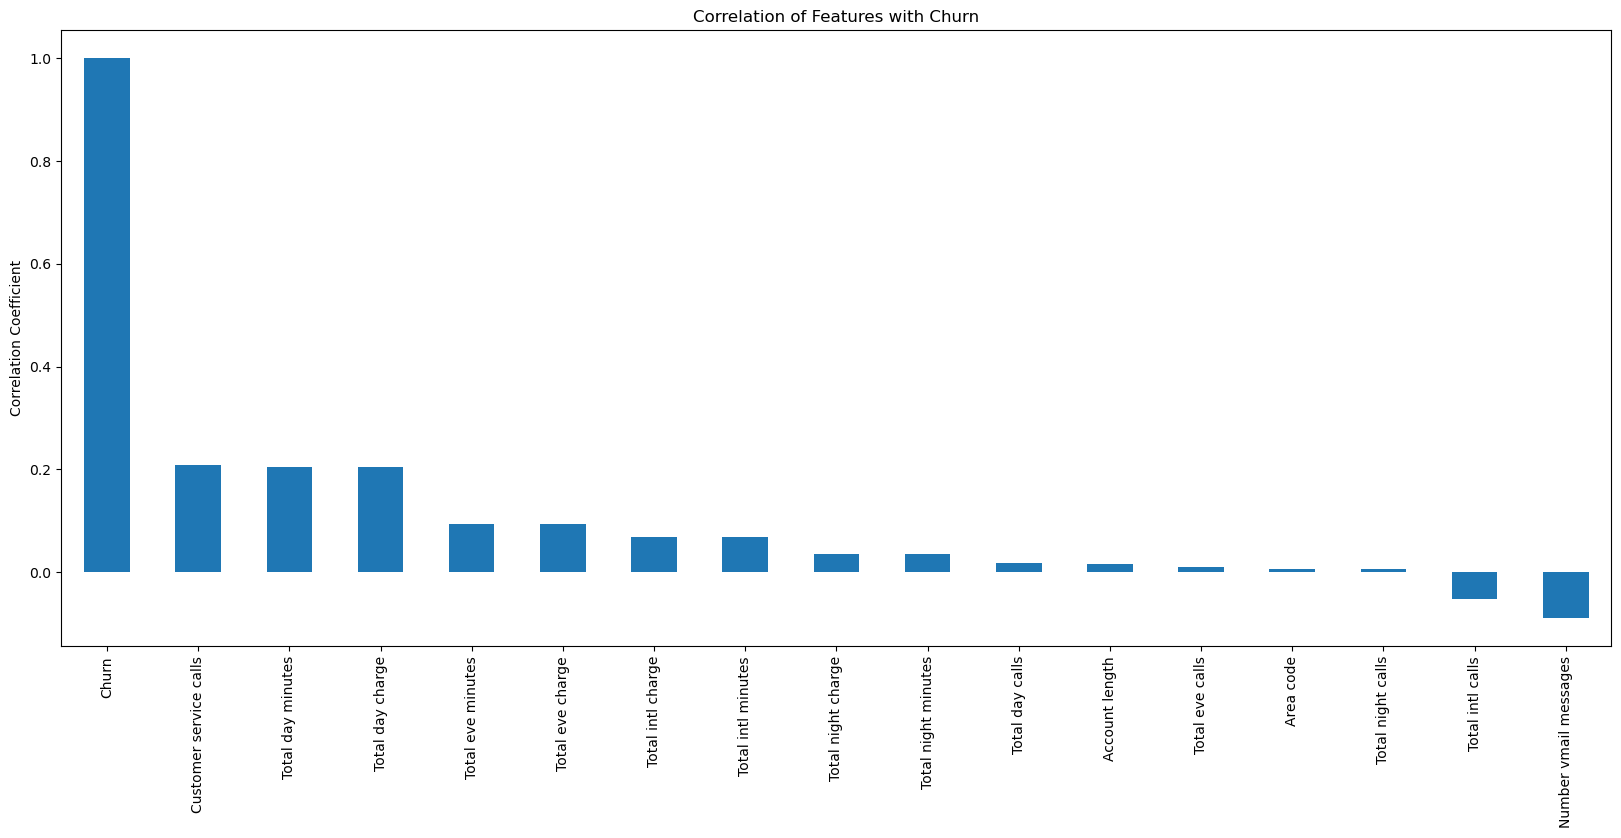

In [30]:
# Check the column names to ensure 'Churn' exists
print(df_combined.columns)

# If 'Churn' exists but is in boolean format (True/False), convert it to 1/0
if 'Churn' in df_combined.columns and df_combined['Churn'].dtype == 'bool':
    df_combined['Churn'] = df_combined['Churn'].astype(int)

# Filter only numeric columns for correlation
numeric_cols = df_combined.select_dtypes(include=['number']).columns

# Calculate the correlation matrix
corr_matrix = df_combined[numeric_cols].corr()

# Plot the correlation of 'Churn' with all other numeric variables
plt.figure(figsize=(20, 8))
corr_matrix['Churn'].sort_values(ascending=False).plot(kind='bar')
plt.title('Correlation of Features with Churn')
plt.ylabel('Correlation Coefficient')
plt.show()

C:\Users\21624\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\21624\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\21624\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\21624\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a len

C:\Users\21624\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\21624\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\21624\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\21624\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a len

C:\Users\21624\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\21624\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\21624\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\21624\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a len

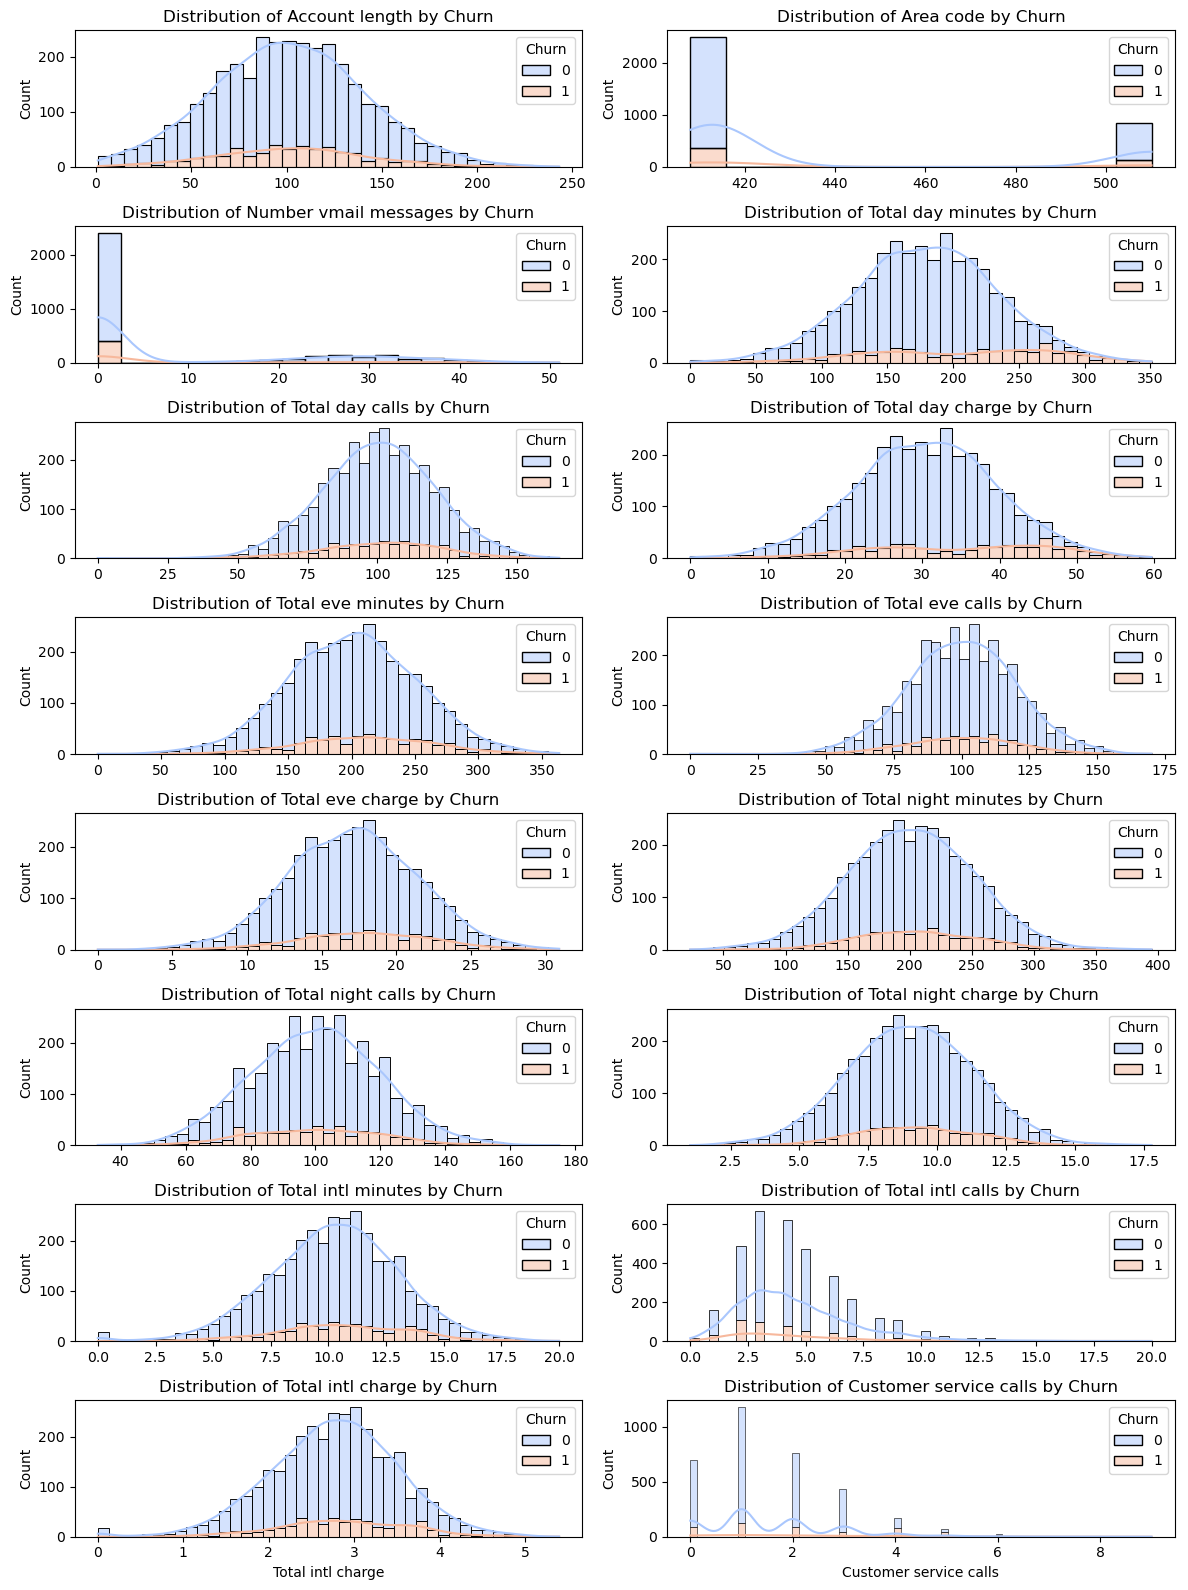

In [31]:
numerical_features = df_combined.select_dtypes(include=['int64', 'float64']).columns

import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you have numerical_features and data_copy defined elsewhere

num_cols = 2  # Number of features to display per row
num_rows = (len(numerical_features) // num_cols)   # Calculate the number of rows

fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, num_rows * 2))  # Adjust figsize as needed

# Iterate through features and create subplots
feature_index = 0
for row in range(num_rows):
    for col in range(num_cols):
        if feature_index >= len(numerical_features):
            break  # Handle cases where there are fewer features than subplots

        feature = numerical_features[feature_index]
        ax = axes[row, col]  # Access the subplot at the current row and column

        sns.histplot(data=df_combined, x=feature, kde=True, hue='Churn', multiple='stack', palette='coolwarm', ax=ax)
        ax.set_title(f'Distribution of {feature} by Churn')
        ax.set_xlabel(feature)
        ax.set_ylabel('Count')

        # Remove unnecessary x-axis labels for subplots except the bottom row
        if row < num_rows - 1:
            ax.set_xlabel('')

        feature_index += 1

# Adjust layout (optional)
plt.tight_layout()  # Adjust spacing between subplots

plt.show()


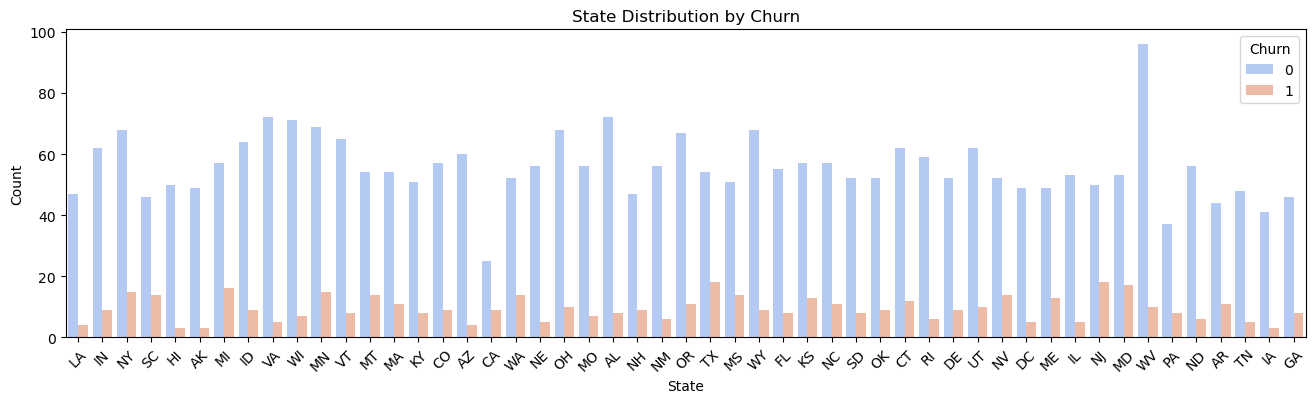

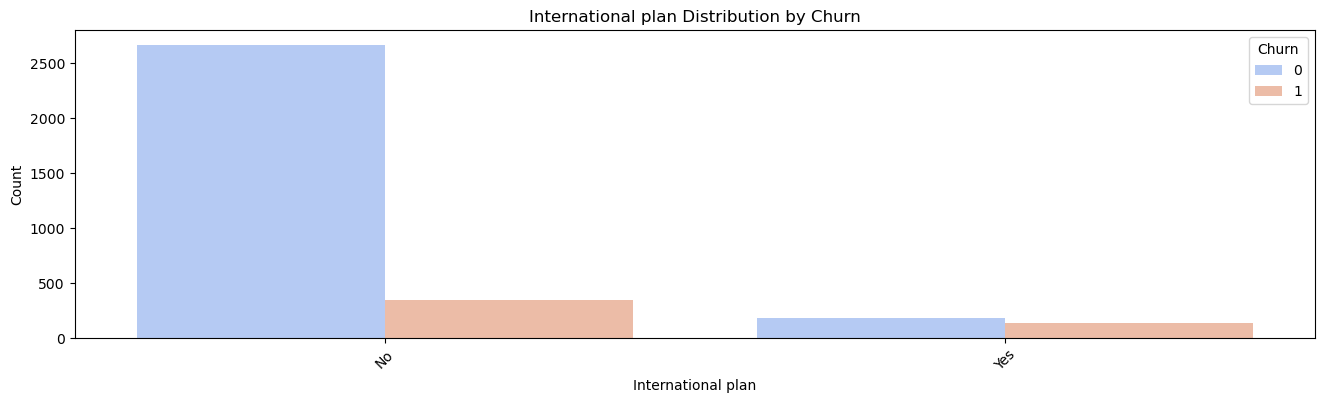

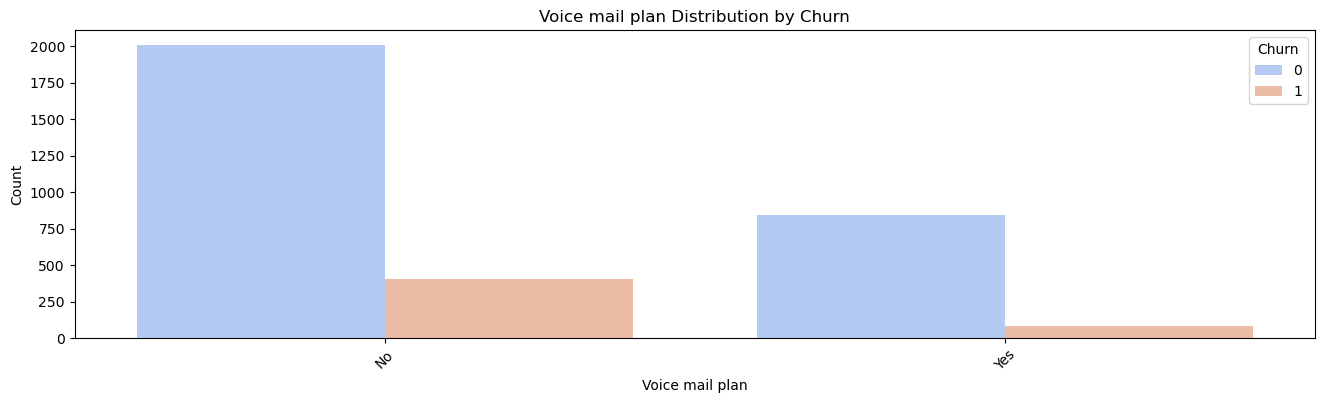

In [32]:
categorical_features = df_combined.select_dtypes(include=['object']).columns

for feature in categorical_features:
    plt.figure(figsize=(16, 4))
    sns.countplot(data=df_combined, x=feature, hue='Churn', palette='coolwarm')
    plt.title(f'{feature} Distribution by Churn')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()#a vérifier

**Distribution of Account Length for Customers Who Didn't Churn**

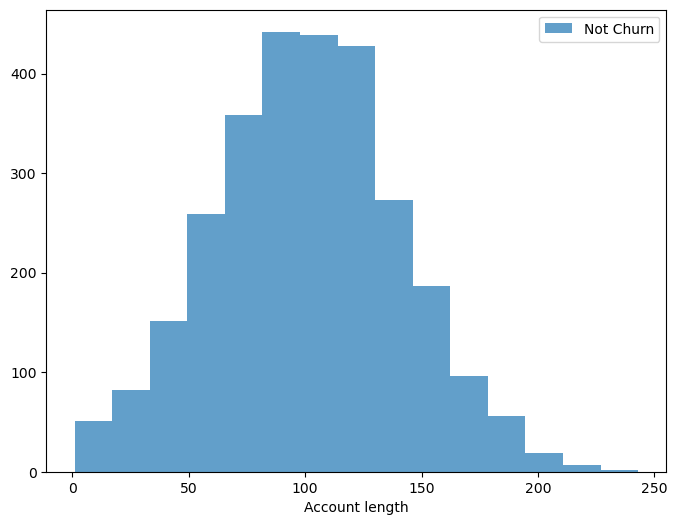

In [33]:
# Filtrage des données pour les clients qui n'ont pas churné
not_churn = df_combined[df_combined["Churn"] == False]

# Distribution de la durée du compte pour les clients qui n'ont pas churné
plt.figure(figsize=(8, 6))
plt.xlabel('Account length')
plt.hist(not_churn["Account length"], bins=15, alpha=0.7, label='Not Churn')
plt.legend(loc='upper right')
plt.show()

**Distribution of Account Length for Churned Customers**

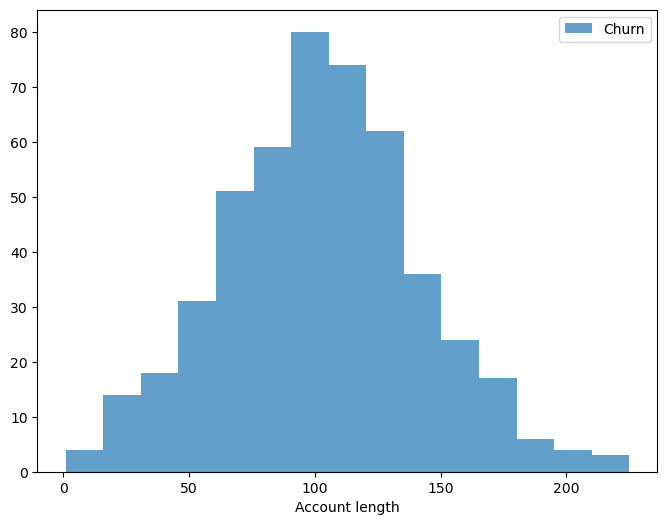

In [34]:
import matplotlib.pyplot as plt

# Filtrage des données pour les clients qui ont churné
churn = df_combined[df_combined["Churn"] == True]

# Distribution de la durée du compte pour les clients ayant churné
plt.figure(figsize=(8, 6))
plt.xlabel('Account length')
plt.hist(churn["Account length"], bins=15, alpha=0.7, label='Churn')
plt.legend(loc='upper right')
plt.show()


C:\Users\21624\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


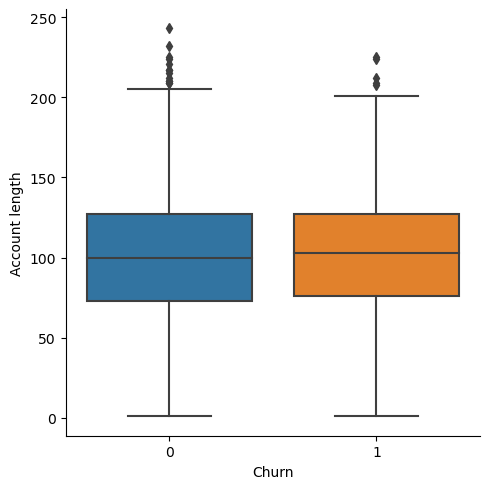

**Class Distribution of Churn (Unbalanced Data)**

In [36]:
# Afficher la distribution des classes de la variable cible
print(df_combined['Churn'].value_counts())

# Optionnel : Afficher en pourcentage
print(df_combined['Churn'].value_counts(normalize=True))

Churn
0    2850
1     483
Name: count, dtype: int64
Churn
0    0.855086
1    0.144914
Name: proportion, dtype: float64


The data is unbalanced, with 85.5% of customers not churning and only 14.5% churning. This imbalance can lead to biased model predictions, favoring the majority class (non-churned customers).

**Exploring the Impact of Various Factors on Customer Churn**

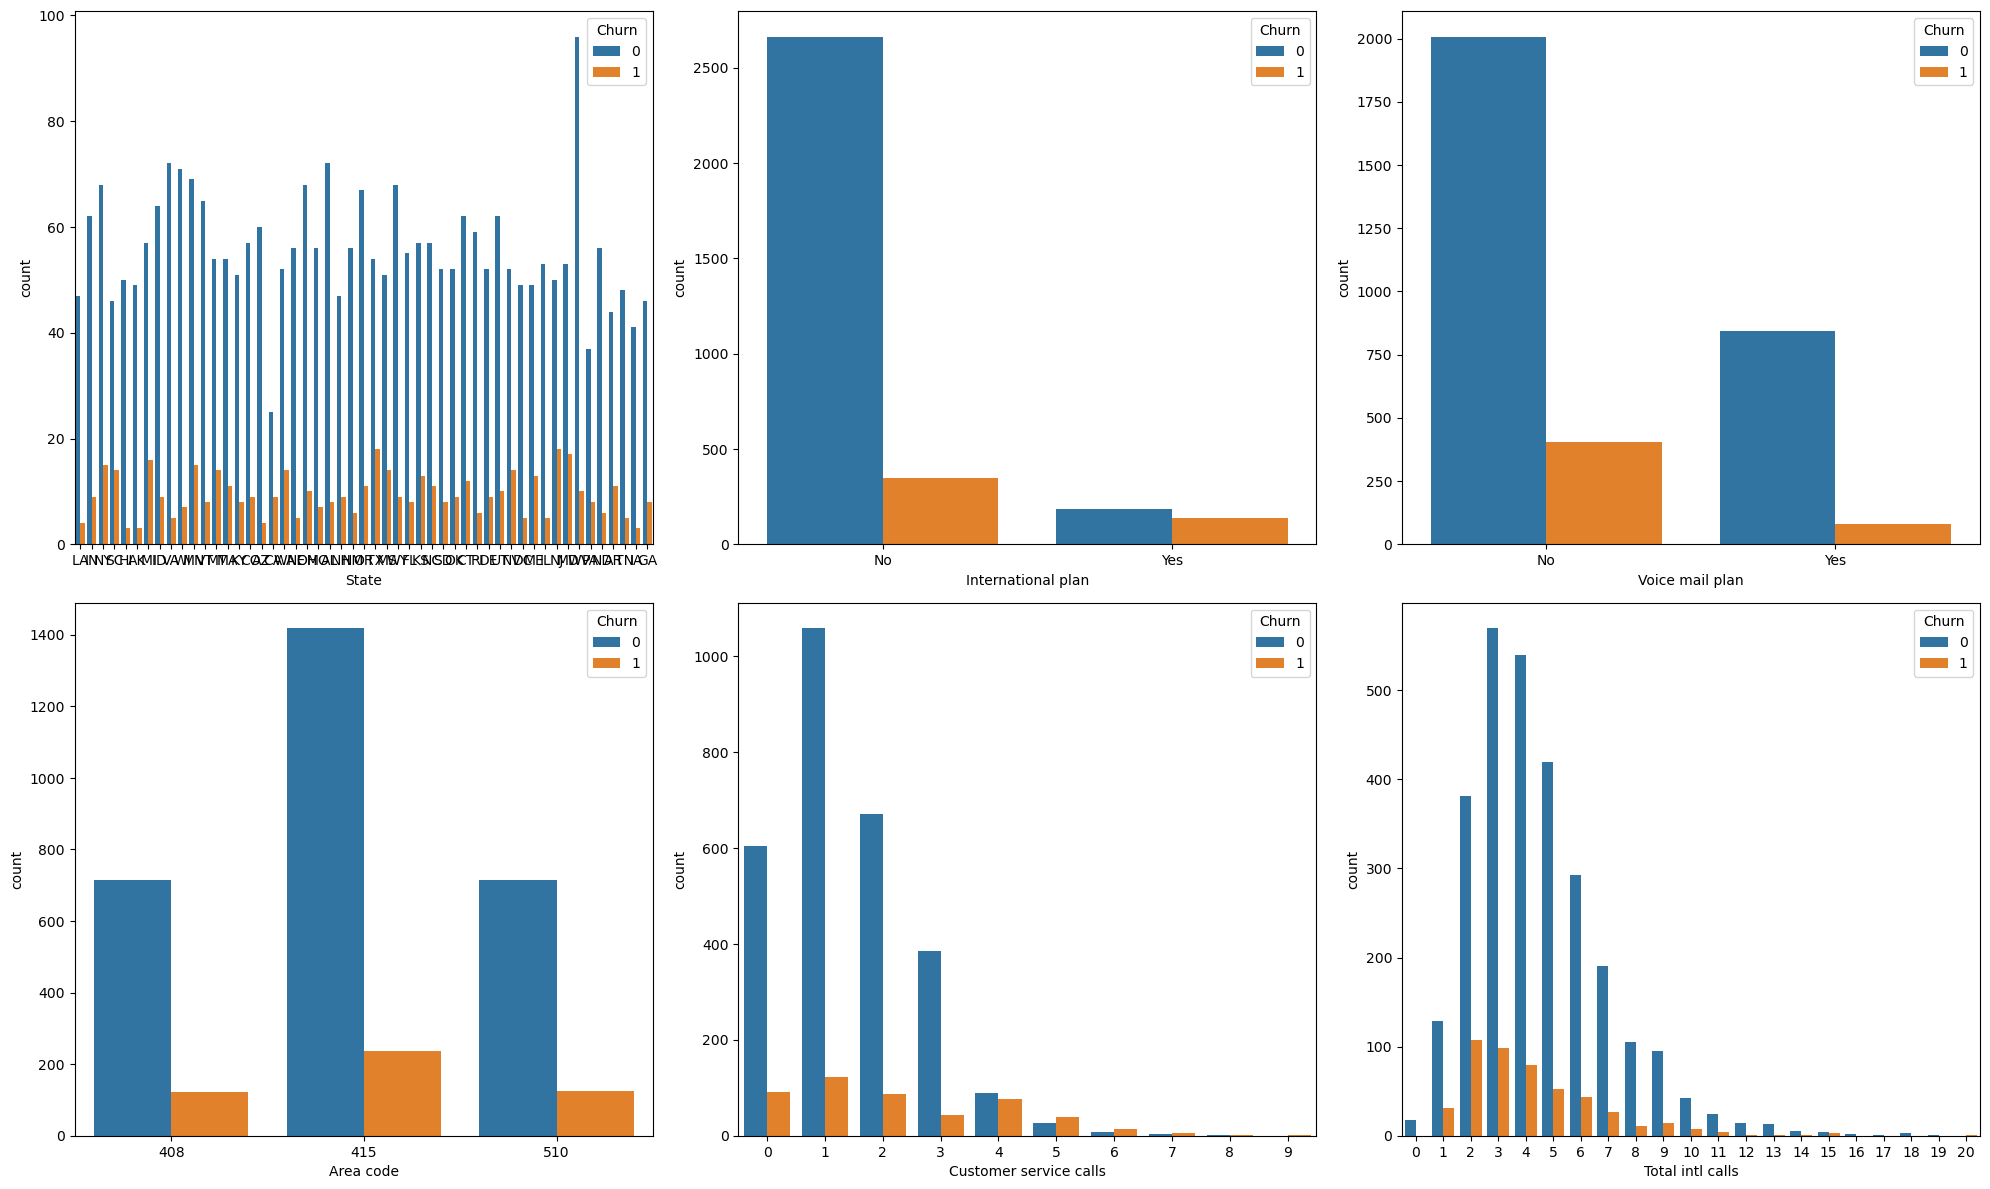

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualiser la relation entre 'Churn' et des variables catégorielles avec countplot
fig, axarr = plt.subplots(2, 3, figsize=(20, 12))

# Visualiser la relation entre 'State' et 'Churn'
sns.countplot(x='State', hue='Churn', data=df_combined, ax=axarr[0][0])

# Visualiser la relation entre 'International plan' et 'Churn'
sns.countplot(x='International plan', hue='Churn', data=df_combined, ax=axarr[0][1])

# Visualiser la relation entre 'Voice mail plan' et 'Churn'
sns.countplot(x='Voice mail plan', hue='Churn', data=df_combined, ax=axarr[0][2])

# Visualiser la relation entre 'Area code' et 'Churn'
sns.countplot(x='Area code', hue='Churn', data=df_combined, ax=axarr[1][0])

# Visualiser la relation entre 'Customer service calls' et 'Churn'
sns.countplot(x='Customer service calls', hue='Churn', data=df_combined, ax=axarr[1][1])

# Visualiser la relation entre 'Total intl calls' et 'Churn'
sns.countplot(x='Total intl calls', hue='Churn', data=df_combined, ax=axarr[1][2])

# Afficher les graphiques
plt.tight_layout()
plt.show()


In [38]:
unique_categories = df_combined["State"].unique()
print(f"Catégories uniques dans 'State': {unique_categories}")







Catégories uniques dans 'State': ['LA' 'IN' 'NY' 'SC' 'HI' 'AK' 'MI' 'ID' 'VA' 'WI' 'MN' 'VT' 'MT' 'MA'
 'KY' 'CO' 'AZ' 'CA' 'WA' 'NE' 'OH' 'MO' 'AL' 'NH' 'NM' 'OR' 'TX' 'MS'
 'WY' 'FL' 'KS' 'NC' 'SD' 'OK' 'CT' 'RI' 'DE' 'UT' 'NV' 'DC' 'ME' 'IL'
 'NJ' 'MD' 'WV' 'PA' 'ND' 'AR' 'TN' 'IA' 'GA']


In [39]:
# Nombre de catégories uniques dans la colonne 'State'
num_categories = df_combined["State"].nunique()

print(f"Nombre de catégories dans 'State': {num_categories}")


Nombre de catégories dans 'State': 51


## **Part 3:Data preparation**

In [40]:
df_copy = df_combined.copy()
print(df_copy.head())

  State  Account length  Area code International plan Voice mail plan  \
0    LA             117        408                 No              No   
1    IN              65        415                 No              No   
2    NY             161        415                 No              No   
3    SC             111        415                 No              No   
4    HI              49        510                 No              No   

   Number vmail messages  Total day minutes  Total day calls  \
0                      0              184.5               97   
1                      0              129.1              137   
2                      0              332.9               67   
3                      0              110.4              103   
4                      0              119.3              117   

   Total day charge  Total eve minutes  Total eve calls  Total eve charge  \
0             31.37              351.6               80             29.89   
1             21.95   

dso 1

dso 1 and 2

# **1.Label Encoding**

In [5]:
d = {"No": 0, "Yes": 1}
df_combined["International plan"] = df_combined["International plan"].map(d)
pd.set_option('future.no_silent_downcasting', True)
df_combined= df_combined.replace({"Voice mail plan": d})
#Churn = 0: Customers who did not churn.
#Churn = 1: Customers who churned
df_combined["Churn"] = df_combined["Churn"].astype("int64")
df_combined.head()


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,LA,117,408,0,0,0,184.5,97,31.37,351.6,80,29.89,215.8,90,9.71,8.7,4,2.35,1,0
1,IN,65,415,0,0,0,129.1,137,21.95,228.5,83,19.42,208.8,111,9.40,12.7,6,3.43,4,1
2,NY,161,415,0,0,0,332.9,67,56.59,317.8,97,27.01,160.6,128,7.23,5.4,9,1.46,4,1
3,SC,111,415,0,0,0,110.4,103,18.77,137.3,102,11.67,189.6,105,8.53,7.7,6,2.08,2,0
4,HI,49,510,0,0,0,119.3,117,20.28,215.1,109,18.28,178.7,90,8.04,11.1,1,3.00,1,0


In [6]:
print(df_combined["International plan"].unique())

[0 1]


**2.Frequency Encoding**

In [7]:
# Frequency Encoding : remplacer les valeurs dans la colonne 'State'
frequency_encoding = df_combined["State"].value_counts()    # Calcul des fréquences
df_combined["State"] = df_combined["State"].map(frequency_encoding)  # Remplacer les catégories par leurs fréquences

# Vérification
print("Colonne 'State' après Frequency Encoding :")
print(df_combined.head())


Colonne 'State' après Frequency Encoding :
   State  Account length  Area code  International plan Voice mail plan  \
0     51             117        408                   0               0   
1     71              65        415                   0               0   
2     83             161        415                   0               0   
3     60             111        415                   0               0   
4     53              49        510                   0               0   

   Number vmail messages  Total day minutes  Total day calls  \
0                      0              184.5               97   
1                      0              129.1              137   
2                      0              332.9               67   
3                      0              110.4              103   
4                      0              119.3              117   

   Total day charge  Total eve minutes  Total eve calls  Total eve charge  \
0             31.37              351.6      

In [8]:
print(df_combined["State"])

0        51
1        71
2        83
3        60
4        53
       ... 
3328     60
3329     64
3330    106
3331     65
3332     53
Name: State, Length: 3333, dtype: int64


**3.Normalisation**

In [9]:
from sklearn.preprocessing import StandardScaler

# Assuming df_combined is your DataFrame
scaler = StandardScaler()

# Sélectionner uniquement les colonnes numériques pour la normalisation
numeric_columns = df_combined.select_dtypes(include=['float64', 'int64']).columns

# Exclure la variable cible 'Churn' des colonnes à normaliser
numeric_columns = numeric_columns.difference(['Churn'])

# Appliquer la standardisation sur les colonnes numériques (hors Churn)
df_combined[numeric_columns] = scaler.fit_transform(df_combined[numeric_columns])

# Afficher les données normalisées
print(df_combined.head())


      State  Account length  Area code  International plan Voice mail plan  \
0 -1.383490        0.400220  -0.688834            -0.32758               0   
1  0.299358       -0.905784  -0.523603            -0.32758               0   
2  1.309067        1.505299  -0.523603            -0.32758               0   
3 -0.626209        0.249527  -0.523603            -0.32758               0   
4 -1.215206       -1.307631   1.718817            -0.32758               0   

   Number vmail messages  Total day minutes  Total day calls  \
0               -0.59176           0.086760        -0.171217   
1               -0.59176          -0.930515         1.822198   
2               -0.59176           2.811735        -1.666277   
3               -0.59176          -1.273891         0.127796   
4               -0.59176          -1.110466         0.825491   

   Total day charge  Total eve minutes  Total eve calls  Total eve charge  \
0          0.087242           2.970436        -1.009773          2.97

## 4.Scaling Numerical Features


In [10]:
from sklearn.preprocessing import StandardScaler

# Select numerical columns for scaling
numerical_cols = ["Total day minutes", "Total day charge", "Total eve minutes", "Total eve charge","Customer service calls","Total intl calls","Number vmail messages","Total night calls","Total day calls" ,"State","Area code",
                  "Total night minutes", "Total night charge", "Total intl minutes","Account length","International plan","Voice mail plan", "Total intl charge","Total eve calls","Total eve charge","Total intl charge"]

scaler = StandardScaler()
df_combined[numerical_cols] = scaler.fit_transform(df_combined[numerical_cols])

dso 3

Engagement_Score represents how engaged a customer is with the service on average over their account lifetime.

In [47]:
df_copy['Engagement_Score'] = (
    df_combined['Total day minutes'] +
    df_combined['Total eve minutes'] +
    df_combined['Total night minutes'] +
    df_combined['Total intl minutes']
) / df_combined['Account length']

Cost-to-Minutes Ratio
Quantify how efficiently customers are using the service based on charges and minutes:

In [48]:
df_copy['Cost_Minutes_Ratio'] = (
    (df_combined['Total day charge'] + df_combined['Total eve charge'] +
     df_combined['Total night charge'] + df_combined['Total intl charge']) /
    (df_combined['Total day minutes'] + df_combined['Total eve minutes'] +
     df_combined['Total night minutes'] + df_combined['Total intl minutes'])
)

Total Usage
Sum up all the minutes or calls across day, evening, night, and international:

In [49]:
df_copy['Total_Usage'] = (
    df_combined['Total day minutes'] +
    df_combined['Total eve minutes'] +
    df_combined['Total night minutes'] +
    df_combined['Total intl minutes']
)

Churn Risk Factor
Combine customer dissatisfaction metrics like customer service calls and usage

In [50]:
df_copy['Churn_Risk_Factor'] = (
    df_combined['Customer service calls'] *
    (df_combined['Total day charge'] + df_combined['Total eve charge'] +
     df_combined['Total night charge'] + df_combined['Total intl charge'])
)

In [51]:
d = {"No": 0, "Yes": 1}
df_copy["International plan"] = df_copy["International plan"].map(d)
pd.set_option('future.no_silent_downcasting', True)
df_copy= df_copy.replace({"Voice mail plan": d})
#Churn = 0: Customers who did not churn.
#Churn = 1: Customers who churned
df_copy["Churn"] = df_copy["Churn"].astype("int64")
df_copy.head()


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,...,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn,Engagement_Score,Cost_Minutes_Ratio,Total_Usage,Churn_Risk_Factor
0,LA,117,408,0,0,0,184.5,97,31.37,351.6,...,9.71,8.7,4,2.35,1,0,7.000388,1.000541,2.801692,-1.199582
1,IN,65,415,0,0,0,129.1,137,21.95,228.5,...,9.40,12.7,6,3.43,4,1,-0.718977,1.003116,0.651237,1.210455
2,NY,161,415,0,0,0,332.9,67,56.59,317.8,...,7.23,5.4,9,1.46,4,1,1.718098,1.000813,2.586251,4.796031
3,SC,111,415,0,0,0,110.4,103,18.77,137.3,...,8.53,7.7,6,2.08,2,0,-14.674320,1.000083,-3.661637,-1.217063
4,HI,49,510,0,0,0,119.3,117,20.28,215.1,...,8.04,11.1,1,3.00,1,0,0.735241,0.998341,-0.961424,0.410742


In [52]:
# Frequency Encoding : remplacer les valeurs dans la colonne 'State'
frequency_encoding = df_copy["State"].value_counts()    # Calcul des fréquences
df_copy["State"] = df_combined["State"].map(frequency_encoding)  # Remplacer les catégories par leurs fréquences

# Vérification
print("Colonne 'State' après Frequency Encoding :")
print(df_copy.head())


Colonne 'State' après Frequency Encoding :
   State  Account length  Area code  International plan Voice mail plan  \
0    NaN             117        408                   0               0   
1    NaN              65        415                   0               0   
2    NaN             161        415                   0               0   
3    NaN             111        415                   0               0   
4    NaN              49        510                   0               0   

   Number vmail messages  Total day minutes  Total day calls  \
0                      0              184.5               97   
1                      0              129.1              137   
2                      0              332.9               67   
3                      0              110.4              103   
4                      0              119.3              117   

   Total day charge  Total eve minutes  ...  Total night charge  \
0             31.37              351.6  ...           

In [13]:
from sklearn.preprocessing import StandardScaler

# Assuming df_combined is your DataFrame
scaler = StandardScaler()

# Sélectionner uniquement les colonnes numériques pour la normalisation
numeric_columns = df_copy.select_dtypes(include=['float64', 'int64']).columns

# Exclure la variable cible 'Churn' des colonnes à normaliser
numeric_columns = numeric_columns.difference(['Churn'])

# Appliquer la standardisation sur les colonnes numériques (hors Churn)
df_copy[numeric_columns] = scaler.fit_transform(df_copy[numeric_columns])

# Afficher les données normalisées
print(df_copy.head())


NameError: name 'df_copy' is not defined

## 5.PCA


In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pandas as pd


# Méthode du coude (Elbow Method) pour déterminer le nombre optimal de clusters
wcss = []  # Within-cluster sum of squares (WCSS)
for i in range(1, 11):  # Essayer de 1 à 10 clusters
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(pca_df[['PCA1', 'PCA2']])
    wcss.append(kmeans.inertia_)

# Tracer le graphique pour la méthode du coude
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Méthode du coude pour déterminer le nombre optimal de clusters')
plt.xlabel('Nombre de clusters')
plt.ylabel('WCSS')
plt.show()


C:\Users\21624\anaconda3\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
C:\Users\21624\anaconda3\Lib\site-packages\sklearn\utils\_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
C:\Users\21624\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:110: UserWarning: Could not find the number of physical cores for the following reason:
[WinEr

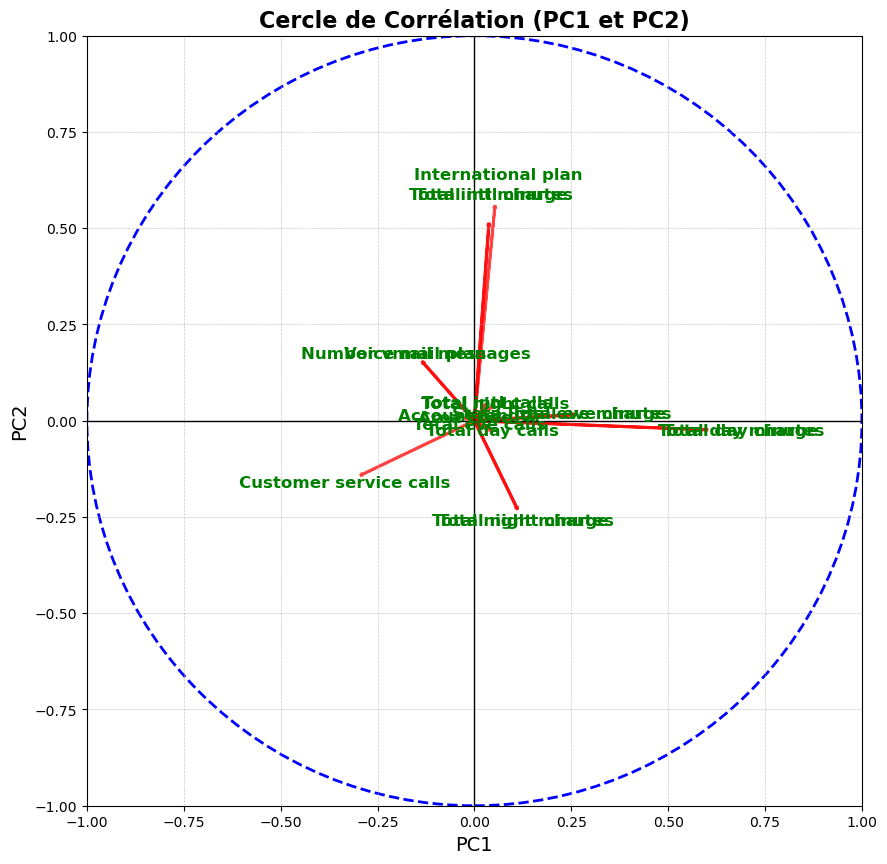

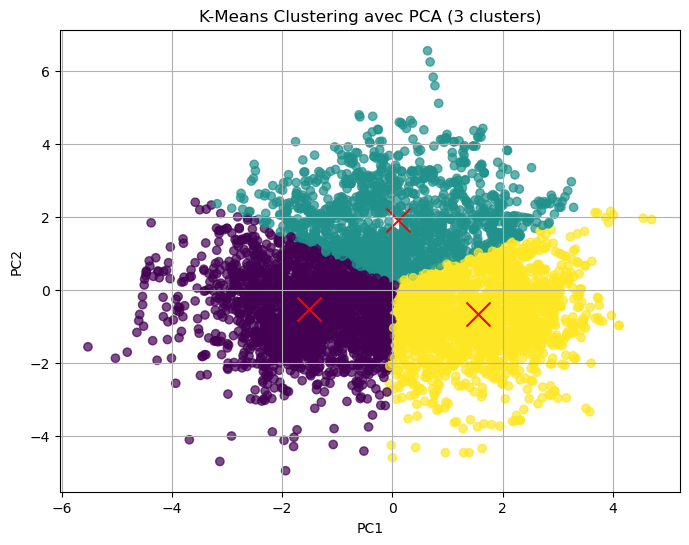

Variance expliquée cumulée pour les 2 premières composantes principales :
Composante 1: 14.89%
Composante 2: 26.00%


In [11]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import EditedNearestNeighbours

# Appliquer SMOTE pour équilibrer les classes
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(df_combined.drop(columns='Churn'), df_combined['Churn'])  # 'target' est la colonne de la cible

# Appliquer ENN pour nettoyer les exemples erronés
enn = EditedNearestNeighbours()
X_resampled, y_resampled = enn.fit_resample(X_resampled, y_resampled)

# PCA sur les données équilibrées
pca = PCA()
pca_data = pca.fit_transform(X_resampled)
explained_variance = np.cumsum(pca.explained_variance_ratio_)

# Cercle de corrélation amélioré avec ajustements pour les labels
def plot_correlation_circle(pca, components, feature_names):
    plt.figure(figsize=(10, 10))  # Taille de la figure
    for i, feature in enumerate(feature_names):
        # Flèches visibles
        plt.arrow(0, 0, components[i, 0], components[i, 1], color='r', alpha=0.7, linewidth=2)

        # Positionner le texte avec un décalage plus important pour éviter les chevauchements
        x_pos = components[i, 0] * 1.15
        y_pos = components[i, 1] * 1.15

        # Éviter les chevauchements en modifiant dynamiquement la position du texte
        if x_pos > 1:
            x_pos = 1.05
        elif x_pos < -1:
            x_pos = -1.05
        if y_pos > 1:
            y_pos = 1.05
        elif y_pos < -1:
            y_pos = -1.05

        plt.text(x_pos, y_pos, feature, color='green', ha='center', va='center', fontsize=12, fontweight='bold')

    plt.xlim(-1, 1)
    plt.ylim(-1, 1)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)  # Grille subtile
    plt.xlabel("PC1", fontsize=14)
    plt.ylabel("PC2", fontsize=14)
    plt.title("Cercle de Corrélation (PC1 et PC2)", fontsize=16, fontweight='bold')
    plt.axhline(0, color='black', linewidth=1)
    plt.axvline(0, color='black', linewidth=1)

    # Cercle de corrélation renforcé
    circle = plt.Circle((0, 0), 1, color='blue', fill=False, linestyle='--', linewidth=2)
    plt.gca().add_artist(circle)

    plt.show()

# Calculer les composantes des variables
components = pca.components_.T[:, :2]  # PC1 et PC2
feature_names = X_resampled.columns
plot_correlation_circle(pca, components, feature_names)

# K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(pca_data[:, :2])  # Utiliser les 2 premières composantes principales

# Visualisation des clusters
plt.figure(figsize=(8, 6))
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=clusters, cmap='viridis', alpha=0.7)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='red', marker='x')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clustering avec PCA (3 clusters)")
plt.grid()
plt.show()


# Résumé de la variance expliquée pour les 2 premières composantes
print("Variance expliquée cumulée pour les 2 premières composantes principales :")
for i in range(2):  # Se limiter aux 2 premières composantes
    print(f"Composante {i+1}: {explained_variance[i]:.2%}")






The variables such as "Total intl minutes", "Customer service calls", and "Voice mail messages" are strongly correlated with the principal components, suggesting that they play a key role in predicting churn.

These patterns indicate that these features have a high impact on customers' decisions to stay or leave, and are essential for understanding churn behavior in this analysis.

## clustering

elbow Method (methode de coude )

La méthode de coude (Elbow Method) est une technique utilisée pour déterminer le nombre optimal de clusters dans un algorithme de clustering, comme K-means. Elle consiste à évaluer la somme des distances au carré (Within-Cluster Sum of Squares, WCSS) entre chaque point et le centre de son cluster pour différents nombres de clusters k.
donc on choisit comme nombre de cluster optimale k =3.

Function SMOTE and ENN sur une DataFrame complète

In [12]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import EditedNearestNeighbours
from collections import Counter
import pandas as pd

# Fonction pour appliquer SMOTE et ENN sur une DataFrame complète
def apply_smote_and_enn_full_data(data, Churn):

    # Appliquer SMOTE pour suréchantillonner les classes minoritaires
    smote = SMOTE(sampling_strategy='auto', random_state=42)
    X_smote, Y_smote = smote.fit_resample(data.drop(columns=[Churn]), data[Churn])

    # Appliquer ENN pour réduire les exemples mal classés
    enn = EditedNearestNeighbours()
    X_smote_enn, Y_smote_enn = enn.fit_resample(X_smote, Y_smote)

    # Reconstruire la DataFrame complète avec caractéristiques et cible
    resampled_data = pd.concat([pd.DataFrame(X_smote_enn, columns=data.drop(columns=[target_column]).columns),
                                pd.Series(Y_smote_enn, name=target_column)], axis=1)

    # Vérifier la distribution des classes après SMOTE + ENN
    print("Class distribution after SMOTE + ENN:", Counter(Y_smote_enn))

    return resampled_data

# Exemple d'utilisation
# Identifier la colonne cible
target_column = "Churn"

# Appliquer la fonction directement sur df_combined
df_resampled_SMOTEENN = apply_smote_and_enn_full_data(df_combined, target_column)

# Afficher les données rééquilibrées
print("Données rééquilibrées avec SMOTE et ENN :")
print(df_resampled_SMOTEENN.head())


C:\Users\21624\anaconda3\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
C:\Users\21624\anaconda3\Lib\site-packages\sklearn\utils\_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
C:\Users\21624\anaconda3\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.

Class distribution after SMOTE + ENN: Counter({0: 2850, 1: 2794})
Données rééquilibrées avec SMOTE et ENN :
      State  Account length  Area code  International plan  Voice mail plan  \
0 -1.383490        0.400220  -0.688834            -0.32758        -0.618396   
1 -0.626209        0.249527  -0.523603            -0.32758        -0.618396   
2 -1.215206       -1.307631   1.718817            -0.32758        -0.618396   
3 -1.299348       -1.634132  -0.688834            -0.32758         1.617086   
4  0.467643       -0.905784  -0.523603            -0.32758        -0.618396   

   Number vmail messages  Total day minutes  Total day calls  \
0              -0.591760           0.086760        -0.171217   
1              -0.591760          -1.273891         0.127796   
2              -0.591760          -1.110466         0.825491   
3               1.600211          -0.614682         1.373680   
4              -0.591760           0.578872         0.974997   

   Total day charge  Total eve m

## up_sampling with all data

In [13]:
from sklearn.utils import resample
from collections import Counter
import pandas as pd

# Fonction pour appliquer l'up-sampling sur une DataFrame complète
def apply_up_sampling_full_data(data, Churn):

    # Taille de la classe majoritaire
    major_class_size = data[Churn].value_counts().max()

    # Appliquer l'up-sampling pour chaque classe
    resampled_data = pd.concat([
        resample(data[data[Churn] == cls],
                 replace=True,  # Échantillonnage avec remplacement
                 n_samples=major_class_size,  # Nombre d'échantillons à égaliser
                 random_state=42)
        for cls in data[Churn].unique()
    ])

    # Mélanger les données après le rééquilibrage
    resampled_data = resampled_data.sample(frac=1, random_state=42).reset_index(drop=True)

    # Vérifier la distribution des classes après l'up-sampling
    print("Class distribution after up-sampling:", Counter(resampled_data[Churn]))

    return resampled_data

# Exemple d'utilisation
# Identifier la colonne cible
target_column = "Churn"

# Appliquer la fonction directement sur df_combined
df_resampled_Upsamppling = apply_up_sampling_full_data(df_combined, target_column)

# Afficher les données rééquilibrées
print("Données rééquilibrées avec up-sampling :")
print(df_resampled_Upsamppling.head())


Class distribution after up-sampling: Counter({0: 2850, 1: 2850})
Données rééquilibrées avec up-sampling :
      State  Account length  Area code  International plan  Voice mail plan  \
0  0.804213       -0.981130  -0.523603            -0.32758        -0.618396   
1 -0.121354        0.977875  -0.523603            -0.32758        -0.618396   
2  0.467643       -0.227667  -0.523603            -0.32758         1.617086   
3  0.804213        0.098834  -0.523603            -0.32758        -0.618396   
4 -1.131063        0.199296   1.718817            -0.32758         1.617086   

   Number vmail messages  Total day minutes  Total day calls  \
0              -0.591760          -0.135424         1.573021   
1              -0.591760          -0.552250        -1.466936   
2               1.527146           0.395248         1.473350   
3              -0.591760           1.460265        -0.221052   
4               1.965540           0.931429         0.775655   

   Total day charge  Total eve mi

## data Split (unbalanced data)

In [14]:
from sklearn.model_selection import train_test_split
# features
X = df_combined.drop(columns=["Churn"])
#target
Y = df_combined["Churn"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)



## data Split (balanced data with smoteen)

In [15]:
from sklearn.model_selection import train_test_split
# features
X_With_Smoteenn = df_resampled_SMOTEENN.drop(columns=["Churn"])
#target
Y_With_Smoteenn  = df_resampled_SMOTEENN["Churn"]

X_train_With_Smoteenn , X_test_With_Smoteenn , Y_train_With_Smoteenn , Y_test_With_Smoteenn  = train_test_split(X_With_Smoteenn , Y_With_Smoteenn , test_size=0.2)

## data Split (balanced data with uppsampling)

In [17]:
from sklearn.model_selection import train_test_split
# features
X_with_uppSampling= df_resampled_Upsamppling.drop(columns=["Churn"])
#target
Y_with_uppSampling = df_resampled_Upsamppling["Churn"]

X_train_with_uppSampling, X_test_with_uppSampling, Y_train_with_uppSampling, Y_test_with_uppSampling = train_test_split(X, Y, test_size=0.2)

## **Modeling**

DSO1

## Decision tree

1.unbalanced data 

In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Initialisation du modèle Decision Tree
dt_original = DecisionTreeClassifier()

# Entraînement du modèle
dt_original.fit(X_train, Y_train)

# Prédictions sur les données de test
Y_pred_original = dt_original.predict(X_test)

# Calcul et affichage de l'exactitude
accuracy_original = accuracy_score(Y_test, Y_pred_original)
print(f"Decision Tree Accuracy on Original Data: {accuracy_original:.4f}")


Decision Tree Accuracy on Original Data: 0.9025


2.Decision Tree sur les données SMOTEENN (resampling)

In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Initialisation du modèle Decision Tree
dt_smoteenn = DecisionTreeClassifier()

# Entraînement du modèle
dt_smoteenn.fit(X_train_With_Smoteenn, Y_train_With_Smoteenn)

# Prédictions sur les données de test (en utilisant X_test_With_Smoteenn)
Y_pred_smoteenn  = dt_smoteenn.predict(X_test_With_Smoteenn)

# Calcul et affichage de l'exactitude
accuracy_smoteenn = accuracy_score(Y_test_With_Smoteenn, Y_pred_smoteenn)
print(f"Decision Tree Accuracy on SMOTEENN Resampled Data: {accuracy_smoteenn:.4f}")


Decision Tree Accuracy on SMOTEENN Resampled Data: 0.9345


3. Decision Tree sur les données Upsampling

In [20]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Initialisation du modèle Decision Tree
dt_uppSampling = DecisionTreeClassifier()

# Entraînement du modèle
dt_uppSampling.fit(X_train_with_uppSampling, Y_train_with_uppSampling)

# Prédictions sur les données de test
Y_pred_uppSampling = dt_uppSampling.predict(X_test_with_uppSampling)

# Calcul et affichage de l'exactitude
accuracy_uppSampling = accuracy_score(Y_test_with_uppSampling, Y_pred_uppSampling)
print(f"Decision Tree Accuracy on Upsampled Data: {accuracy_uppSampling:.4f}")


Decision Tree Accuracy on Upsampled Data: 0.9145


decision tree for unbalnced data 

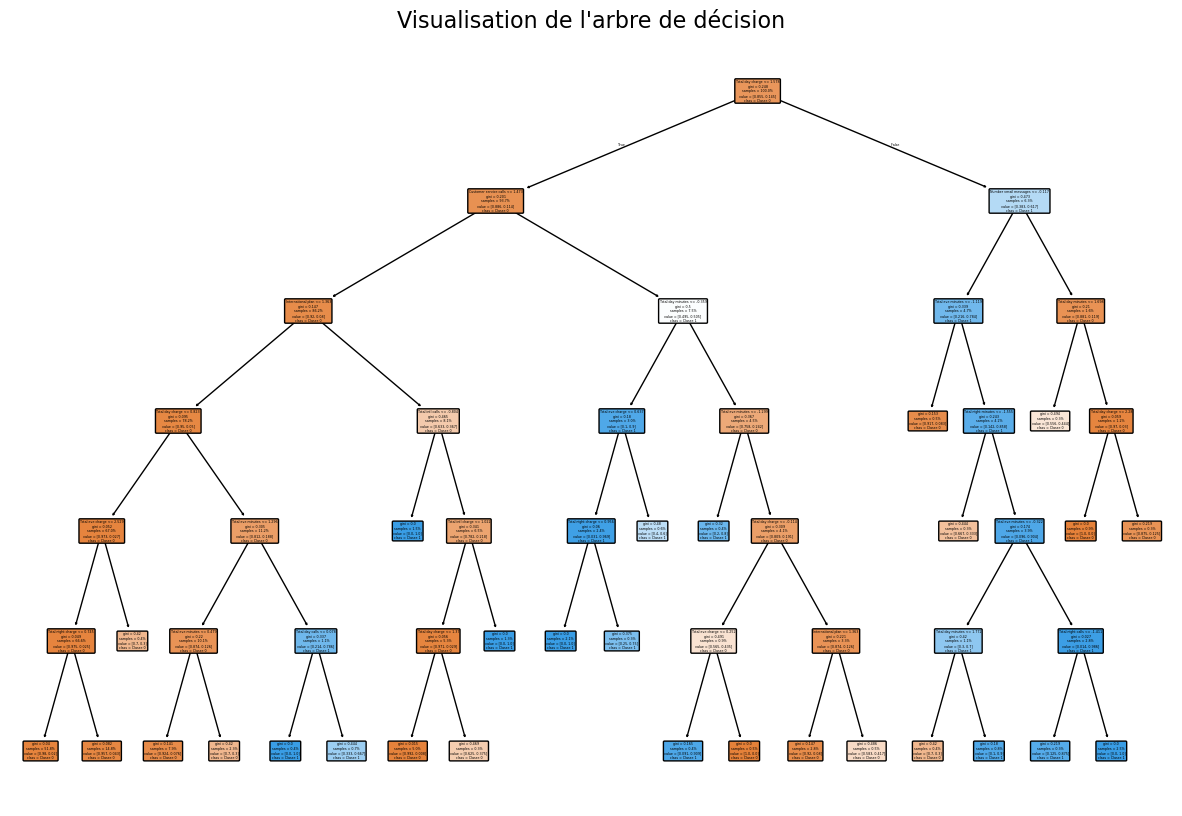

In [54]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Initialisation du modèle Decision Tree
model_dt = DecisionTreeClassifier(
    criterion="gini",         # Critère pour évaluer les splits (par exemple, "gini" ou "entropy")
    max_depth=6,              # Profondeur maximale de l'arbre
    min_samples_leaf=8,       # Nombre minimum d'échantillons par feuille
    random_state=100          # Pour des résultats reproductibles
)

# Entraînement du modèle avec les données d'entraînement
model_dt.fit(X_train, y_train)


# Visualiser l'arbre de décision
plt.figure(figsize=(15, 10))  # Ajuster la taille du graphique
plot_tree(
    model_dt,                # Modèle Decision Tree entraîné
    feature_names=X_train.columns,  # Noms des colonnes (features)
    class_names=["Classe 0", "Classe 1"],  # Noms des classes (adaptez selon vos classes)
    filled=True,             # Remplir les nœuds avec des couleurs
    rounded=True,            # Coins arrondis pour une meilleure lisibilité
    proportion=True          # Afficher les proportions au lieu des counts absolus
)
plt.title("Visualisation de l'arbre de décision", fontsize=16)
plt.show()

decision tree with SMOTEENN

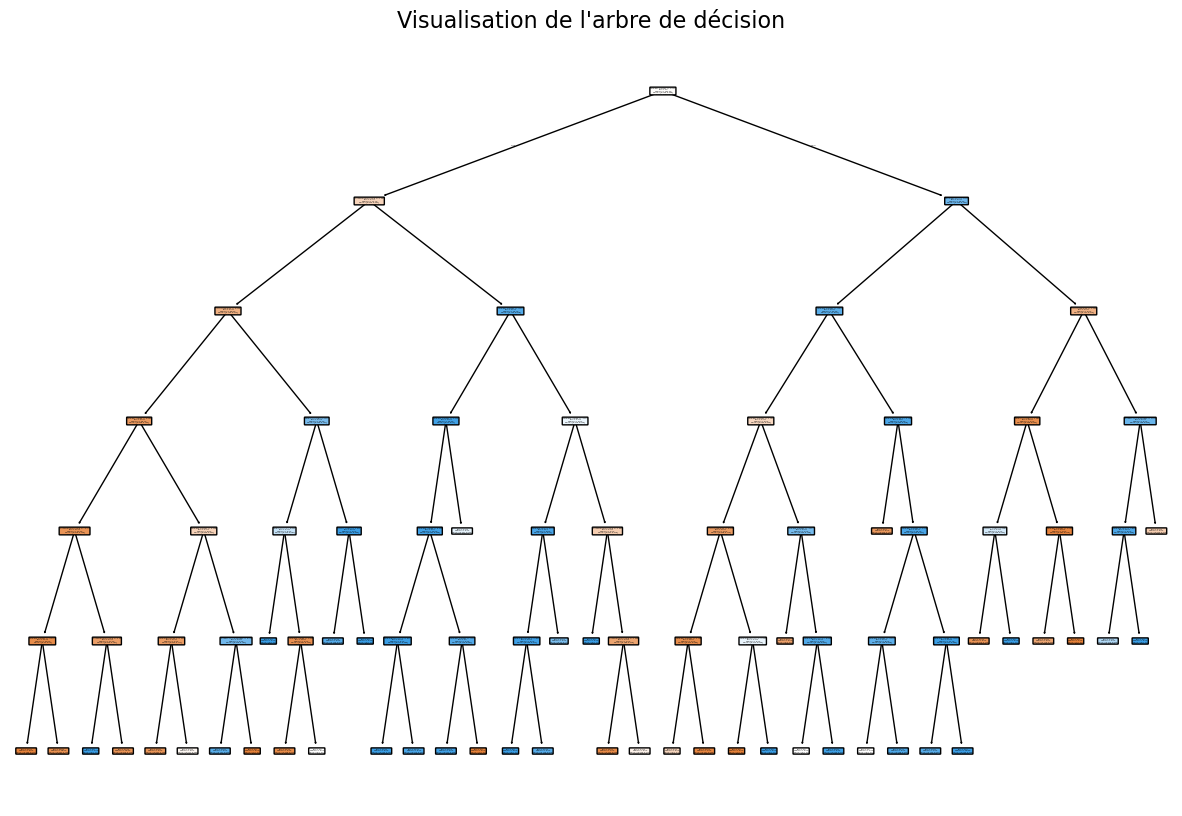

In [55]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Initialisation du modèle aDecision Tree
model_dt_smote = DecisionTreeClassifier(
    criterion="gini",         # Critère pour évaluer les splits (par exemple, "gini" ou "entropy")
    max_depth=6,              # Profondeur maximale de l'arbre
    min_samples_leaf=8,       # Nombre minimum d'échantillons par feuille
    random_state=100          # Pour des résultats reproductibles
)

# Entraînement du modèle avec les données d'entraînement
model_dt_smote.fit(X_With_Smoteenn, Y_With_Smoteenn)


# Visualiser l'arbre de décision
plt.figure(figsize=(15, 10))  # Ajuster la taille du graphique
plot_tree(
    model_dt_smote,                # Modèle Decision Tree entraîné
    feature_names=X_With_Smoteenn.columns,  # Noms des colonnes (features)
    class_names=["Classe 0", "Classe 1"],  # Noms des classes (adaptez selon vos classes)
    filled=True,             # Remplir les nœuds avec des couleurs
    rounded=True,            # Coins arrondis pour une meilleure lisibilité
    proportion=True          # Afficher les proportions au lieu des counts absolus
)
plt.title("Visualisation de l'arbre de décision", fontsize=16)
plt.show()

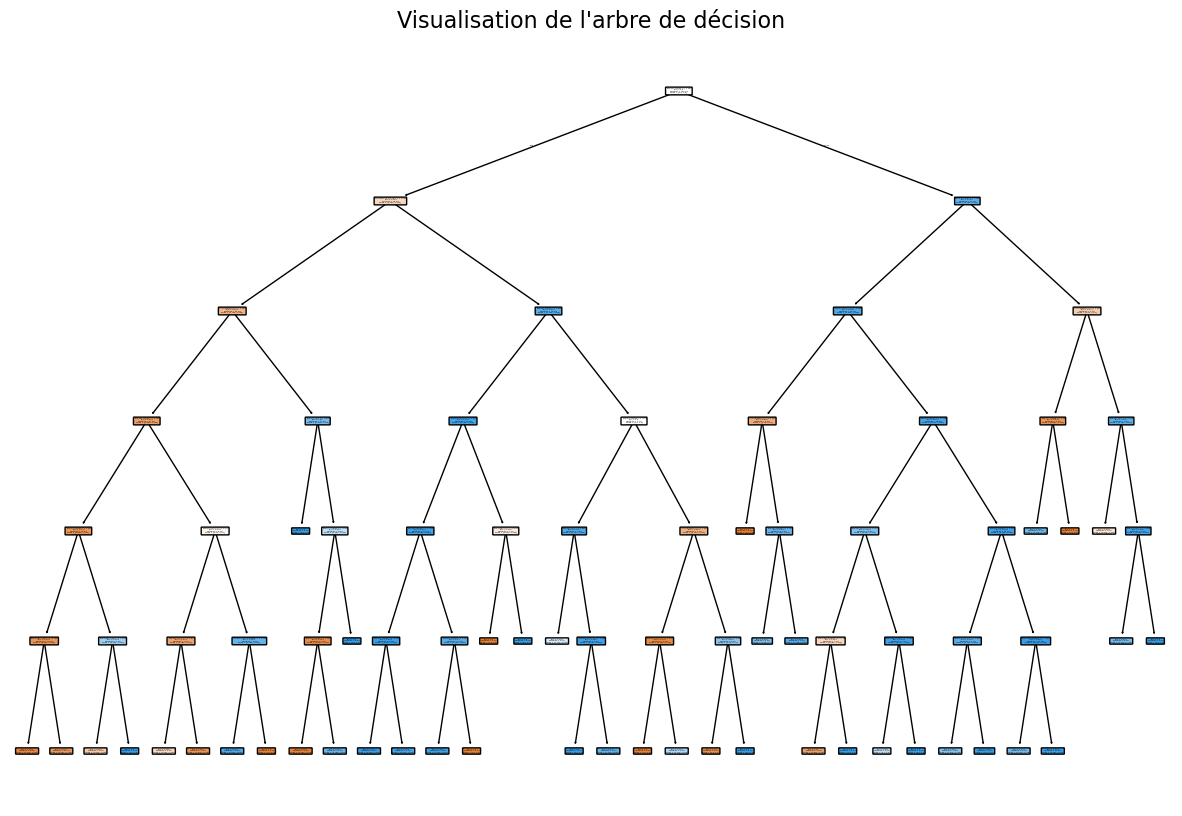

In [56]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Initialisation du modèle Decision Tree
model_dt_up = DecisionTreeClassifier(
    criterion="gini",         # Critère pour évaluer les splits (par exemple, "gini" ou "entropy")
    max_depth=6,              # Profondeur maximale de l'arbre
    min_samples_leaf=8,       # Nombre minimum d'échantillons par feuille
    random_state=100          # Pour des résultats reproductibles
)

# Entraînement du modèle avec les données d'entraînement
model_dt_up.fit(X_with_uppSampling, Y_with_uppSampling)


# Visualiser l'arbre de décision
plt.figure(figsize=(15, 10))  # Ajuster la taille du graphique
plot_tree(
    model_dt_up,                # Modèle Decision Tree entraîné
    feature_names=X_with_uppSampling.columns,  # Noms des colonnes (features)
    class_names=["Classe 0", "Classe 1"],  # Noms des classes (adaptez selon vos classes)
    filled=True,             # Remplir les nœuds avec des couleurs
    rounded=True,            # Coins arrondis pour une meilleure lisibilité
    proportion=True          # Afficher les proportions au lieu des counts absolus
)
plt.title("Visualisation de l'arbre de décision", fontsize=16)
plt.show()

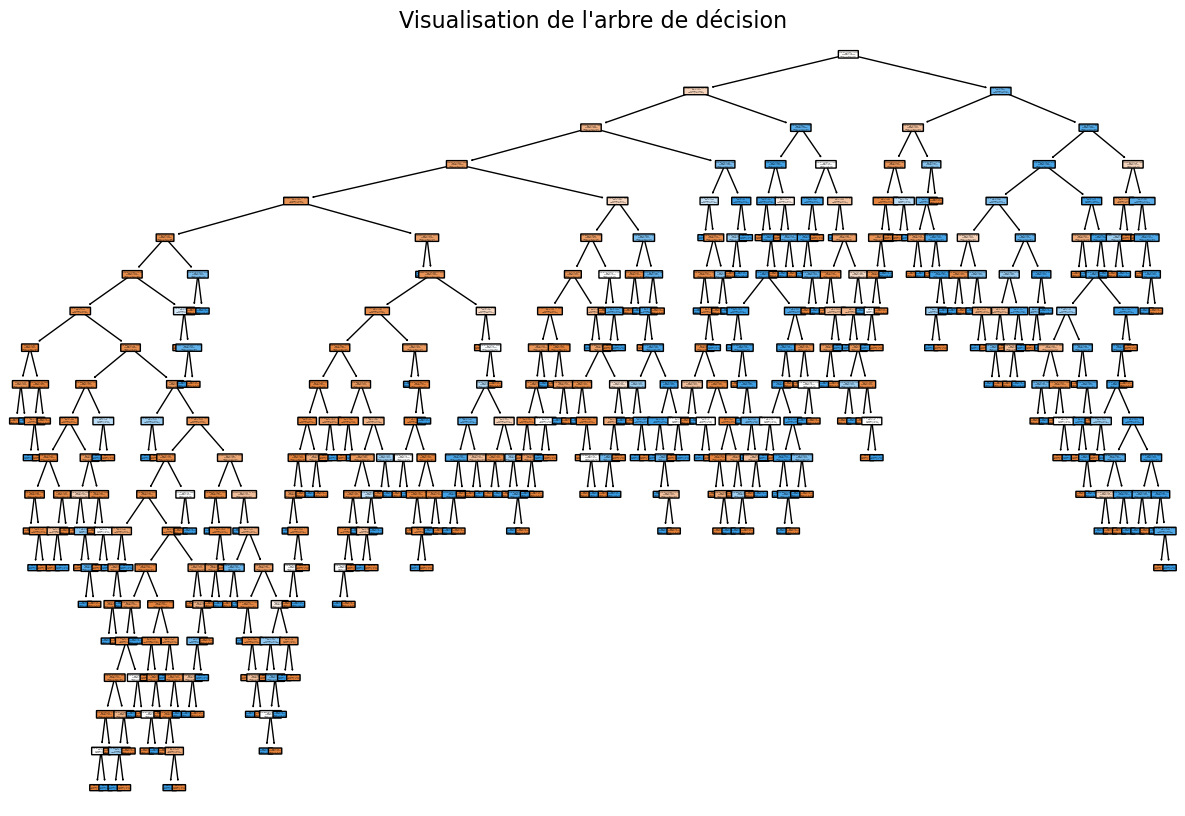

In [23]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
# Visualiser l'arbre de décision
plt.figure(figsize=(15, 10))  # Ajuster la taille du graphique
plot_tree(
    dt_smoteenn,                # Modèle Decision Tree entraîné
    feature_names=X_train_With_Smoteenn.columns,  # Noms des colonnes (features)
    class_names=["Classe 0", "Classe 1"],  # Noms des classes (adaptez selon vos classes)
    filled=True,             # Remplir les nœuds avec des couleurs
    rounded=True,            # Coins arrondis pour une meilleure lisibilité
    proportion=True          # Afficher les proportions au lieu des counts absolus
)
plt.title("Visualisation de l'arbre de décision", fontsize=16)
plt.show()


Feature selection of decision tree

Feature Importances:
                   Feature  Importance
18  Customer service calls    0.238958
6        Total day minutes    0.169686
3       International plan    0.140299
17       Total intl charge    0.058037
11        Total eve charge    0.053076
9        Total eve minutes    0.048248
8         Total day charge    0.041663
4          Voice mail plan    0.037128
16        Total intl calls    0.034465
1           Account length    0.024768
10         Total eve calls    0.021327
12     Total night minutes    0.021060
7          Total day calls    0.020881
5    Number vmail messages    0.020356
13       Total night calls    0.018414
14      Total night charge    0.014022
0                    State    0.013417
2                Area code    0.012356
15      Total intl minutes    0.011839


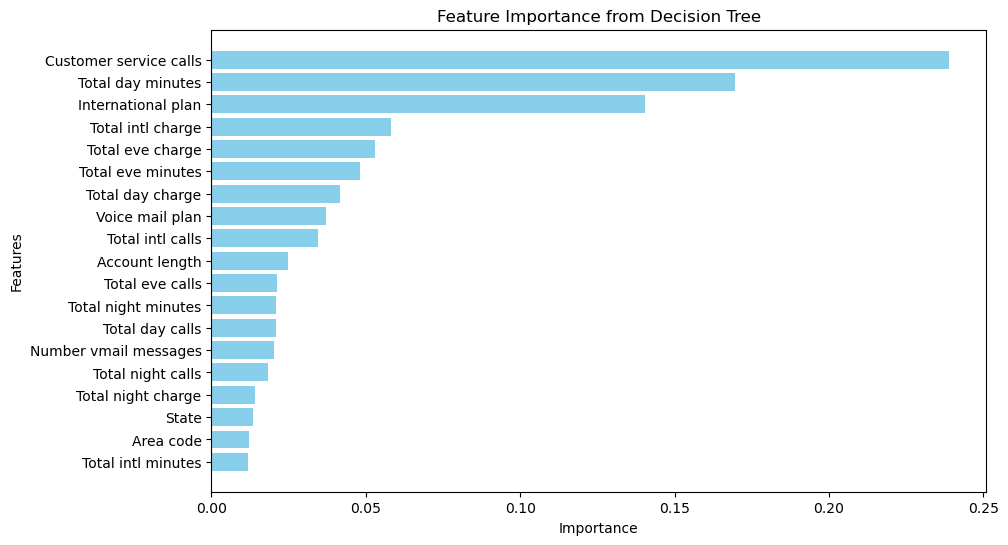

Decision Tree Accuracy after Feature Selection: 0.9300


In [71]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Affichage de l'importance des features
feature_importances = pd.DataFrame({
    'Feature': X_train_With_Smoteenn.columns,
    'Importance': dt_smoteenn.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Feature Importances:")
print(feature_importances)

# Visualisation des importances des features
plt.figure(figsize=(10, 6))
plt.barh(feature_importances['Feature'], feature_importances['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance from Decision Tree')
plt.gca().invert_yaxis()  # Invert the y-axis to show the highest importance at the top
plt.show()

# Sélection des features importantes (par exemple, importance > seuil de 0.01)
selected_features = feature_importances[feature_importances['Importance'] > 0.01]['Feature']
X_train_selected = X_train_With_Smoteenn[selected_features]
X_test_selected = X_test_With_Smoteenn[selected_features]

# Réentraînement avec les features sélectionnées
dt_smoteenn_selected = DecisionTreeClassifier()
dt_smoteenn_selected.fit(X_train_selected, Y_train_With_Smoteenn)

# Prédictions sur les données de test avec features sélectionnées
Y_pred_selected = dt_smoteenn_selected.predict(X_test_selected)

# Calcul et affichage de l'exactitude
accuracy_selected = accuracy_score(Y_test_With_Smoteenn, Y_pred_selected)
print(f"Decision Tree Accuracy after Feature Selection: {accuracy_selected:.4f}")


## Random forest

1.Random Forest sur les données originales

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Initialisation du modèle Random Forest
rf_original = RandomForestClassifier()

# Entraînement du modèle
rf_original.fit(X_train, Y_train)

# Prédictions sur les données de test
Y_pred_rf_original  = rf_original.predict(X_test)

# Calcul et affichage de l'exactitude
accuracy_original = accuracy_score(Y_test, Y_pred_original)
print(f"Random Forest Accuracy on Original Data: {accuracy_original:.4f}")


Random Forest Accuracy on Original Data: 0.9025


2. Random Forest sur les données SMOTEENN (resampling)

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Initialisation du modèle Random Forest
rf_smoteenn = RandomForestClassifier()

# Entraînement du modèle
rf_smoteenn.fit(X_train_With_Smoteenn, Y_train_With_Smoteenn)

# Prédictions sur les données de test
Y_pred_rf_smoteenn  = rf_smoteenn.predict(X_test_With_Smoteenn)

# Calcul et affichage de l'exactitude
accuracy_smoteenn = accuracy_score(Y_test_With_Smoteenn, Y_pred_smoteenn)
print(f"Random Forest Accuracy on SMOTEENN Resampled Data: {accuracy_smoteenn:.4f}")


Random Forest Accuracy on SMOTEENN Resampled Data: 0.9345


3. Random Forest sur les données Upsampling

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Initialisation du modèle Random Forest
rf_uppSampling = RandomForestClassifier()

# Entraînement du modèle
rf_uppSampling.fit(X_train_with_uppSampling, Y_train_with_uppSampling)

# Prédictions sur les données de test
Y_pred_rf_uppSampling = rf_uppSampling.predict(X_test_with_uppSampling)

# Calcul et affichage de l'exactitude
accuracy_uppSampling = accuracy_score(Y_test_with_uppSampling, Y_pred_uppSampling)
print(f"Random Forest Accuracy on Upsampled Data: {accuracy_uppSampling:.4f}")


Random Forest Accuracy on Upsampled Data: 0.9145


Random forest with uppsampled

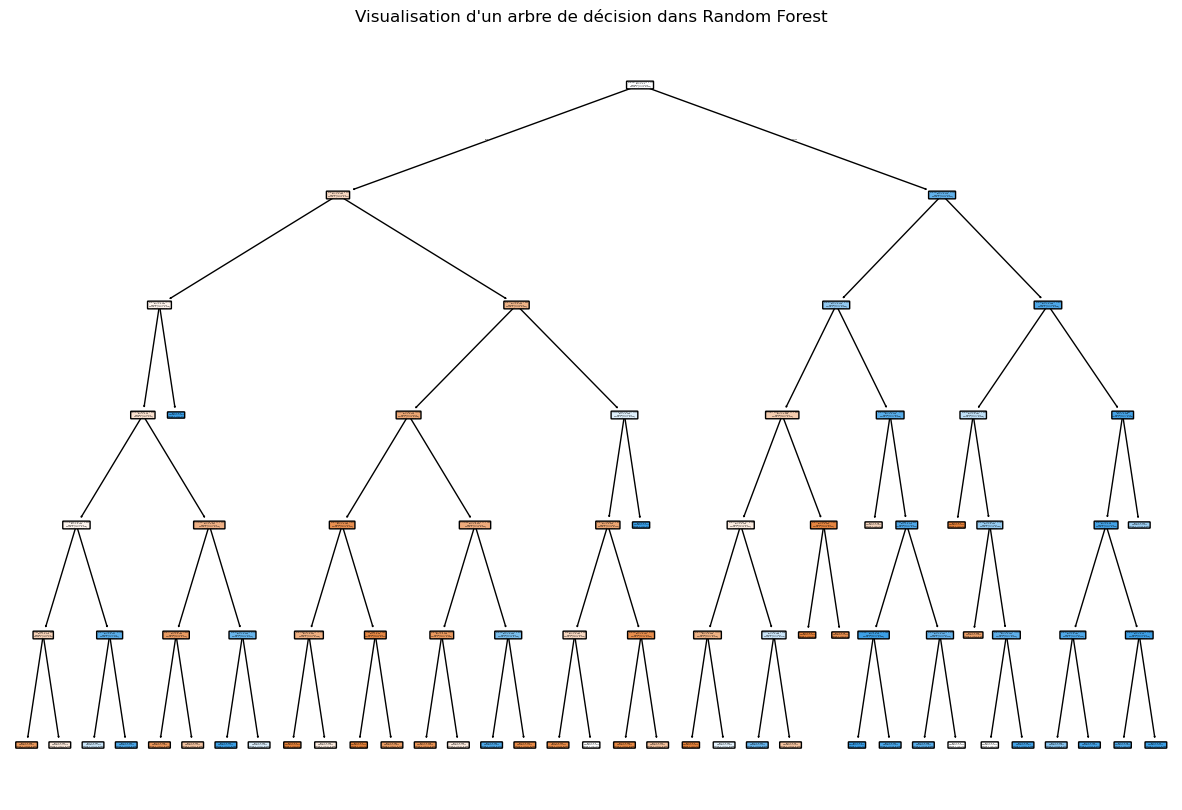

In [57]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Créer et entraîner le modèle Random Forest
model_rf_smote = RandomForestClassifier(n_estimators=100, criterion='gini', random_state=100, max_depth=6, min_samples_leaf=8)
model_rf_smote.fit(X_With_Smoteenn, Y_With_Smoteenn)

# Choisir un arbre spécifique de la forêt (par exemple, le premier arbre)
estimator = model_rf_smote.estimators_[0]  # Le premier arbre dans la forêt

# Visualisation de l'arbre
plt.figure(figsize=(15, 10))  # Ajuster la taille du graphique
plot_tree(
    estimator,                # Arbre individuel du modèle Random Forest
    feature_names=X_With_Smoteenn.columns,  # Noms des colonnes (features)
    class_names=["Classe 0", "Classe 1"],  # Noms des classes (adaptez selon vos classes)
    filled=True,             # Remplir les nœuds avec des couleurs
    rounded=True,            # Coins arrondis pour une meilleure lisibilité
    proportion=True          # Afficher les proportions au lieu des counts absolus
)
plt.title("Visualisation d'un arbre de décision dans Random Forest")
plt.show()


RAndom forest with SMOTE

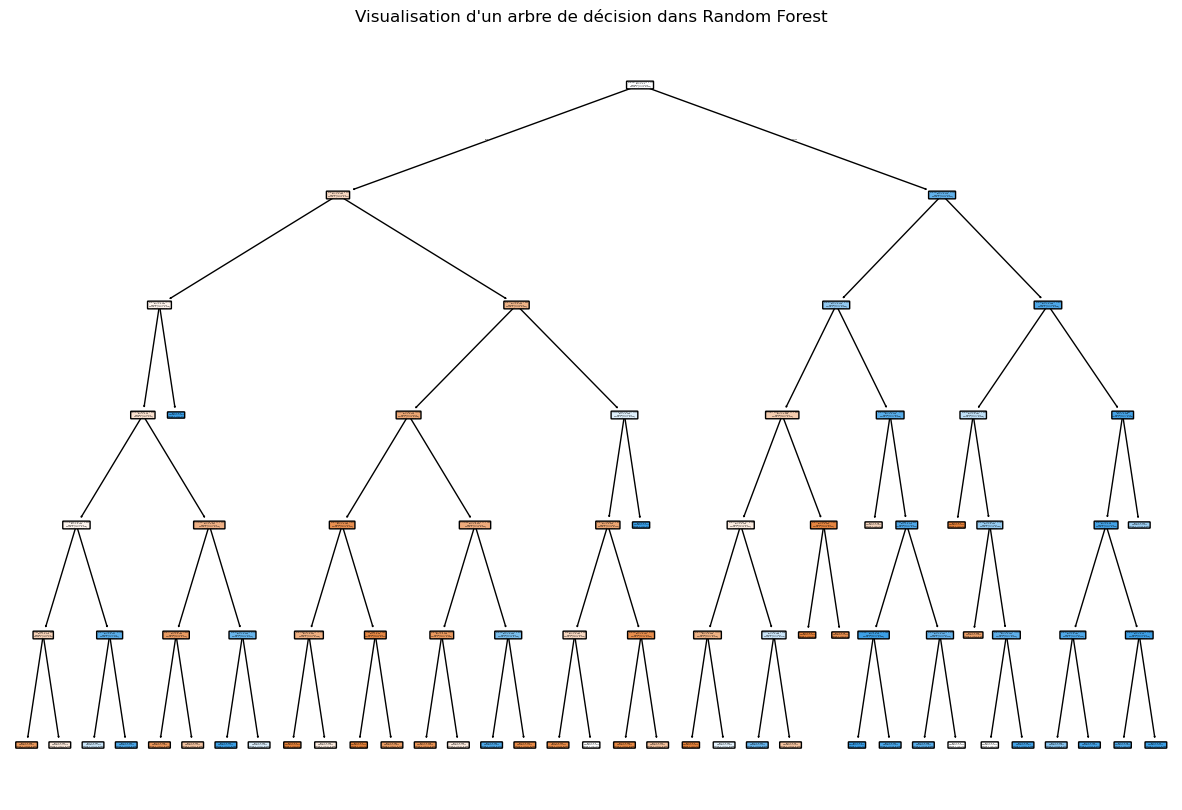

In [58]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Créer et entraîner le modèle Random Forest
model_rf_smote = RandomForestClassifier(n_estimators=100, criterion='gini', random_state=100, max_depth=6, min_samples_leaf=8)
model_rf_smote.fit(X_With_Smoteenn, Y_With_Smoteenn)

# Choisir un arbre spécifique de la forêt (par exemple, le premier arbre)
estimator = model_rf_smote.estimators_[0]  # Le premier arbre dans la forêt

# Visualisation de l'arbre
plt.figure(figsize=(15, 10))  # Ajuster la taille du graphique
plot_tree(
    estimator,                # Arbre individuel du modèle Random Forest
    feature_names=X_With_Smoteenn.columns,  # Noms des colonnes (features)
    class_names=["Classe 0", "Classe 1"],  # Noms des classes (adaptez selon vos classes)
    filled=True,             # Remplir les nœuds avec des couleurs
    rounded=True,            # Coins arrondis pour une meilleure lisibilité
    proportion=True          # Afficher les proportions au lieu des counts absolus
)
plt.title("Visualisation d'un arbre de décision dans Random Forest")
plt.show()

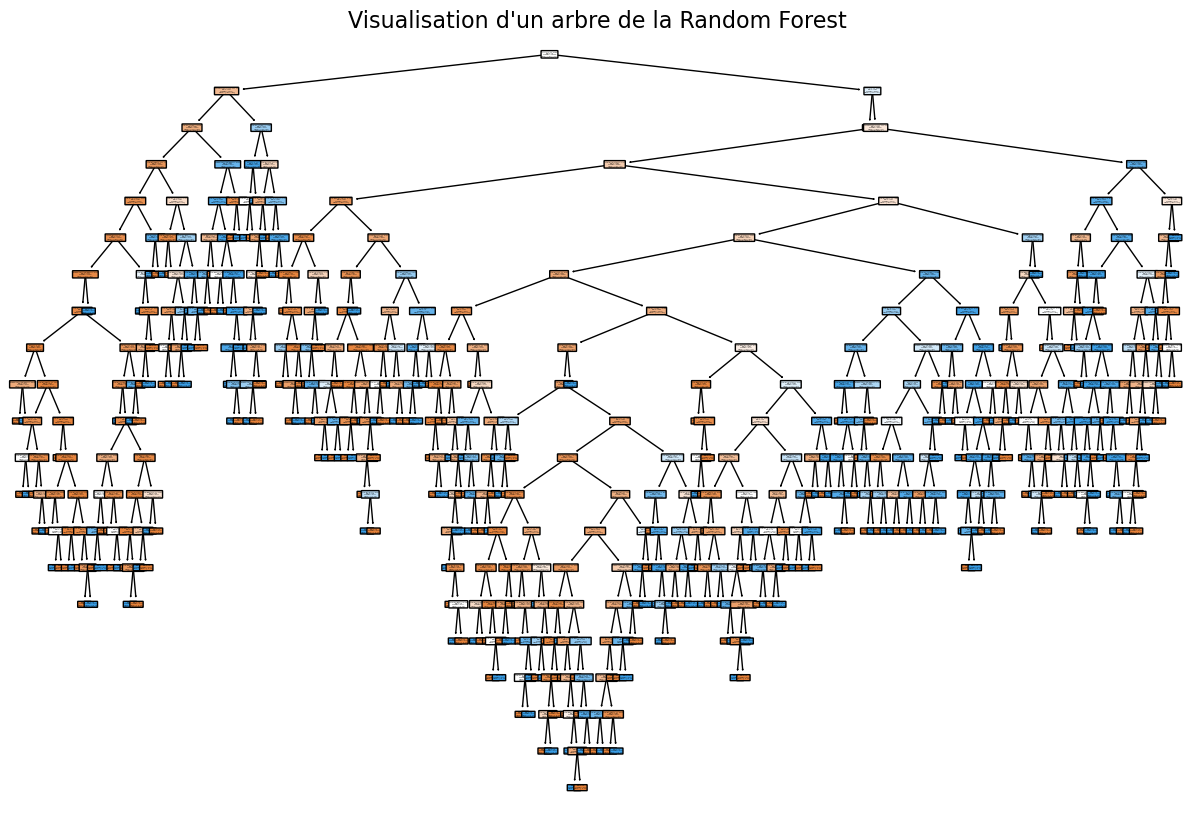

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Visualisation d'un arbre de décision individuel dans la Random Forest
plt.figure(figsize=(15, 10))  # Ajuster la taille du graphique
single_tree = rf_smoteenn.estimators_[0]  # Extraire un arbre individuel (le premier arbre)

plot_tree(
    single_tree,
    feature_names=X_train_With_Smoteenn.columns,  # Noms des colonnes (features)
    class_names=["Classe 0", "Classe 1"],  # Noms des classes (adaptez selon vos classes)
    filled=True,  # Remplir les nœuds avec des couleurs
    rounded=True,  # Coins arrondis pour une meilleure lisibilité
    proportion=True  # Afficher les proportions au lieu des counts absolus
)
plt.title("Visualisation d'un arbre de la Random Forest", fontsize=16)
plt.show()

Feature selection of Random forest

Feature Importances:
                   Feature  Importance
8         Total day charge    0.143661
6        Total day minutes    0.126357
18  Customer service calls    0.117714
3       International plan    0.081203
11        Total eve charge    0.069945
9        Total eve minutes    0.066082
16        Total intl calls    0.049063
17       Total intl charge    0.039790
15      Total intl minutes    0.038104
12     Total night minutes    0.036974
14      Total night charge    0.035980
7          Total day calls    0.031248
13       Total night calls    0.030950
10         Total eve calls    0.027997
1           Account length    0.027859
5    Number vmail messages    0.026648
0                    State    0.022395
4          Voice mail plan    0.019851
2                Area code    0.008177


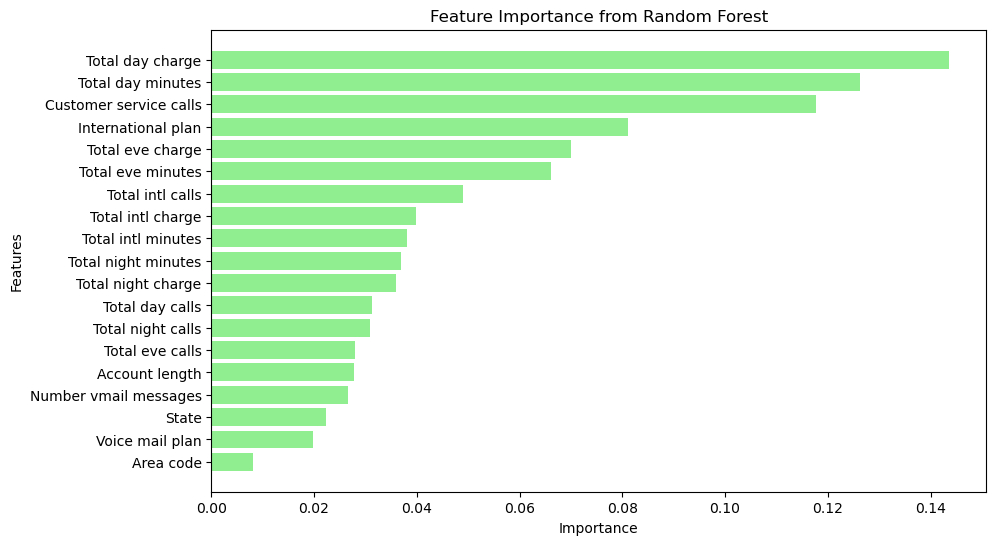

Random Forest Accuracy after Feature Selection: 0.9565


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


# Affichage de l'importance des features
feature_importances_rf = pd.DataFrame({
    'Feature': X_train_with_uppSampling.columns,
    'Importance': rf_uppSampling.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Feature Importances:")
print(feature_importances_rf)

# Visualisation des importances des features
plt.figure(figsize=(10, 6))
plt.barh(feature_importances_rf['Feature'], feature_importances_rf['Importance'], color='lightgreen')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance from Random Forest')
plt.gca().invert_yaxis()  # Invert the y-axis to show the highest importance at the top
plt.show()

# Sélection des features importantes (par exemple, importance > seuil de 0.01)
selected_features_rf = feature_importances_rf[feature_importances_rf['Importance'] > 0.01]['Feature']
X_train_selected_rf = X_train_with_uppSampling[selected_features_rf]
X_test_selected_rf = X_test_with_uppSampling[selected_features_rf]

# Réentraînement avec les features sélectionnées
rf_selected = RandomForestClassifier()
rf_selected.fit(X_train_selected_rf, Y_train_with_uppSampling)

# Prédictions sur les données de test avec features sélectionnées
Y_pred_selected_rf = rf_selected.predict(X_test_selected_rf)

# Calcul et affichage de l'exactitude
accuracy_selected_rf = accuracy_score(Y_test_with_uppSampling, Y_pred_selected_rf)
print(f"Random Forest Accuracy after Feature Selection: {accuracy_selected_rf:.4f}")


aaaaaa

In [ ]:
pip install lifelines


## Cox proportional hazard model

Colonnes disponibles : Index(['State', 'Account length', 'Area code', 'International plan',
       'Voice mail plan', 'Number vmail messages', 'Total day minutes',
       'Total day calls', 'Total day charge', 'Total eve minutes',
       'Total eve calls', 'Total eve charge', 'Total night minutes',
       'Total night calls', 'Total night charge', 'Total intl minutes',
       'Total intl calls', 'Total intl charge', 'Customer service calls',
       'Churn'],
      dtype='object')
Types de colonnes avant correction :
Account_length    float64
Churn               int64
dtype: object
Valeurs manquantes par colonne :
Account_length    0
Churn             0
dtype: int64
Aperçu des données après préparation :
   Account_length  Churn
0        0.400220      0
1       -0.905784      1
2        1.505299      1
3        0.249527      0
4       -1.307631      0


C:\Users\21624\anaconda3\Lib\site-packages\lifelines\fitters\coxph_fitter.py:1614: ConvergenceWarning: Newton-Raphson failed to converge sufficiently. Please see the following tips in the lifelines documentation: https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-convergence-in-the-cox-proportional-hazard-model
  warnings.warn(


<lifelines.CoxPHFitter: fitted with 3333 total observations, 2850 right-censored observations>
             duration col = 'Account_length'
                event col = 'Churn'
      baseline estimation = breslow
   number of observations = 3333
number of events observed = 483
   partial log-likelihood = -3374.94
         time fit was run = 2024-12-15 16:25:34 UTC

---
                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                               
State                  -0.00      1.00      0.05           -0.10            0.09                0.91                1.09
Area code               0.00      1.00      0.05           -0.09            0.09                0.91                1.09
International plan      0.06      1.06      0.04           -0.02            0.14                0.98                1.15
Voice mail plan        -0.04      0.96      0.16           -0.35            0.27                0.70                1.31
Number vmail messages   0.01      1.01      0.16           -0.30            0.33                0.74                1.38
Total day minutes      -2.00      0.14    146.15         -288.46          284.46                0.00           3.46e+123
Total day calls         0.00      1.00      0.05           -0.09            0.09                0.92                1.10
Total day charge        2.05      7.77    146.15         -284.41          288.51                0.00           1.98e+125
Total eve minutes       5.39    218.16     68.58         -129.04          139.81                0.00            5.22e+60
Total eve calls         0.00      1.00      0.05           -0.09            0.09                0.92                1.09
Total eve charge       -5.36      0.00     68.59         -139.79          129.07                0.00            1.13e+56
Total night minutes    -1.31      0.27     36.65          -73.14           70.52                0.00            4.23e+30
Total night calls       0.00      1.00      0.05           -0.09            0.09                0.92                1.10
Total night charge      1.33      3.76     36.65          -70.50           73.15                0.00            5.89e+31
Total intl minutes     -0.57      0.57     11.98          -24.04           22.90                0.00            8.85e+09
Total intl calls       -0.02      0.98      0.05           -0.11            0.08                0.90                1.08
Total intl charge       0.59      1.80     11.98          -22.88           24.06                0.00            2.82e+10
Customer service calls  0.06      1.06      0.04           -0.03            0.14                0.97                1.15

                        cmp to     z    p  -log2(p)
covariate                                          
State                     0.00 -0.08 0.94      0.09
Area code                 0.00  0.02 0.99      0.02
International plan        0.00  1.46 0.14      2.81
Voice mail plan           0.00 -0.27 0.79      0.34
Number vmail messages     0.00  0.09 0.93      0.11
Total day minutes         0.00 -0.01 0.99      0.02
Total day calls           0.00  0.07 0.95      0.08
Total day charge          0.00  0.01 0.99      0.02
Total eve minutes         0.00  0.08 0.94      0.09
Total eve calls           0.00  0.02 0.99      0.02
Total eve charge          0.00 -0.08 0.94      0.09
Total night minutes       0.00 -0.04 0.97      0.04
Total night calls         0.00  0.07 0.95      0.08
Total night charge        0.00  0.04 0.97      0.04
Total intl minutes        0.00 -0.05 0.96      0.06
Total intl calls          0.00 -0.35 0.73      0.46
Total intl charge         0.00  0.05 0.96      0.06
Customer service calls    0.00  1.24 0.22      2.22
---
Concordance = 0.78
Partial AIC = 6785.88
log-likelihood ratio test = 101.50 on 18 df
-log2(p) of ll-ratio test = 42.95

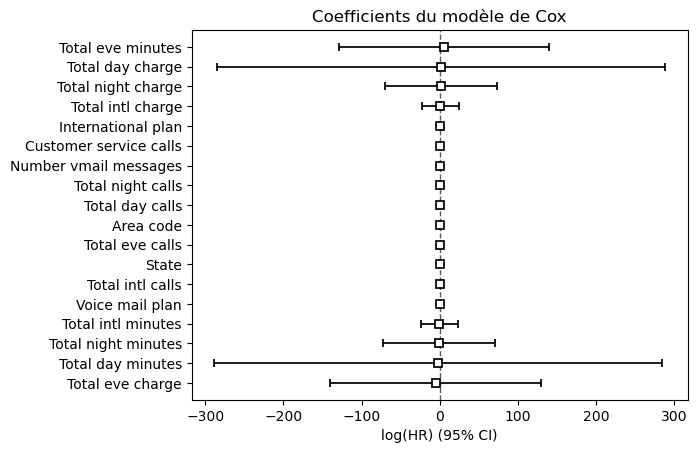

In [44]:

import pandas as pd
from lifelines import CoxPHFitter
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Charger votre DataFrame (remplacez df_combined par vos données chargées)
# Exemple : df_combined = pd.read_csv("votre_fichier.csv")

# Vérifiez les colonnes du DataFrame
print("Colonnes disponibles :", df_combined.columns)

# Renommer les colonnes si nécessaire
df_combined.rename(columns={'Account length': 'Account_length', 'Churn': 'Churn'}, inplace=True)

# Vérifiez les types de colonnes
print("Types de colonnes avant correction :")
print(df_combined[['Account_length', 'Churn']].dtypes)

# Convertir les colonnes en types appropriés
df_combined['Account_length'] = pd.to_numeric(df_combined['Account_length'], errors='coerce')
df_combined['Churn'] = df_combined['Churn'].astype(int)

# Vérifiez les valeurs manquantes
print("Valeurs manquantes par colonne :")
print(df_combined[['Account_length', 'Churn']].isnull().sum())

# Supprimer les lignes avec des valeurs manquantes (ou gérer autrement)
df_combined.dropna(subset=['Account_length', 'Churn'], inplace=True)

# Vérifiez un échantillon des données pour validation
print("Aperçu des données après préparation :")
print(df_combined[['Account_length', 'Churn']].head())

# Ajuster le modèle de Cox
cph = CoxPHFitter()

# Ajuster le modèle en spécifiant correctement les colonnes
cph.fit(df_combined, duration_col='Account_length', event_col='Churn')

# Résumé des résultats
cph.print_summary()

# Prédire les risques (hazards) sur les données
df_combined['predicted_risk'] = cph.predict_partial_hazard(df_combined)


# Visualisation des coefficients (facultatif)
cph.plot()
plt.title("Coefficients du modèle de Cox")
plt.show()


C:\Users\21624\anaconda3\Lib\site-packages\lifelines\fitters\coxph_fitter.py:1614: ConvergenceWarning: Newton-Raphson failed to converge sufficiently. Please see the following tips in the lifelines documentation: https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-convergence-in-the-cox-proportional-hazard-model
  warnings.warn(


<lifelines.CoxPHFitter: fitted with 3333 total observations, 2850 right-censored observations>
             duration col = 'Account_length'
                event col = 'Churn'
      baseline estimation = breslow
   number of observations = 3333
number of events observed = 483
   partial log-likelihood = -3372.95
         time fit was run = 2024-12-15 16:25:41 UTC

---
                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                               
State                   0.01      1.01      0.05           -0.09            0.10                0.91                1.11
Area code              -0.00      1.00      0.05           -0.09            0.09                0.91                1.09
International plan     -0.12      0.89      0.29           -0.68            0.45                0.50                1.57
Voice mail plan         0.06      1.06      0.22           -0.38            0.50                0.68                1.65
Number vmail messages  -0.02      0.98      0.16           -0.34            0.31                0.71                1.36
Total day minutes       2.06      7.88    146.31         -284.69          288.82                0.00           2.70e+125
Total day calls        -0.00      1.00      0.05           -0.10            0.09                0.91                1.09
Total day charge       -2.15      0.12    146.32         -288.93          284.63                0.00           4.11e+123
Total eve minutes      -8.71      0.00     72.40         -150.62          133.19                0.00            6.99e+57
Total eve calls        -0.00      1.00      0.05           -0.09            0.09                0.91                1.09
Total eve charge        8.67   5826.74     72.37         -133.17          150.51                0.00            2.31e+65
Total night minutes     2.93     18.77     37.18          -69.94           75.80                0.00            8.33e+32
Total night calls      -0.01      0.99      0.05           -0.10            0.09                0.90                1.09
Total night charge     -2.95      0.05     37.19          -75.84           69.93                0.00            2.35e+30
Total intl minutes      0.86      2.36     12.15          -22.95           24.67                0.00            5.17e+10
Total intl calls        0.03      1.03      0.08           -0.14            0.19                0.87                1.21
Total intl charge      -0.89      0.41     12.16          -24.73           22.95                0.00            9.24e+09
Customer service calls -0.10      0.91      0.25           -0.60            0.40                0.55                1.49
predicted_risk          2.63     13.92      4.25           -5.71           10.97                0.00            58242.55

                        cmp to     z    p  -log2(p)
covariate                                          
State                     0.00  0.11 0.91      0.13
Area code                 0.00 -0.02 0.98      0.03
International plan        0.00 -0.40 0.69      0.53
Voice mail plan           0.00  0.27 0.79      0.35
Number vmail messages     0.00 -0.10 0.92      0.12
Total day minutes         0.00  0.01 0.99      0.02
Total day calls           0.00 -0.10 0.92      0.13
Total day charge          0.00 -0.01 0.99      0.02
Total eve minutes         0.00 -0.12 0.90      0.15
Total eve calls           0.00 -0.02 0.99      0.02
Total eve charge          0.00  0.12 0.90      0.14
Total night minutes       0.00  0.08 0.94      0.09
Total night calls         0.00 -0.11 0.91      0.13
Total night charge        0.00 -0.08 0.94      0.09
Total intl minutes        0.00  0.07 0.94      0.08
Total intl calls          0.00  0.31 0.75      0.41
Total intl charge         0.00 -0.07 0.94      0.09
Customer service calls    0.00 -0.38 0.70      0.51
predicted_risk            0.00  0.62 0.54      

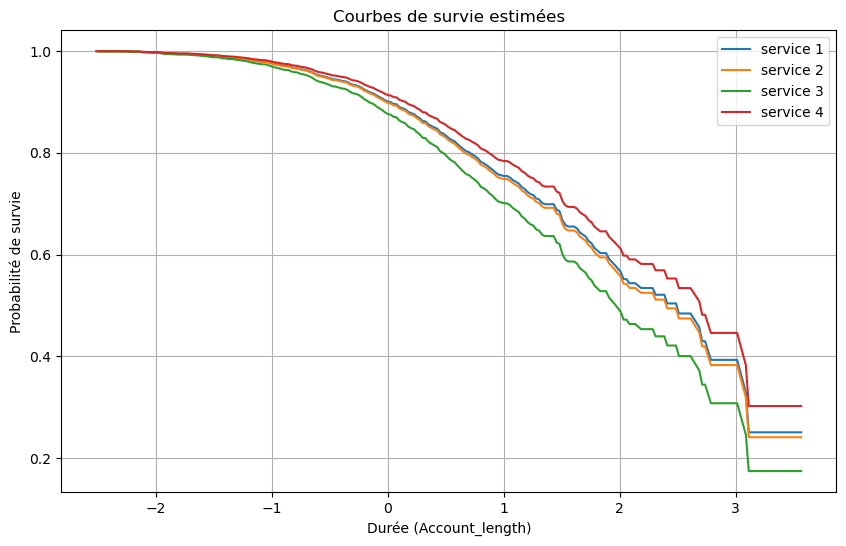

In [45]:
import pandas as pd
from lifelines import CoxPHFitter
import matplotlib.pyplot as plt

# Exemple d'ajustement (assurez-vous que df_combined est correctement préparé comme dans le code précédent)
cph = CoxPHFitter()
cph.fit(df_combined, duration_col='Account_length', event_col='Churn')

# Résumé des résultats
cph.print_summary()

# Estimation des courbes de survie pour un échantillon de données
sample_data = df_combined.iloc[:4]  # Prend les 4 premières lignes comme exemple
survival_predictions = cph.predict_survival_function(sample_data)

# Tracer les courbes de survie
plt.figure(figsize=(10, 6))
for idx, survival_curve in enumerate(survival_predictions.T.values):
    plt.plot(survival_predictions.index, survival_curve, label=f"service {idx+1}")

plt.title("Courbes de survie estimées")
plt.xlabel("Durée (Account_length)")
plt.ylabel("Probabilité de survie")
plt.legend()
plt.grid()
plt.show()


DSO2

## SVM : Support vector machine (linear) ( SMOTE + ENN )

Accuracy: 0.6306

Classification Report:

              precision    recall  f1-score   support

           0       0.63      0.69      0.66       579
           1       0.64      0.57      0.60       550

    accuracy                           0.63      1129
   macro avg       0.63      0.63      0.63      1129
weighted avg       0.63      0.63      0.63      1129


Confusion Matrix:

[[401 178]
 [239 311]]


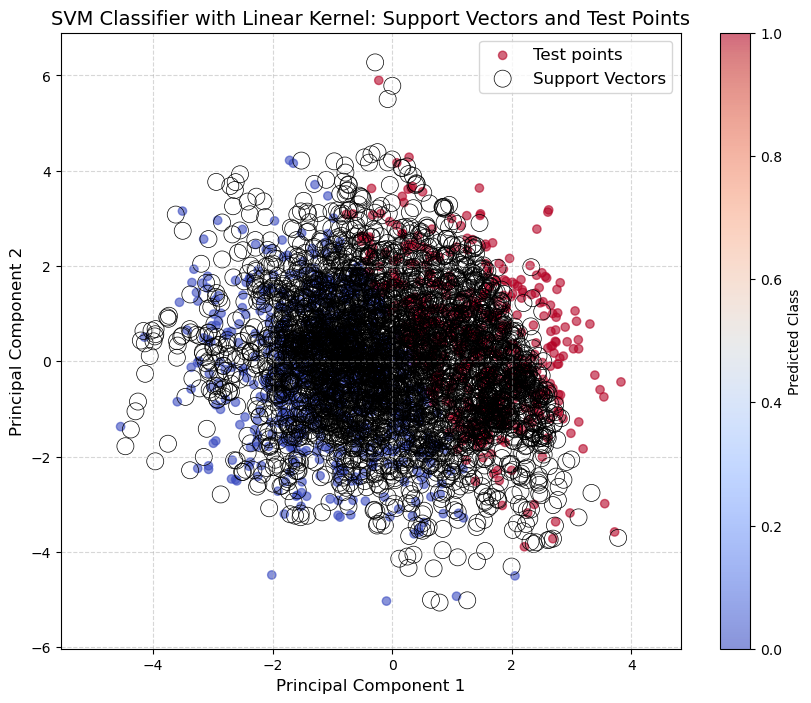

In [29]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC  # SVM classifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA



# Standardisation des données
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_With_Smoteenn)
X_test_scaled = scaler.transform(X_test_With_Smoteenn)

# Application de PCA pour réduire la dimension à 2
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Initialiser le modèle SVM avec un noyau linéaire
svm_model = SVC(kernel='linear', random_state=42)

# Entraîner le modèle SVM
svm_model.fit(X_train_pca, Y_train_With_Smoteenn)

# Prédire les résultats sur l'ensemble de test
y_pred = svm_model.predict(X_test_pca)

# Évaluation du modèle

# Précision
accuracy = accuracy_score(Y_test_With_Smoteenn, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Rapport de classification
print("\nClassification Report:\n")
print(classification_report(Y_test_With_Smoteenn, y_pred))

# Matrice de confusion
print("\nConfusion Matrix:\n")
print(confusion_matrix(Y_test_With_Smoteenn, y_pred))

# Visualisation des vecteurs de support et des points de test
plt.figure(figsize=(10, 8))

# Tracer les points de test, colorés en fonction des prédictions
scatter = plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_pred, cmap='coolwarm', marker='o', alpha=0.6, label='Test points')

# Tracer les vecteurs de support avec des bordures plus épaisses et un style distinct
plt.scatter(svm_model.support_vectors_[:, 0], svm_model.support_vectors_[:, 1], s=150, edgecolors='k', facecolors='none', label='Support Vectors', linewidth=0.5)

# Ajouter des titres et des étiquettes
plt.title('SVM Classifier with Linear Kernel: Support Vectors and Test Points', fontsize=14)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)

# Ajouter une légende
plt.legend(fontsize=12)

# Ajouter une grille pour faciliter la lecture
plt.grid(True, linestyle='--', alpha=0.5)

# Ajuster les limites des axes pour une meilleure vue d'ensemble
plt.xlim(min(X_test_pca[:, 0]) - 1, max(X_test_pca[:, 0]) + 1)
plt.ylim(min(X_test_pca[:, 1]) - 1, max(X_test_pca[:, 1]) + 1)

# Afficher le graphique
plt.colorbar(scatter, label='Predicted Class')
plt.show()


## SVM : Support vector machine (RBF) ( SMOTE + ENN )

Accuracy: 0.6873

Classification Report:

              precision    recall  f1-score   support

           0       0.64      0.87      0.74       579
           1       0.78      0.49      0.61       550

    accuracy                           0.69      1129
   macro avg       0.71      0.68      0.67      1129
weighted avg       0.71      0.69      0.68      1129


Confusion Matrix:

[[504  75]
 [278 272]]


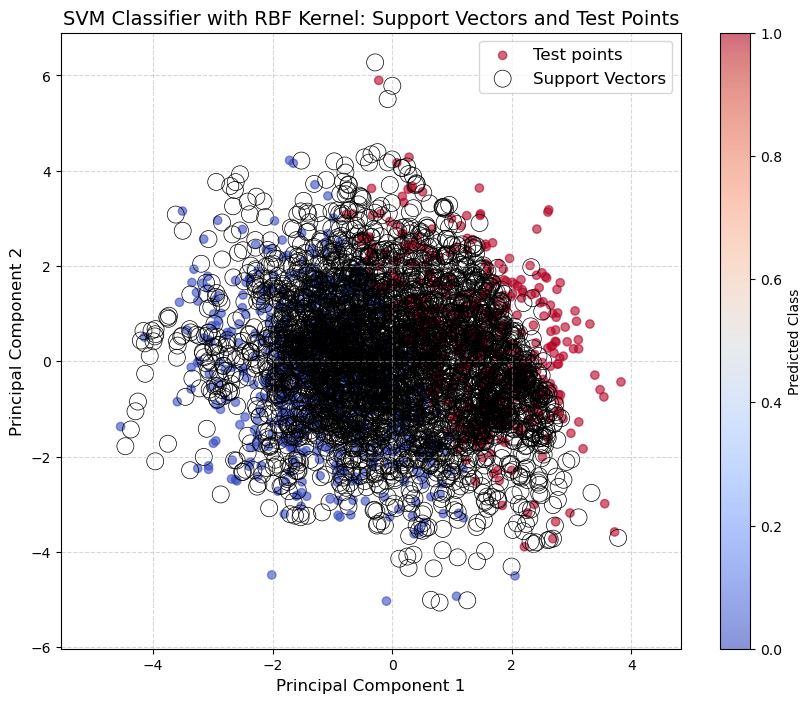

In [30]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC  # SVM classifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA



# Standardisation des données
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_With_Smoteenn)
X_test_scaled = scaler.transform(X_test_With_Smoteenn)

# Application de PCA pour réduire la dimension à 2
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Initialiser le modèle SVM avec un noyau linéaire
svm_model_rbf = SVC(kernel='rbf', random_state=42)

# Entraîner le modèle SVM
svm_model_rbf.fit(X_train_pca, Y_train_With_Smoteenn)

# Prédire les résultats sur l'ensemble de test
y_pred_svm_rbf = svm_model_rbf.predict(X_test_pca)

# Évaluation du modèle

# Précision
accuracy = accuracy_score(Y_test_With_Smoteenn, y_pred_svm_rbf)
print(f"Accuracy: {accuracy:.4f}")

# Rapport de classification
print("\nClassification Report:\n")
print(classification_report(Y_test_With_Smoteenn, y_pred_svm_rbf))

# Matrice de confusion
print("\nConfusion Matrix:\n")
print(confusion_matrix(Y_test_With_Smoteenn, y_pred_svm_rbf))

# Visualisation des vecteurs de support et des points de test
plt.figure(figsize=(10, 8))

# Tracer les points de test, colorés en fonction des prédictions
scatter = plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_pred, cmap='coolwarm', marker='o', alpha=0.6, label='Test points')

# Tracer les vecteurs de support avec des bordures plus épaisses et un style distinct
plt.scatter(svm_model.support_vectors_[:, 0], svm_model.support_vectors_[:, 1], s=150, edgecolors='k', facecolors='none', label='Support Vectors', linewidth=0.5)

# Ajouter des titres et des étiquettes
plt.title('SVM Classifier with RBF Kernel: Support Vectors and Test Points', fontsize=14)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)

# Ajouter une légende
plt.legend(fontsize=12)

# Ajouter une grille pour faciliter la lecture
plt.grid(True, linestyle='--', alpha=0.5)

# Ajuster les limites des axes pour une meilleure vue d'ensemble
plt.xlim(min(X_test_pca[:, 0]) - 1, max(X_test_pca[:, 0]) + 1)
plt.ylim(min(X_test_pca[:, 1]) - 1, max(X_test_pca[:, 1]) + 1)

# Afficher le graphique
plt.colorbar(scatter, label='Predicted Class')
plt.show()


## Logistic Regression (SMOTE+ ENN)

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Standardize the features for better performance with logistic regression
scaler = StandardScaler()

# Assuming df_resampled_SMOTEENN is already loaded and contains the data
X_With_Smoteenn = df_resampled_SMOTEENN.drop(columns=["Churn"])  # Features
Y_With_Smoteenn = df_resampled_SMOTEENN["Churn"]  # Target

# Split the data into training and testing sets
X_train_With_Smoteenn, X_test_With_Smoteenn, Y_train_With_Smoteenn, Y_test_With_Smoteenn = train_test_split(X_With_Smoteenn, Y_With_Smoteenn, test_size=0.2, random_state=42)

# Standardize the features
X_train_scaled = scaler.fit_transform(X_train_With_Smoteenn)
X_test_scaled = scaler.transform(X_test_With_Smoteenn)

# Initialize the Logistic Regression model
logistic_model = LogisticRegression(C=20, random_state=42)

# Fit the model on the training data
logistic_model.fit(X_train_scaled, Y_train_With_Smoteenn)

# Predict the results on the test set
y_pred = logistic_model.predict(X_test_scaled)

# Evaluate the model
accuracy = accuracy_score(Y_test_With_Smoteenn, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Classification Report
print("\nClassification Report:\n")
print(classification_report(Y_test_With_Smoteenn, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(Y_test_With_Smoteenn, y_pred))

Accuracy: 0.7679

Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.77      0.78       592
           1       0.75      0.77      0.76       537

    accuracy                           0.77      1129
   macro avg       0.77      0.77      0.77      1129
weighted avg       0.77      0.77      0.77      1129


Confusion Matrix:

[[454 138]
 [124 413]]


**Analyse globale :**


Impact du déséquilibre des classes :

Avant le up-sampling, le modèle était biaisé vers la classe majoritaire, comme le montre le faible rappel pour la classe minoritaire (0.22). Cela reflète une mauvaise performance pour les cas critiques (classe 1).
Après le Up-Sampling :

Le rappel pour la classe minoritaire a considérablement augmenté (de 0.22 à 0.78). Cela signifie que le modèle identifie beaucoup mieux les cas critiques, même si la précision (0.36) est légèrement affectée.
Équilibre entre les classes :

Avec le rééchantillonnage, la performance sur la classe minoritaire est considérablement améliorée, ce qui est crucial pour les problèmes où les erreurs sur la classe minoritaire sont coûteuses.




Le modèle après up-sampling est plus performant dans un contexte de déséquilibre des classes. Bien que l'accuracy globale ait diminué, l'amélioration du rappel pour la classe minoritaire en fait un meilleur modèle pour des applications pratiques.
Quand choisir quel modèle ?
Si capturer la classe minoritaire est prioritaire (par exemple, dans la détection de churn, où il est crucial de prévenir les pertes), utilisez le modèle après up-sampling.
Si les erreurs sur la classe majoritaire sont plus coûteuses, vous pourriez envisager de rester avec le modèle initial.


In [32]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Train the Gradient Boosting Classifier
gbm = GradientBoostingClassifier()
gbm.fit(X_train, Y_train)
# Make predictions
y_pred_gbm = gbm.predict(X_test)  # Predicted class labels (e.g., 0 or 1)
y_proba_gbm = gbm.predict_proba(X_test)[:, 1]  # Probability of churn (1)

# Evaluation Metrics
print(classification_report(Y_test, y_pred_gbm))
print("ROC-AUC Score:", roc_auc_score(Y_test, y_proba_gbm))

              precision    recall  f1-score   support

           0       0.96      0.99      0.98       571
           1       0.94      0.78      0.85        96

    accuracy                           0.96       667
   macro avg       0.95      0.89      0.91       667
weighted avg       0.96      0.96      0.96       667

ROC-AUC Score: 0.924547577349679


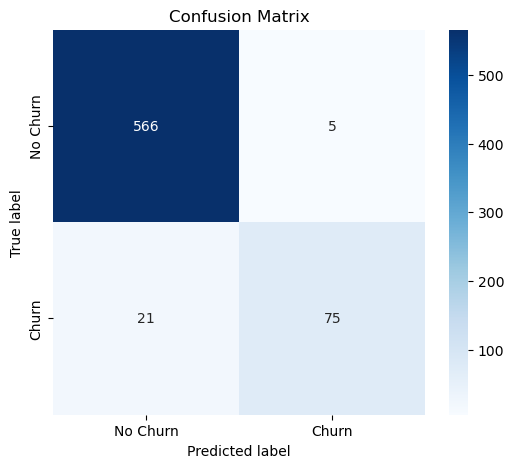

In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix
cm = confusion_matrix(Y_test, y_pred_gbm)

# Visualize the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
plt.title("Confusion Matrix")
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()


## Gradient Boost Model after up_sampling

In [25]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Initialize SMOTE
smote = SMOTE(sampling_strategy='minority', random_state=42)

# Resample the training set
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Check new class distribution
print("Class distribution after SMOTE:")
print(pd.Series(y_train_resampled).value_counts())


Class distribution after SMOTE:
Churn
0    2279
1    2279
Name: count, dtype: int64


C:\Users\21624\anaconda3\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
C:\Users\21624\anaconda3\Lib\site-packages\sklearn\utils\_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


In [26]:

# Initialize the model (e.g., Gradient Boosting Classifier)
gbm = GradientBoostingClassifier(random_state=42)

# Train the model
gbm.fit(X_train_resampled, y_train_resampled)


GradientBoostingClassifier(random_state=42)

In [27]:

# Predictions
y_pred_gbm2 = gbm.predict(X_test)
y_pred_proba_gbm2 = gbm.predict_proba(X_test)[:, 1]

# Evaluation Metrics
print("Classification Report:")
print(classification_report(y_test, y_pred_gbm2))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_gbm2):.2f}")


Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.95      0.96       571
           1       0.75      0.79      0.77        96

    accuracy                           0.93       667
   macro avg       0.85      0.87      0.86       667
weighted avg       0.93      0.93      0.93       667

ROC-AUC Score: 0.92


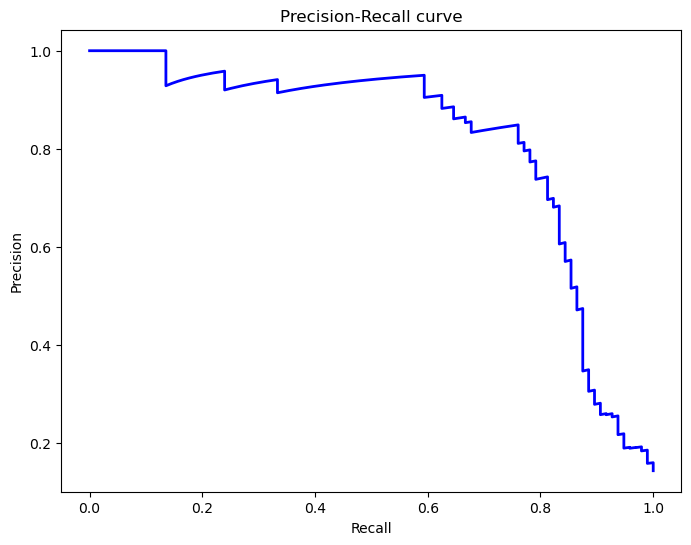

In [28]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba_gbm2)

# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall curve')
plt.show()


## XGboost( origonal data)


In [ ]:
!pip install xgboost

## XGboost with somte et enn

In [85]:
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
from collections import Counter

# Initialize the XGBoost classifier
xgb_model = xgb.XGBClassifier()

# Train the model with the training data
xgb_model.fit(X_train_With_Smoteenn, Y_train_With_Smoteenn)

# Predict on the test set
Y_pred_xgboost_With_Smoteenn = xgb_model.predict(X_test_With_Smoteenn)

# Calculate accuracy
accuracy = accuracy_score(Y_test_With_Smoteenn, Y_pred_xgboost_With_Smoteenn)
print(f"Accuracy: {accuracy:.4f}")



Accuracy: 0.9708


## Adaboost with Original data 

In [39]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split



# Initialize AdaBoostClassifier
adaboost_original = AdaBoostClassifier(n_estimators=50, random_state=42)  # n_estimators is the number of weak learners

# Train the AdaBoost model
adaboost_original.fit(X_train, Y_train)

# Make predictions
Y_pred_adaboost_With_original_data = adaboost_original.predict(X_test)


## Adaboost with SMOTE+ENN

In [40]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split



# Initialize AdaBoostClassifier
adaboost = AdaBoostClassifier(n_estimators=50, random_state=42)  # n_estimators is the number of weak learners

# Train the AdaBoost model
adaboost.fit(X_train_With_Smoteenn, Y_train_With_Smoteenn)

# Make predictions
Y_pred_adaboost_With_Smoteenn = adaboost.predict(X_test_With_Smoteenn)



## netwoks neurons

In [33]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report
import plotly.express as px
from sklearn.model_selection import train_test_split
from collections import Counter

# Fonction pour appliquer SMOTE et ENN sur une DataFrame complète
def apply_smote_and_enn_full_data(data, Churn):
    from imblearn.over_sampling import SMOTE
    from imblearn.under_sampling import EditedNearestNeighbours

    # Appliquer SMOTE pour suréchantillonner les classes minoritaires
    smote = SMOTE(sampling_strategy='auto', random_state=42)
    X_smote, Y_smote = smote.fit_resample(data.drop(columns=[Churn]), data[Churn])

    # Appliquer ENN pour réduire les exemples mal classés
    enn = EditedNearestNeighbours()
    X_smote_enn, Y_smote_enn = enn.fit_resample(X_smote, Y_smote)

    # Reconstruire la DataFrame complète avec caractéristiques et cible
    resampled_data = pd.concat([pd.DataFrame(X_smote_enn, columns=data.drop(columns=[Churn]).columns),
                                pd.Series(Y_smote_enn, name=Churn)], axis=1)

    # Vérifier la distribution des classes après SMOTE + ENN
    print("Class distribution after SMOTE + ENN:", Counter(Y_smote_enn))

    return resampled_data


# Utilisation de la fonction pour appliquer SMOTE et ENN sur vos données
target_column = "Churn"
df_resampled_SMOTEENN = apply_smote_and_enn_full_data(df_combined, target_column)

# Séparer à nouveau les features et la cible sur les données rééquilibrées
X_resampled5 = df_resampled_SMOTEENN.drop(columns=[target_column])  # Features
y_resampled5 = df_resampled_SMOTEENN[target_column]  # Target (Churn column)

# Split the resampled data into training and test sets
xr_train5, xr_test5, yr_train5, yr_test5 = train_test_split(
    X_resampled5, y_resampled5, test_size=0.2, random_state=42
)

# Define the Neural Network Model
model_nn5 = Sequential([
    Dense(128, input_dim=X_resampled5.shape[1], activation='relu'),  # Input layer (adjust input_dim based on your features)
    Dropout(0.2),  # Dropout for regularization
    Dense(64, activation='relu'),  # Hidden layer
    Dropout(0.2),
    Dense(1, activation='sigmoid')  # Output layer (binary classification)
])

# Compile the Model
model_nn5.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Train the Model
history5 = model_nn5.fit(xr_train5, yr_train5, validation_data=(xr_test5, yr_test5), epochs=50, batch_size=32, verbose=1)

# Evaluate the Model
loss5, accuracy5 = model_nn5.evaluate(xr_test5, yr_test5)
print(f"Test Loss: {loss5:.4f}, Test Accuracy: {accuracy5:.4f}")

# Predictions
yr_predict5 = (model_nn5.predict(xr_test5) > 0.5).astype("int32")

# Confusion Matrix and Classification Report
conf_matrix = confusion_matrix(yr_test5, yr_predict5)
class_report = classification_report(yr_test5, yr_predict5)

print("Confusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)

# Optional: Visualize the confusion matrix using Plotly
fig = px.imshow(conf_matrix, labels={'x': 'Predicted', 'y': 'True'}, color_continuous_scale='Blues',
                title='Confusion Matrix')
fig.show()


C:\Users\21624\anaconda3\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
C:\Users\21624\anaconda3\Lib\site-packages\sklearn\utils\_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
C:\Users\21624\anaconda3\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.

Class distribution after SMOTE + ENN: Counter({0: 2850, 1: 2794})


C:\Users\21624\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.6961 - loss: 0.5691 - val_accuracy: 0.8521 - val_loss: 0.3673
Epoch 2/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8345 - loss: 0.3740 - val_accuracy: 0.8601 - val_loss: 0.3198
Epoch 3/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8557 - loss: 0.3479 - val_accuracy: 0.8716 - val_loss: 0.3060
Epoch 4/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8697 - loss: 0.3224 - val_accuracy: 0.8840 - val_loss: 0.2836
Epoch 5/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8733 - loss: 0.2923 - val_accuracy: 0.8866 - val_loss: 0.2683
Epoch 6/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8910 - loss: 0.2718 - val_accuracy: 0.8911 - val_loss: 0.2573
Epoch 7/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8898 - loss: 0.2721 - val_accuracy: 0.8973 - val_loss: 0.2424
Epoch 8/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8942 - loss: 0.2516 - val_accuracy: 

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9584 - loss: 0.1048
Test Loss: 0.1212, Test Accuracy: 0.9548
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Confusion Matrix:
[[557  35]
 [ 16 521]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.94      0.96       592
           1       0.94      0.97      0.95       537

    accuracy                           0.95      1129
   macro avg       0.95      0.96      0.95      1129
weighted avg       0.96      0.95      0.95      1129



In [34]:
def plot_confusion_matrix(y_true, y_pred, labels=None, title="Confusion Matrix", show_percent=False, color_scale="Blues"):
    """
    Affiche une matrice de confusion avec Plotly.

    Paramètres :
    - y_true : les valeurs réelles.
    - y_pred : les valeurs prédites.
    - labels : les labels pour les classes (ex: ["No", "Yes"]).
    - title : titre de la matrice de confusion.
    - show_percent : affiche les pourcentages au lieu des valeurs brutes.
    - color_scale : le thème de couleurs (ex: 'Blues', 'Viridis', etc.).
    """
    # Calculer la matrice de confusion
    cm = confusion_matrix(y_true, y_pred)

    # Si show_percent est activé, convertir les valeurs en pourcentages
    if show_percent:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
        cm_text = np.round(cm, 2).astype(str) + " %"  # Formater les valeurs en pourcentage
    else:
        cm_text = cm  # Utiliser les valeurs brutes

    # Définir des labels si non spécifiés
    if labels is None:
        labels = ["Class 0", "Class 1"]

    # Visualiser la matrice de confusion
    fig_cm = px.imshow(
        cm,
        text_auto=cm_text,  # Afficher les valeurs dans les cases
        x=labels,
        y=labels,
        color_continuous_scale=color_scale,
        title=title,
        labels=dict(x="Predicted", y="Actual", color="Count")
    )
    fig_cm.update_layout(title_x=0.5)
    fig_cm.show()

In [35]:
# Training vs. Test Accuracy and Loss
fig_loss_acc5 = px.line(
    x=range(1, len(history5.history['loss']) + 1),
    y=[history5.history['loss'], history5.history['val_loss'], history5.history['accuracy'], history5.history['val_accuracy']],
    labels={"x": "Epoch", "y": "Metric Value"},
    title="Training vs Validation Loss and Accuracy - Neural Network"
)
fig_loss_acc5.update_traces(mode='lines+markers')
fig_loss_acc5.update_layout(
    legend=dict(
        title="Metrics",
        itemsizing='constant',
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    )
)
fig_loss_acc5.show()

# Classification Report
print(classification_report(yr_test5, yr_predict5))

              precision    recall  f1-score   support

           0       0.97      0.94      0.96       592
           1       0.94      0.97      0.95       537

    accuracy                           0.95      1129
   macro avg       0.95      0.96      0.95      1129
weighted avg       0.96      0.95      0.95      1129



## Shap

In [90]:
#pip install numpy==1.24.3

^C
Note: you may need to restart the kernel to use updated packages.


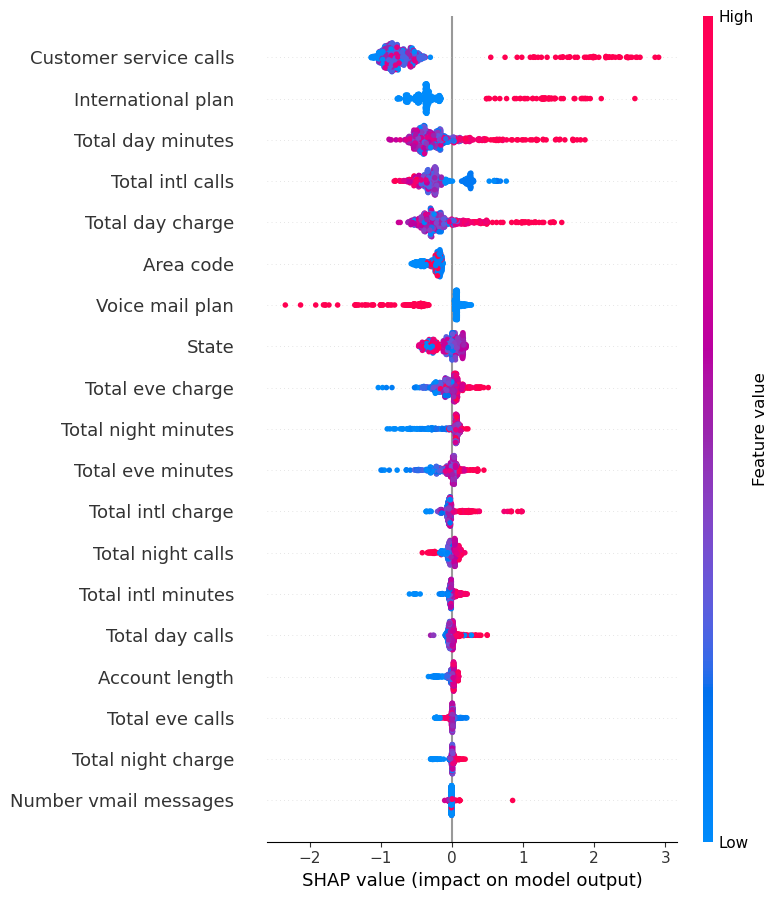

In [29]:
import shap
import matplotlib.pyplot as plt

# Initialize SHAP TreeExplainer with the trained gbm model
explainer = shap.TreeExplainer(gbm)

# Compute SHAP values for the test dataset
shap_values = explainer.shap_values(X_test)

# Summary Plot (Global Explanation)
shap.summary_plot(shap_values, X_test)

# Force Plot (Local Explanation for a single prediction)
# Select an example from the test data
sample_index = 0  # Change this to analyze a different example
shap.force_plot(
    explainer.expected_value,
    shap_values[sample_index],
    X_test.iloc[sample_index],
)


Context:
*SHAP Value: The horizontal axis represents the SHAP values, which show the impact of each feature on the model's prediction. Positive SHAP values push the model's prediction towards class 1 (Churn), while negative SHAP values push it towards class 0 (No Churn).

*Feature Value: The color represents the feature value, with red indicating high values and blue indicating low values.

Interpretation
*Customer service calls and Total day charge have high impacts on the model. For exemple, higher values for these features seem to increase the likelihood of churn (shown by positive SHAP values).

*International plan and Voice mail plan seem to influence the model less, as they show SHAP values closer to 0, meaning they don’t have as much impact on the model's predictions.

*Area code and State are less impactful compared to other features, which is indicated by the smaller spread of SHAP values.

In [31]:
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import make_scorer, roc_auc_score, average_precision_score, precision_score, recall_score, f1_score, accuracy_score
from imblearn.over_sampling import SMOTE
import numpy as np

# Initialize SMOTE
smote = SMOTE(sampling_strategy='minority', random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, Y)

# Initialize the Gradient Boosting Classifier with the best parameters
gbm = GradientBoostingClassifier(
    learning_rate=0.2,
    max_depth=5,
    n_estimators=200,
    random_state=42
)

# Define scoring metrics
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='binary'),
    'recall': make_scorer(recall_score, average='binary'),
    'f1': make_scorer(f1_score, average='binary'),
    'roc_auc': make_scorer(roc_auc_score, needs_proba=True),
    'pr_auc': make_scorer(average_precision_score, needs_proba=True)
}

# Use StratifiedKFold for balanced splits
stratified_kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Perform cross-validation
cv_results = cross_validate(gbm, X_resampled, y_resampled, cv=stratified_kfold, scoring=scoring, return_train_score=False)

# Print average and standard deviation for each metric
print("Cross-Validation Results:")
for metric in scoring.keys():
    mean_score = np.mean(cv_results[f'test_{metric}'])
    std_dev_score = np.std(cv_results[f'test_{metric}'])
    print(f"Mean {metric.capitalize()}: {mean_score:.4f}")
    print(f"Std Dev {metric.capitalize()}: {std_dev_score:.4f}")

    

C:\Users\21624\anaconda3\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
C:\Users\21624\anaconda3\Lib\site-packages\sklearn\utils\_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
C:\Users\21624\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters wi

C:\Users\21624\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\21624\anaconda3\Lib\site-packages\sklearn\metrics\_scorer.py", line 140, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "C:\Users\21624\anaconda3\Lib\site-packages\sklearn\metrics\_scorer.py", line 388, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\21624\anaconda3\Lib\site-packages\sklearn\utils\_param_validation.py", line 194, in wrapper
    params = func_sig.bind(*args, **kwargs)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\21624\anaconda3\Lib\inspect.py", line 3212, in bind
    return self._bind(args, kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\User

Cross-Validation Results:
Mean Accuracy: 0.9723
Std Dev Accuracy: 0.0075
Mean Precision: 0.9815
Std Dev Precision: 0.0081
Mean Recall: 0.9628
Std Dev Recall: 0.0123
Mean F1: 0.9720
Std Dev F1: 0.0076
Mean Roc_auc: nan
Std Dev Roc_auc: nan
Mean Pr_auc: nan
Std Dev Pr_auc: nan


C:\Users\21624\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\21624\anaconda3\Lib\site-packages\sklearn\metrics\_scorer.py", line 140, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "C:\Users\21624\anaconda3\Lib\site-packages\sklearn\metrics\_scorer.py", line 388, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\21624\anaconda3\Lib\site-packages\sklearn\utils\_param_validation.py", line 194, in wrapper
    params = func_sig.bind(*args, **kwargs)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\21624\anaconda3\Lib\inspect.py", line 3212, in bind
    return self._bind(args, kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\User

KNN

In [59]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X = df_combined.drop(columns=['Churn'])
y = df_combined['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train the KNN model
knn = KNeighborsClassifier(n_neighbors=5)  # Start with k=5
knn.fit(X_train_scaled, y_train)

# Predictions
y_pred = knn.predict(X_test_scaled)
y_pred_prob = knn.predict_proba(X_test_scaled)[:, 1]

# Evaluation
print("Classification Report for KNN Classifier:")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_prob):.2f}")

Classification Report for KNN Classifier:
              precision    recall  f1-score   support

           0       0.90      0.98      0.93       571
           1       0.70      0.33      0.45        96

    accuracy                           0.88       667
   macro avg       0.80      0.65      0.69       667
weighted avg       0.87      0.88      0.86       667

ROC-AUC Score: 0.82


In [60]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Initialize GridSearchCV
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='roc_auc')
grid_search.fit(X_train_scaled, y_train)

# Best parameters
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best ROC-AUC Score: {grid_search.best_score_:.2f}")


Best Parameters: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
Best ROC-AUC Score: 0.84


In [61]:
knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(X_train_scaled, y_train)

# Predictions
y_pred = knn.predict(X_test_scaled)
y_pred_prob = knn.predict_proba(X_test_scaled)[:, 1]

# Evaluation
print("Classification Report for KNN Classifier:")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_prob):.2f}")

Classification Report for KNN Classifier:
              precision    recall  f1-score   support

           0       0.89      0.99      0.94       571
           1       0.84      0.28      0.42        96

    accuracy                           0.89       667
   macro avg       0.87      0.64      0.68       667
weighted avg       0.88      0.89      0.86       667

ROC-AUC Score: 0.86


Classification Report for Optimized KNN Classifier:
              precision    recall  f1-score   support

           0       0.88      0.99      0.94       571
           1       0.85      0.23      0.36        96

    accuracy                           0.88       667
   macro avg       0.87      0.61      0.65       667
weighted avg       0.88      0.88      0.85       667

ROC-AUC Score: 0.83


C:\Users\21624\AppData\Local\Temp\ipykernel_5552\3282446526.py:23: UserWarning:

color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.



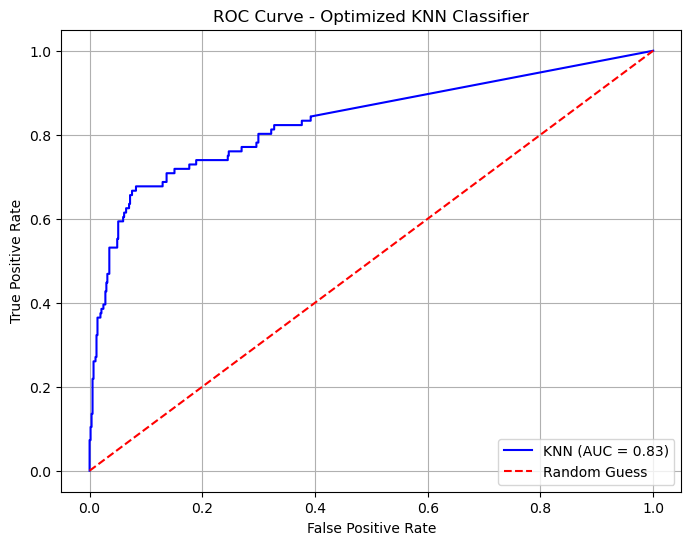

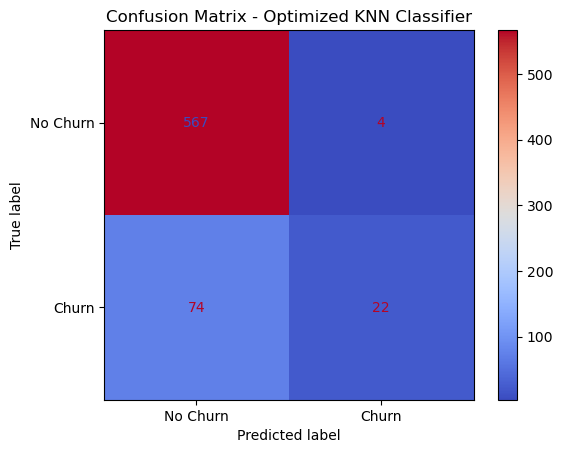

In [62]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, ConfusionMatrixDisplay, classification_report

# Retrain the KNN model with the best parameters
knn_best = KNeighborsClassifier(n_neighbors=9, weights='distance', metric='manhattan')
knn_best.fit(X_train_scaled, y_train)

# Predictions
y_pred_best = knn_best.predict(X_test_scaled)
y_pred_prob_best = knn_best.predict_proba(X_test_scaled)[:, 1]

# Classification Report
print("Classification Report for Optimized KNN Classifier:")
print(classification_report(y_test, y_pred_best))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_prob_best):.2f}")

# Generate ROC Curve Data
fpr, tpr, _ = roc_curve(y_test, y_pred_prob_best)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"KNN (AUC = {roc_auc_score(y_test, y_pred_prob_best):.2f})", color="blue")
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess", color="red")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Optimized KNN Classifier")
plt.legend(loc="lower right")
plt.grid()
plt.show()

# Plot Confusion Matrix
ConfusionMatrixDisplay.from_estimator(knn_best, X_test_scaled, y_test, display_labels=['No Churn', 'Churn'], cmap='coolwarm')
plt.title("Confusion Matrix - Optimized KNN Classifier")
plt.show()


KNN with SMOTE

C:\Users\21624\anaconda3\Lib\site-packages\sklearn\base.py:474: FutureWarning:

`BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.

C:\Users\21624\anaconda3\Lib\site-packages\sklearn\utils\_tags.py:354: FutureWarning:

The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.



Classification Report for KNN with SMOTE:
              precision    recall  f1-score   support

           0       0.95      0.81      0.87       571
           1       0.40      0.74      0.52        96

    accuracy                           0.80       667
   macro avg       0.67      0.78      0.70       667
weighted avg       0.87      0.80      0.82       667

ROC-AUC Score: 0.83


C:\Users\21624\AppData\Local\Temp\ipykernel_5552\3521202359.py:40: UserWarning:

color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.



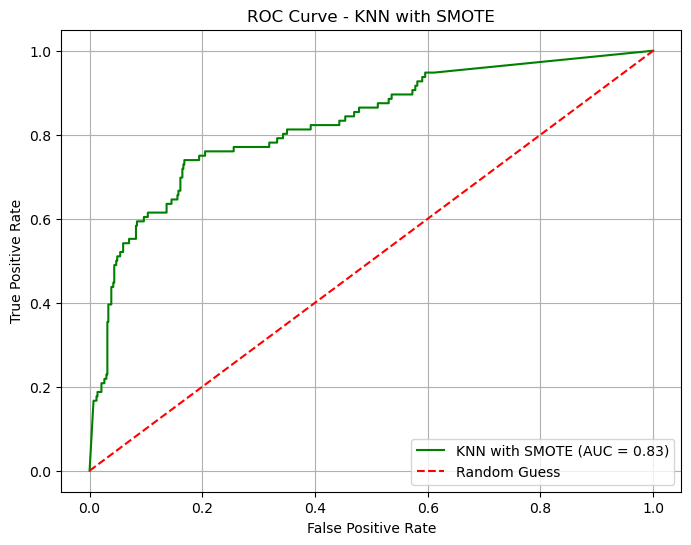

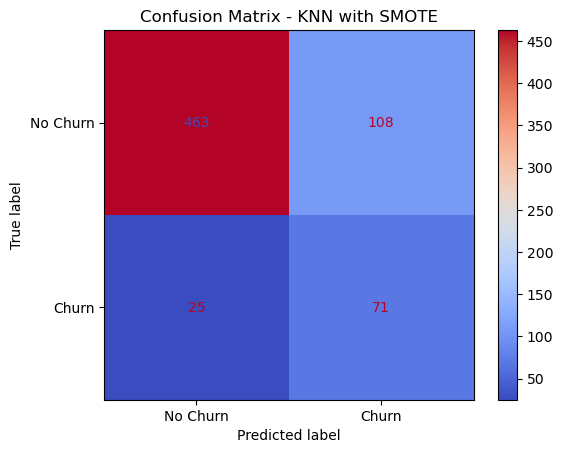

In [63]:
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X = df_combined.drop(columns=['Churn'])
y = df_combined['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply SMOTE to the training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

# Train KNN with the SMOTE-balanced data
knn_smote = KNeighborsClassifier(n_neighbors=9, weights='distance', metric='manhattan')
knn_smote.fit(X_train_scaled, y_train_smote)

# Predictions
y_pred_smote = knn_smote.predict(X_test_scaled)
y_pred_prob_smote = knn_smote.predict_proba(X_test_scaled)[:, 1]

# Evaluation
print("Classification Report for KNN with SMOTE:")
print(classification_report(y_test, y_pred_smote))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_prob_smote):.2f}")

# ROC Curve
fpr_smote, tpr_smote, _ = roc_curve(y_test, y_pred_prob_smote)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_smote, tpr_smote, label=f"KNN with SMOTE (AUC = {roc_auc_score(y_test, y_pred_prob_smote):.2f})", color="green")
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess", color="red")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - KNN with SMOTE")
plt.legend(loc="lower right")
plt.grid()
plt.show()

# Plot Confusion Matrix
ConfusionMatrixDisplay.from_estimator(knn_smote, X_test_scaled, y_test, display_labels=['No Churn', 'Churn'], cmap='coolwarm')
plt.title("Confusion Matrix - KNN with SMOTE")
plt.show()


### KNN with Up-Sampling

Classification Report for KNN with Up-Sampling:
              precision    recall  f1-score   support

           0       0.93      0.82      0.87       571
           1       0.38      0.66      0.48        96

    accuracy                           0.80       667
   macro avg       0.66      0.74      0.68       667
weighted avg       0.85      0.80      0.82       667

ROC-AUC Score: 0.80


C:\Users\21624\AppData\Local\Temp\ipykernel_5552\2554752287.py:54: UserWarning:

color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.



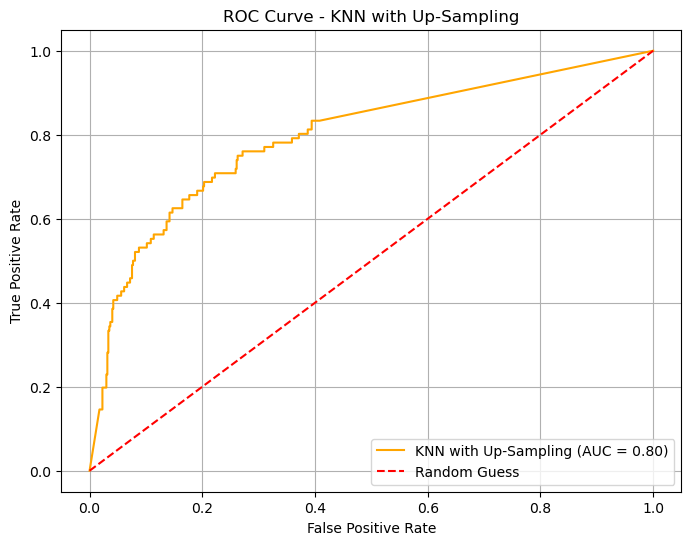

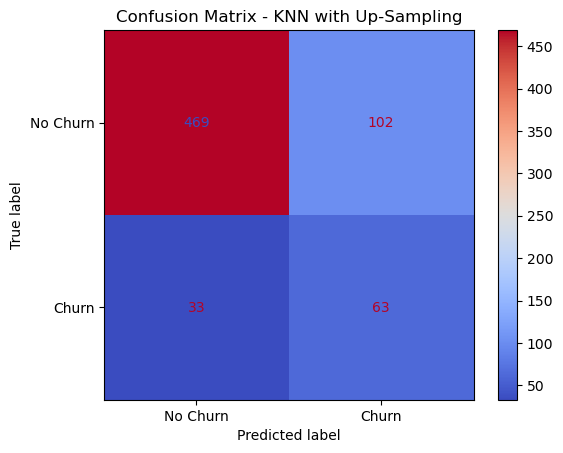

In [65]:
from sklearn.utils import resample
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X = df_combined.drop(columns=['Churn'])
y = df_combined['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Combine the features and target for up-sampling
train_data = X_train.copy()
train_data['Churn'] = y_train

# Separate majority and minority classes
majority = train_data[train_data['Churn'] == 0]
minority = train_data[train_data['Churn'] == 1]

# Up-sample the minority class
minority_upsampled = resample(minority, replace=True, n_samples=len(majority), random_state=42)

# Combine majority and upsampled minority class
upsampled_data = pd.concat([majority, minority_upsampled])

# Separate features and target
X_train_upsampled = upsampled_data.drop(columns=['Churn'])
y_train_upsampled = upsampled_data['Churn']

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_upsampled)
X_test_scaled = scaler.transform(X_test)

# Train KNN with the up-sampled data
knn_upsampled = KNeighborsClassifier(n_neighbors=9, weights='distance', metric='manhattan')
knn_upsampled.fit(X_train_scaled, y_train_upsampled)

# Predictions
y_pred_upsampled = knn_upsampled.predict(X_test_scaled)
y_pred_prob_upsampled = knn_upsampled.predict_proba(X_test_scaled)[:, 1]

# Evaluation
print("Classification Report for KNN with Up-Sampling:")
print(classification_report(y_test, y_pred_upsampled))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_prob_upsampled):.2f}")

# ROC Curve
fpr_upsampled, tpr_upsampled, _ = roc_curve(y_test, y_pred_prob_upsampled)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_upsampled, tpr_upsampled, label=f"KNN with Up-Sampling (AUC = {roc_auc_score(y_test, y_pred_prob_upsampled):.2f})", color="orange")
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess", color="red")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - KNN with Up-Sampling")
plt.legend(loc="lower right")
plt.grid()
plt.show()

# Plot Confusion Matrix
ConfusionMatrixDisplay.from_estimator(knn_upsampled, X_test_scaled, y_test, display_labels=['No Churn', 'Churn'], cmap='coolwarm')
plt.title("Confusion Matrix - KNN with Up-Sampling")
plt.show()


## part 5 : test et evaluation

## decision tree (original data)


## **DSO 1**

****without upsampling *******
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       571
           1       0.68      0.74      0.71        96

    accuracy                           0.91       667
   macro avg       0.82      0.84      0.83       667
weighted avg       0.92      0.91      0.91       667

Confusion Matrix:


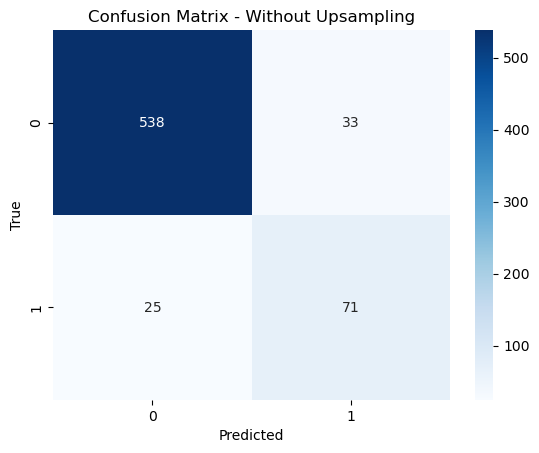

****with upsampling *******
              precision    recall  f1-score   support

           0       0.96      0.95      0.95       581
           1       0.67      0.72      0.69        86

    accuracy                           0.92       667
   macro avg       0.81      0.83      0.82       667
weighted avg       0.92      0.92      0.92       667

Confusion Matrix:


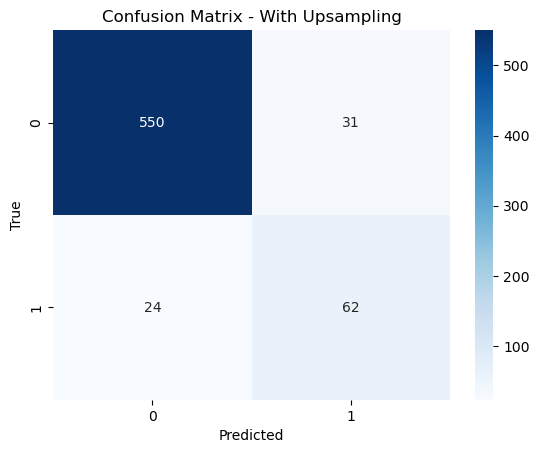

****with SMOTE+ENN *******
              precision    recall  f1-score   support

           0       0.55      0.52      0.53       592
           1       0.50      0.52      0.51       537

    accuracy                           0.52      1129
   macro avg       0.52      0.52      0.52      1129
weighted avg       0.52      0.52      0.52      1129

Confusion Matrix:


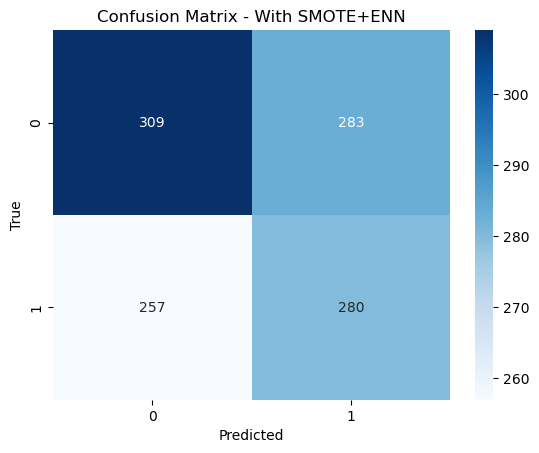

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# For original predictions
print("****without upsampling *******")
print(classification_report(Y_test, Y_pred_original, labels=[0, 1]))
print("Confusion Matrix:")
cm_original = confusion_matrix(Y_test, Y_pred_original)
sns.heatmap(cm_original, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1], yticklabels=[0, 1])
plt.title("Confusion Matrix - Without Upsampling")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# For predictions with upsampling
print("****with upsampling *******")
print(classification_report(Y_test_with_uppSampling, Y_pred_uppSampling, labels=[0, 1]))
print("Confusion Matrix:")
cm_upsampling = confusion_matrix(Y_test_with_uppSampling, Y_pred_uppSampling)
sns.heatmap(cm_upsampling, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1], yticklabels=[0, 1])
plt.title("Confusion Matrix - With Upsampling")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# For predictions with SMOTE+ENN
print("****with SMOTE+ENN *******")
print(classification_report(Y_test_With_Smoteenn, Y_pred_smoteenn, labels=[0, 1]))
print("Confusion Matrix:")
cm_smoteenn = confusion_matrix(Y_test_With_Smoteenn, Y_pred_smoteenn)
sns.heatmap(cm_smoteenn, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1], yticklabels=[0, 1])
plt.title("Confusion Matrix - With SMOTE+ENN")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


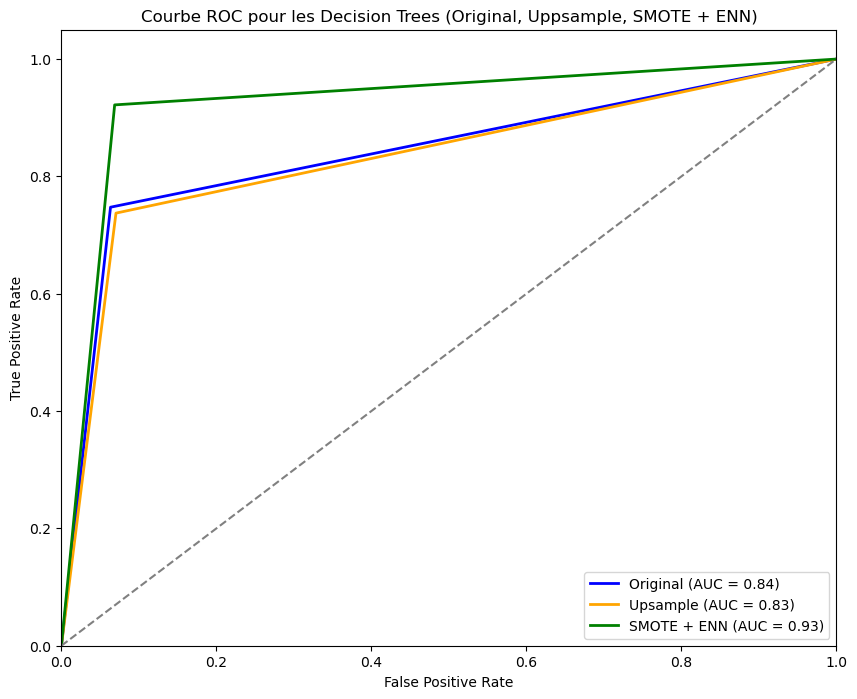

In [74]:

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize


# Calculer les courbes ROC
fpr_original, tpr_original, _ = roc_curve(Y_test, Y_pred_original)  # Utilisez les probabilités
fpr_upsample, tpr_upsample, _ = roc_curve(Y_test_with_uppSampling , Y_pred_uppSampling)  # Utilisez les probabilités
fpr_smote, tpr_smote, _ = roc_curve(Y_test_With_Smoteenn, Y_pred_smoteenn)  # Utilisez les probabilités

  
# Calculer l'AUC
roc_auc_original = auc(fpr_original, tpr_original)
roc_auc_upsample = auc(fpr_upsample, tpr_upsample)
roc_auc_smote = auc(fpr_smote, tpr_smote)


# Tracer les courbes ROC
plt.figure(figsize=(10, 8))
plt.plot(fpr_original, tpr_original, color='blue', lw=2, label='Original (AUC = %0.2f)' % roc_auc_original)
plt.plot(fpr_upsample, tpr_upsample, color='orange', lw=2, label='Upsample (AUC = %0.2f)' % roc_auc_upsample)
plt.plot(fpr_smote, tpr_smote, color='green', lw=2, label='SMOTE + ENN (AUC = %0.2f)' % roc_auc_smote)


# Ajouter les détails de la courbe ROC
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC pour les Decision Trees (Original, Uppsample, SMOTE + ENN)')
plt.legend(loc='lower right')
plt.show()


In [48]:

# Calculer la courbe ROC
fpr_cox, tpr_cox, thresholds = roc_curve(df_combined['Churn'], df_combined['predicted_risk'])
roc_auc_cox = auc(fpr_cox, tpr_cox,)

# Afficher la courbe ROC
plt.figure()
plt.plot(fpr_cox, tpr_cox, color='darkorange', lw=2, label=f'Courbe ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (TPR)')
plt.title('Courbe ROC pour le modèle de Cox')
plt.legend(loc="lower right")
plt.show()


NameError: name 'roc_auc' is not defined

<Figure size 640x480 with 0 Axes>

## random forest 

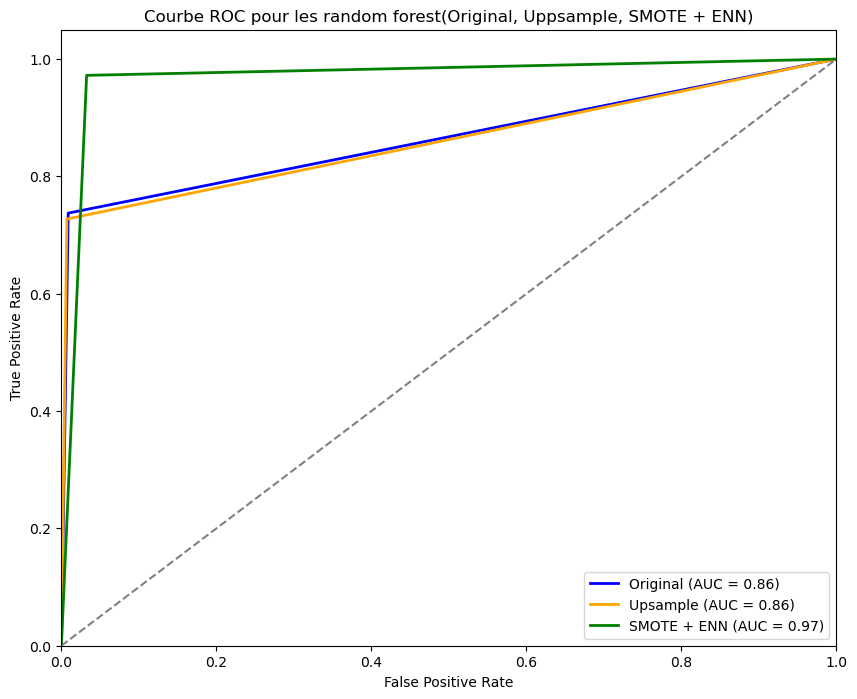

In [76]:

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize


# Calculer les courbes ROC
fpr_original_rf, tpr_original_rf, _ = roc_curve(Y_test, Y_pred_rf_original)  # Utilisez les probabilités
fpr_upsample_rf, tpr_upsample_rf, _ = roc_curve(Y_test_with_uppSampling , Y_pred_rf_uppSampling)  # Utilisez les probabilités
fpr_smote_rf, tpr_smote_rf, _ = roc_curve(Y_test_With_Smoteenn, Y_pred_rf_smoteenn)  # Utilisez les probabilités

  
# Calculer l'AUC
roc_auc_original_rf = auc(fpr_original_rf, tpr_original_rf)
roc_auc_upsample_rf = auc(fpr_upsample_rf, tpr_upsample_rf)
roc_auc_smote_rf = auc(fpr_smote_rf, tpr_smote_rf)


# Tracer les courbes ROC
plt.figure(figsize=(10, 8))
plt.plot(fpr_original_rf, tpr_original_rf, color='blue', lw=2, label='Original (AUC = %0.2f)' % roc_auc_original_rf)
plt.plot(fpr_upsample_rf, tpr_upsample_rf, color='orange', lw=2, label='Upsample (AUC = %0.2f)' % roc_auc_upsample_rf)
plt.plot(fpr_smote_rf, tpr_smote_rf, color='green', lw=2, label='SMOTE + ENN (AUC = %0.2f)' % roc_auc_smote_rf)


# Ajouter les détails de la courbe ROC
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC pour les random forest(Original, Uppsample, SMOTE + ENN)')
plt.legend(loc='lower right')
plt.show()


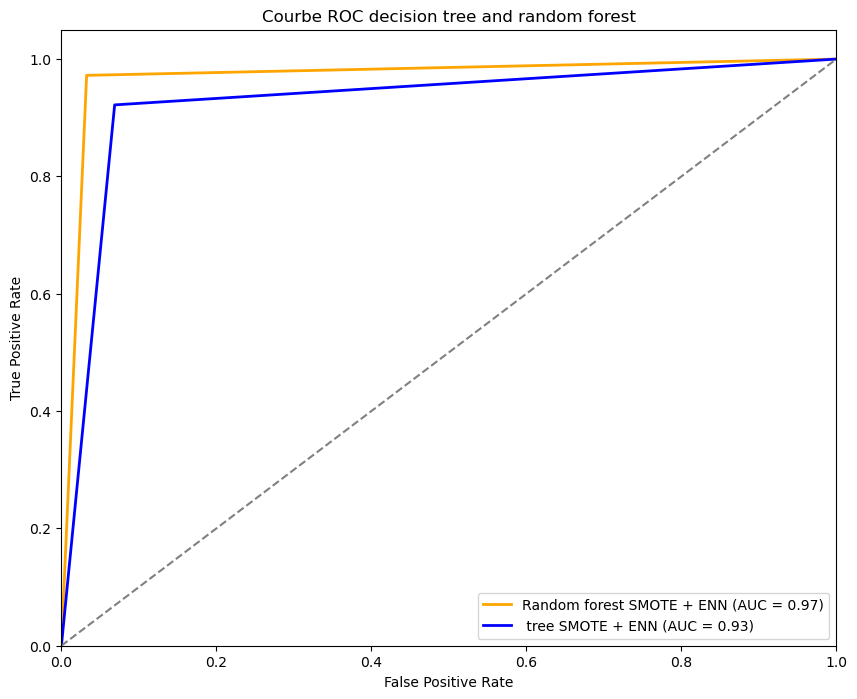

In [77]:

# Tracer les courbes ROC
plt.figure(figsize=(10, 8))

plt.plot(fpr_smote_rf, tpr_smote_rf, color='orange', lw=2, label='Random forest SMOTE + ENN (AUC = %0.2f)' % roc_auc_smote_rf)
plt.plot(fpr_smote, tpr_smote, color='blue', lw=2, label=' tree SMOTE + ENN (AUC = %0.2f)' % roc_auc_smote)
#plt.plot(fpr_cox, tpr_cox, color='darkorange', lw=2, label=f'Courbe ROC Cox hazard model (AUC = {roc_auc:.2f})')

# Ajouter les détails de la courbe ROC
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC decision tree and random forest')
plt.legend(loc='lower right')
plt.show()


The ROC curves suggest that both the Decision Tree and Random Forest models are effective at distinguishing between classes, with an AUC of 0.96. These results indicate that the application of SMOTE + ENN improves the model performance significantly, especially when compared to a random classifier.

dso 2 

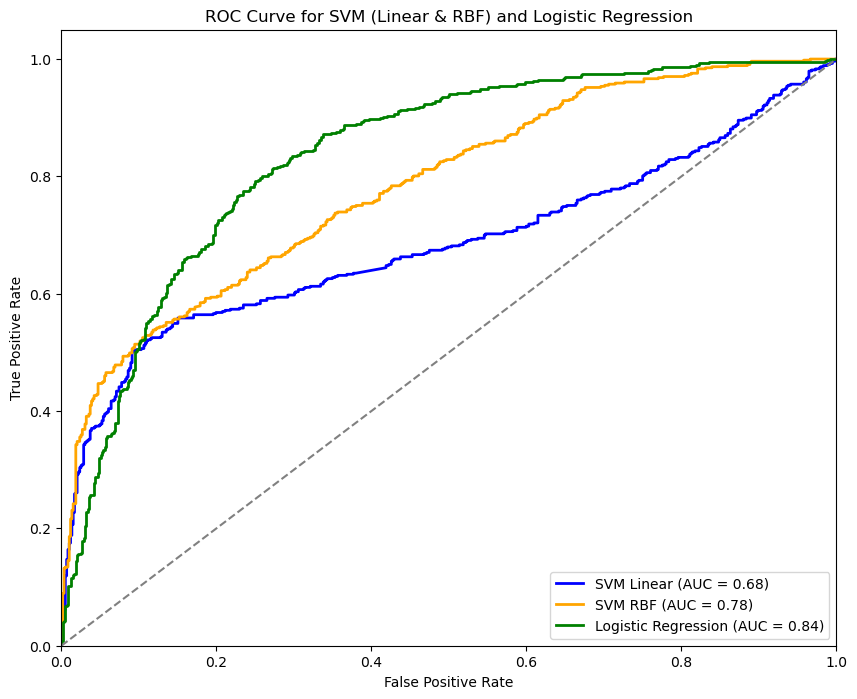

In [78]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Standardizing the data
scaler = StandardScaler()
X_With_Smoteenn = df_resampled_SMOTEENN.drop(columns=["Churn"])  # Features
Y_With_Smoteenn = df_resampled_SMOTEENN["Churn"]  # Target

X_train_With_Smoteenn, X_test_With_Smoteenn, Y_train_With_Smoteenn, Y_test_With_Smoteenn = train_test_split(X_With_Smoteenn, Y_With_Smoteenn, test_size=0.2, random_state=42)

X_train_scaled = scaler.fit_transform(X_train_With_Smoteenn)
X_test_scaled = scaler.transform(X_test_With_Smoteenn)

# Apply PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# SVM with Linear Kernel
svm_model_linear = SVC(kernel='linear', random_state=42, probability=True)  # Enable probability for ROC curve
svm_model_linear.fit(X_train_pca, Y_train_With_Smoteenn)
y_pred_proba_linear = svm_model_linear.predict_proba(X_test_pca)[:, 1]

# SVM with RBF Kernel
svm_model_rbf = SVC(kernel='rbf', random_state=42, probability=True)  # Enable probability for ROC curve
svm_model_rbf.fit(X_train_pca, Y_train_With_Smoteenn)
y_pred_proba_rbf = svm_model_rbf.predict_proba(X_test_pca)[:, 1]

# Logistic Regression
logistic_model = LogisticRegression(C=20, random_state=42)
logistic_model.fit(X_train_scaled, Y_train_With_Smoteenn)
y_pred_proba_logistic = logistic_model.predict_proba(X_test_scaled)[:, 1]

# Compute ROC and AUC for each model
fpr_linear, tpr_linear, _ = roc_curve(Y_test_With_Smoteenn, y_pred_proba_linear)
fpr_rbf, tpr_rbf, _ = roc_curve(Y_test_With_Smoteenn, y_pred_proba_rbf)
fpr_logistic, tpr_logistic, _ = roc_curve(Y_test_With_Smoteenn, y_pred_proba_logistic)

roc_auc_linear = auc(fpr_linear, tpr_linear)
roc_auc_rbf = auc(fpr_rbf, tpr_rbf)
roc_auc_logistic = auc(fpr_logistic, tpr_logistic)

# Plot ROC curves
plt.figure(figsize=(10, 8))
plt.plot(fpr_linear, tpr_linear, color='blue', lw=2, label='SVM Linear (AUC = %0.2f)' % roc_auc_linear)
plt.plot(fpr_rbf, tpr_rbf, color='orange', lw=2, label='SVM RBF (AUC = %0.2f)' % roc_auc_rbf)
plt.plot(fpr_logistic, tpr_logistic, color='green', lw=2, label='Logistic Regression (AUC = %0.2f)' % roc_auc_logistic)

# Add diagonal line for random classifier
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

# Set plot parameters
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for SVM (Linear & RBF) and Logistic Regression')
plt.legend(loc='lower right')

# Show the plot
plt.show()


### Adaboost

dso 3

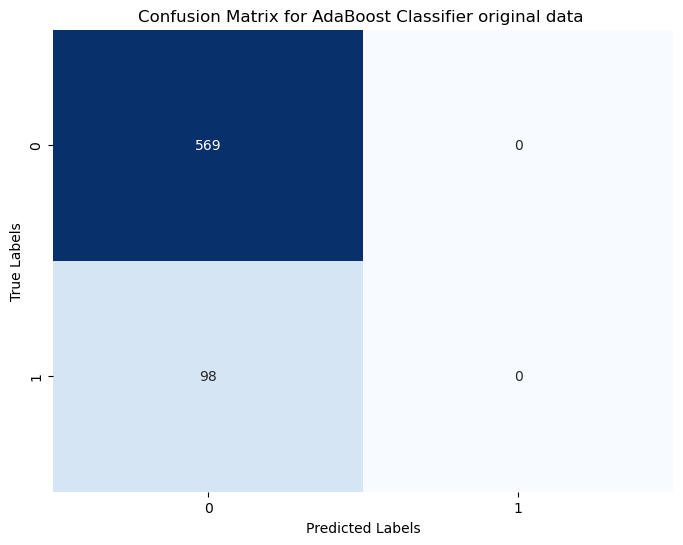

Accuracy: 0.8530734632683659
Classification Report:
               precision    recall  f1-score   support

           0       0.85      1.00      0.92       569
           1       0.00      0.00      0.00        98

    accuracy                           0.85       667
   macro avg       0.43      0.50      0.46       667
weighted avg       0.73      0.85      0.79       667



C:\Users\21624\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

C:\Users\21624\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

C:\Users\21624\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



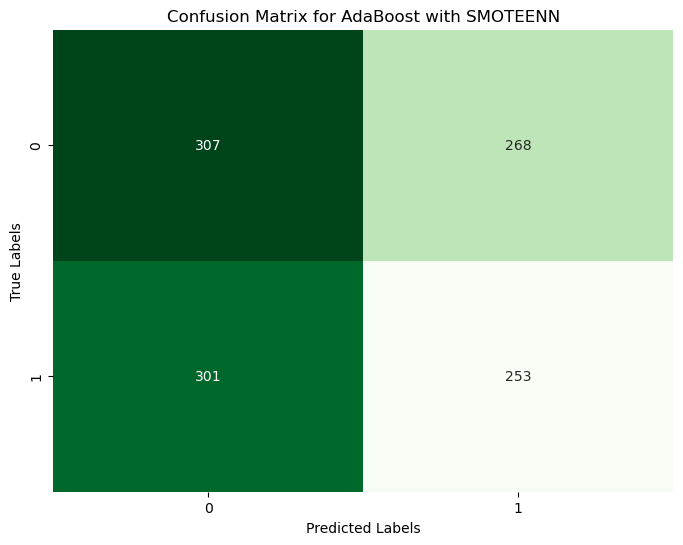

Accuracy: 0.49601417183348095
Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.53      0.52       575
           1       0.49      0.46      0.47       554

    accuracy                           0.50      1129
   macro avg       0.50      0.50      0.49      1129
weighted avg       0.50      0.50      0.50      1129



In [133]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute confusion matrix
cm = confusion_matrix(Y_test, Y_pred_adaboost_With_original_data)

# Plot confusion matrix with Seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix for AdaBoost Classifier original data ")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()


# Evaluate the model
accuracy = accuracy_score(Y_test, Y_pred_adaboost_With_original_data)
print("Accuracy:", accuracy)

# Detailed classification report
print("Classification Report:\n", classification_report(Y_test, Y_pred_adaboost_With_original_data))



import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm_with_smoteenn = confusion_matrix(Y_test_With_Smoteenn, Y_pred_adaboost_With_Smoteenn)

# Plot confusion matrix with Seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_with_smoteenn, annot=True, fmt="d", cmap="Greens", cbar=False)
plt.title("Confusion Matrix for AdaBoost with SMOTEENN")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()


# Evaluate the model
accuracy = accuracy_score(Y_test_With_Smoteenn, Y_pred_adaboost_With_Smoteenn)
print("Accuracy:", accuracy)

# Detailed classification report
print("Classification Report:\n", classification_report(Y_test_With_Smoteenn, Y_pred_adaboost_With_Smoteenn))



## GBM evaluation 

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.95      0.96       571
           1       0.75      0.79      0.77        96

    accuracy                           0.93       667
   macro avg       0.85      0.87      0.86       667
weighted avg       0.93      0.93      0.93       667

ROC-AUC Score: 0.92


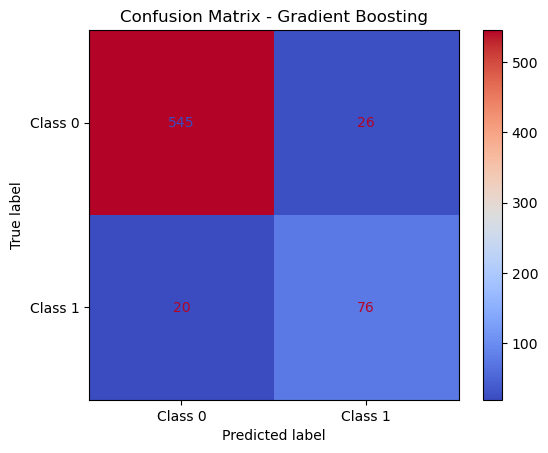

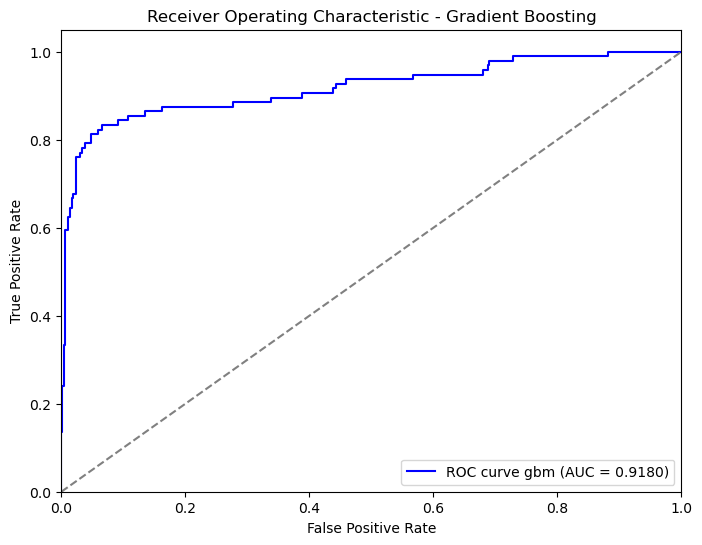

In [87]:
# Evaluation Metrics
print("Classification Report:")
print(classification_report(y_test, y_pred_gbm2))

# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_pred_proba_gbm2)
print(f"ROC-AUC Score: {roc_auc:.2f}")

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_gbm2)
ConfusionMatrixDisplay(conf_matrix, display_labels=['Class 0', 'Class 1']).plot(cmap='coolwarm')
plt.title("Confusion Matrix - Gradient Boosting")
plt.show()

# ROC Curve
fpr_gbm, tpr_gbm, thresholds = roc_curve(y_test, y_pred_proba_gbm2)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_gbm, tpr_gbm, color='blue', label=f'ROC curve gbm (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line (random classifier)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Gradient Boosting')
plt.legend(loc='lower right')
plt.show()

### Roc curve for Adaboost with and without SMOTEENN

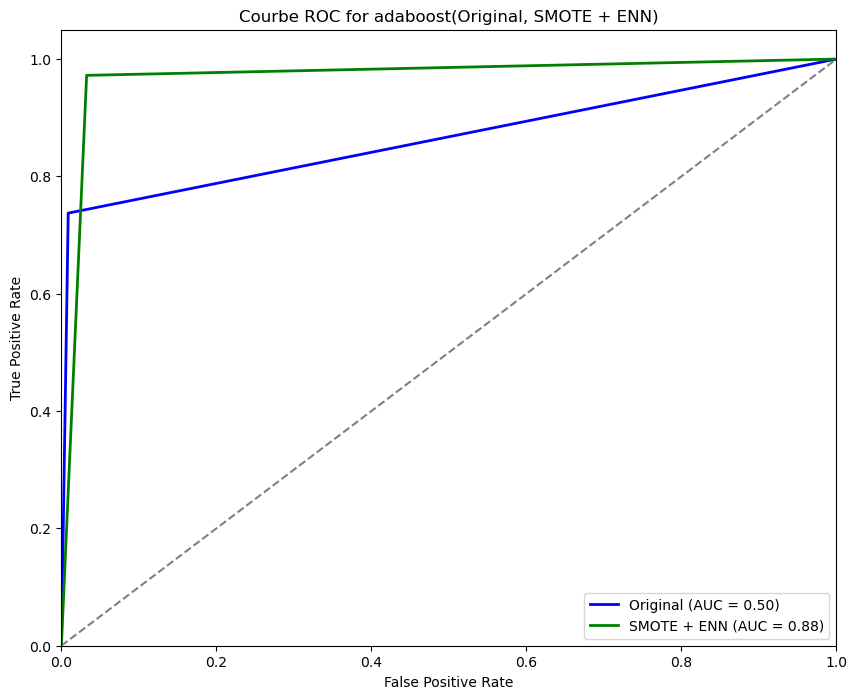

In [79]:

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize


# Calculer les courbes ROC
fpr_original_adaboost, tpr_original__adaboost, _ = roc_curve(Y_test, Y_pred_adaboost_With_original_data)  # Utilisez les probabilités

fpr_smote_adaboost, tpr_smote_adaboost, _ = roc_curve(Y_test_With_Smoteenn, Y_pred_adaboost_With_Smoteenn)  # Utilisez les probabilités

  
# Calculer l'AUC
roc_auc_original_adaboost= auc(fpr_original_adaboost, tpr_original__adaboost)

roc_auc_smote__adaboost = auc(fpr_smote_adaboost, tpr_smote_adaboost)


# Tracer les courbes ROC
plt.figure(figsize=(10, 8))
plt.plot(fpr_original_rf, tpr_original_rf, color='blue', lw=2, label='Original (AUC = %0.2f)' % roc_auc_original_adaboost)

plt.plot(fpr_smote_rf, tpr_smote_rf, color='green', lw=2, label='SMOTE + ENN (AUC = %0.2f)' % roc_auc_smote__adaboost)


# Ajouter les détails de la courbe ROC
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC for adaboost(Original, SMOTE + ENN)')
plt.legend(loc='lower right')
plt.show()


## Roc curve for XGBOOST

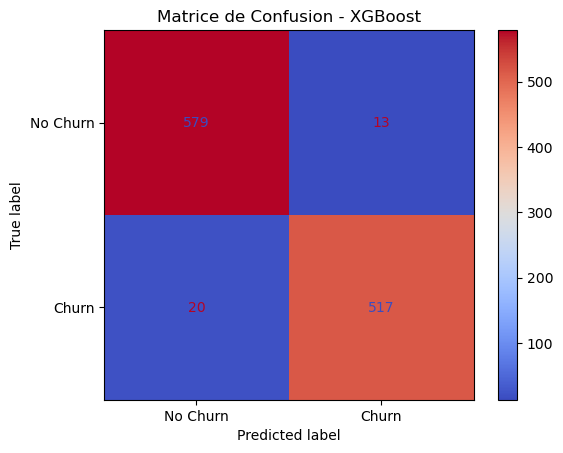

Distribution des prédictions sur Y_test: Counter({0: 599, 1: 530})
AUC: 0.9704


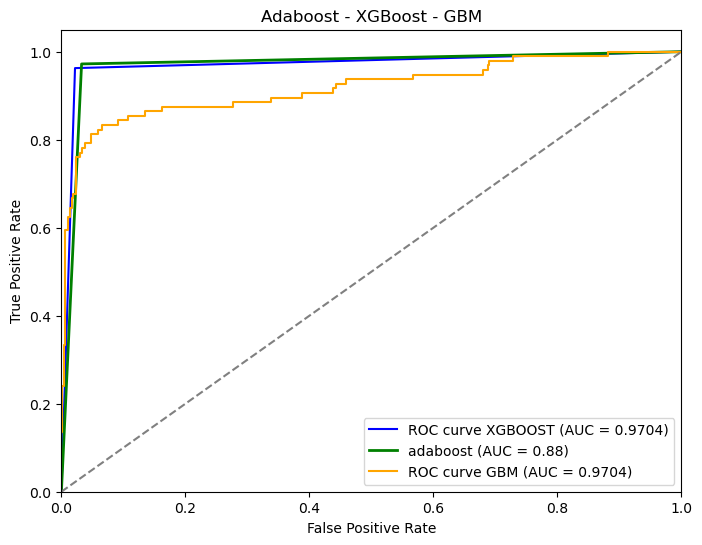

In [88]:

# Affichage de la matrice de confusion
conf_matrix = confusion_matrix(Y_test_With_Smoteenn, Y_pred_xgboost_With_Smoteenn)
ConfusionMatrixDisplay(conf_matrix, display_labels=['No Churn', 'Churn']).plot(cmap='coolwarm')
plt.title("Matrice de Confusion - XGBoost")
plt.show()

# Affichage de la distribution des prédictions
print("Distribution des prédictions sur Y_test:", Counter(Y_pred_xgboost_With_Smoteenn))

# Get predicted probabilities for the positive class (Churn)
Y_pred_proba = xgb_model.predict_proba(X_test_With_Smoteenn)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(Y_test_With_Smoteenn, Y_pred_xgboost_With_Smoteenn)

# Calculate AUC (Area Under the Curve)
roc_auc = roc_auc_score(Y_test_With_Smoteenn, Y_pred_xgboost_With_Smoteenn)
print(f"AUC: {roc_auc:.4f}")

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve XGBOOST (AUC = {roc_auc:.4f})')
plt.plot(fpr_smote_rf, tpr_smote_rf, color='green', lw=2, label='adaboost (AUC = %0.2f)' % roc_auc_smote__adaboost)
plt.plot(fpr_gbm, tpr_gbm, color='orange', label=f'ROC curve GBM (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line (random classifier)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Adaboost - XGBoost - GBM')
plt.legend(loc='lower right')
plt.show()

## Evaluating the KNN with SMOTEENN , upsampling and original data

C:\Users\21624\AppData\Local\Temp\ipykernel_5552\3976887616.py:26: UserWarning:

color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.



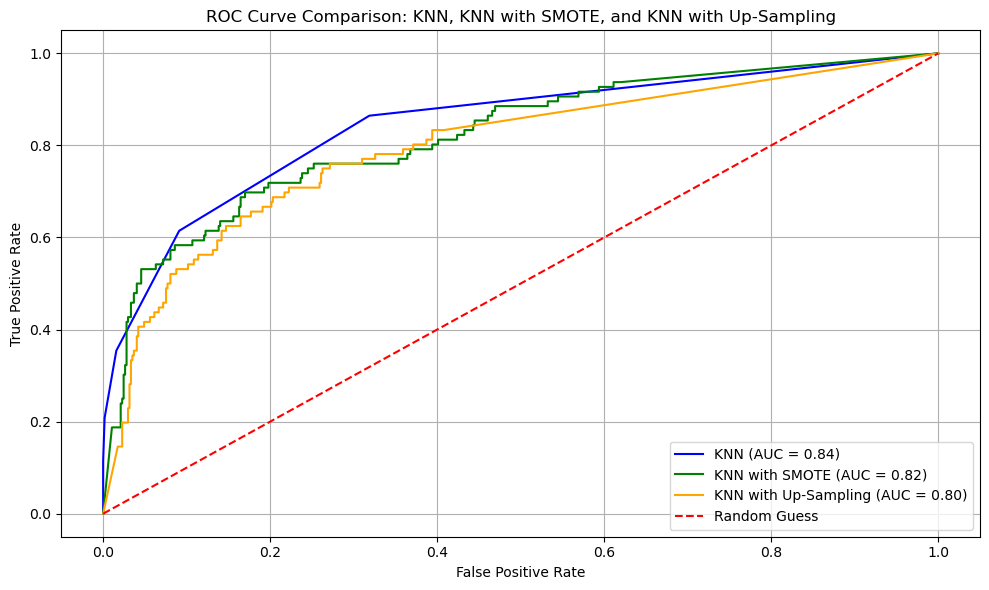

In [66]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Predictions from each model
y_pred_prob_knn = knn.predict_proba(X_test_scaled)[:, 1]  # KNN (original)
y_pred_prob_smote = knn_smote.predict_proba(X_test_scaled)[:, 1]  # KNN with SMOTE
y_pred_prob_upsampled = knn_upsampled.predict_proba(X_test_scaled)[:, 1]  # KNN with Up-Sampling

# Compute ROC curve and AUC for KNN
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_pred_prob_knn)
auc_knn = roc_auc_score(y_test, y_pred_prob_knn)

# Compute ROC curve and AUC for KNN with SMOTE
fpr_smote, tpr_smote, _ = roc_curve(y_test, y_pred_prob_smote)
auc_smote = roc_auc_score(y_test, y_pred_prob_smote)

# Compute ROC curve and AUC for KNN with Up-Sampling
fpr_upsampled, tpr_upsampled, _ = roc_curve(y_test, y_pred_prob_upsampled)
auc_upsampled = roc_auc_score(y_test, y_pred_prob_upsampled)

# Plot ROC Curve
plt.figure(figsize=(10, 6))
plt.plot(fpr_knn, tpr_knn, label=f"KNN (AUC = {auc_knn:.2f})", color="blue")
plt.plot(fpr_smote, tpr_smote, label=f"KNN with SMOTE (AUC = {auc_smote:.2f})", color="green")
plt.plot(fpr_upsampled, tpr_upsampled, label=f"KNN with Up-Sampling (AUC = {auc_upsampled:.2f})", color="orange")
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess", color="red")

# Add labels and legend
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison: KNN, KNN with SMOTE, and KNN with Up-Sampling")
plt.legend(loc="lower right")
plt.grid()
plt.tight_layout()

# Show the plot
plt.show()


## deployment

In [67]:
import joblib

# Save the model to a file
joblib.dump(rf_smoteenn, 'rf_smoteenn_model.pkl')


['rf_smoteenn_model.pkl']

In [70]:
import joblib
import numpy as np

# Load the trained model
model = joblib.load('rf_smoteenn_model.pkl')

def predict(features):
    # Assuming 'features' is a NumPy array or list with the shape of the model's input
    prediction = model.predict([features])
    return prediction

# Example usage
if __name__ == "__main__":
    # Sample input (replace this with actual input when deploying)
    features = [0.5, 1.2, 3.4, 0.9]  # Adjust the input features as required
    # Assuming X_test is a DataFrame and you want to predict for the first row
    features = X_test.iloc[0]  # Select the first row from X_test

    print("Prediction:", predict(features))


C:\Users\21624\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning:

X does not have valid feature names, but RandomForestClassifier was fitted with feature names



Prediction: [0]


In [ ]:
#in anaconda prompet run : pip install Flask


In [69]:
from flask import Flask
import threading

app = Flask(__name__)

@app.route('/')
def hello_world():
    return 'Hello, World!'

def run_flask():
    app.run(debug=True, use_reloader=False)  # Turn off reloader to avoid conflicts

# Run Flask in a separate thread
thread = threading.Thread(target=run_flask)
thread.start()


 * Serving Flask app '__main__'
 * Debug mode: on


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
127.0.0.1 - - [15/Dec/2024 20:06:52] "GET / HTTP/1.1" 200 -
